# Predicting ECtHR Article 6 Violations: Coverage, Provenance, and the Limits of Legal Signal in Predictive Judgements

In the pursuit of judicial efficiency, does deploying predictive AI improve the legal system, or does it fundamentally erode the epistemological definition of what it means to 'judge'? This project investigates Legal Reasoning and Spurious Correlations in NLP Models using a corpus of ECtHR judgments.

**Literature Review:** Across five core papers, we identify a common limitation. There is no view on what textual or topical patterns affect predictive performance.   
Aletras et al. (2016) set the base showing that Violations can be predicted and that different sections within ECtHR documents affect accuracy ("Facts" section highest predictor).   
Other studies honed in on specific features that affected prediction outcomes:  
(i) Santosh et al. (2022) — the word "represented" correlates strongly with violations  
(ii) Medvedeva & McBride (2023) — Models learn temporal correlations and they also critiqued "data leakage" where that "Facts" section is written post-judgement  
(iii) Wehnert et al (2025) — Models exhibit bias correlated with demographic descriptors  
Finally Chalkidis et al (2022) — Focused on what models can drive up predictions, where Legal-domain trained transformer model slightly outperformed generic transformer model for predictions.

These then guide our research question as below:

**Research Question:** What textual patterns in ECtHR 'Facts' sections are most predictive of violation outcomes, and to what extent do they reflect legally meaningful reasoning rather than provenance-driven shortcuts?

**Working hypothesis**  
NLP classifiers achieving high macro-F1 on ECHR Article 6 violation predictions are not primarily learning legal doctrine. Their accuracy is sustained by interlocking shortcuts: country-linked vocabulary, case-linked vocabulary, and document coverage effects that determine how much of that shortcut signal the model can access.

**Why this question matters**  
Legal Judgment Prediction (LJP) systems are increasingly proposed as decision-support tools for courts and as predictive analytics for litigants. The headline accuracy of 79% in the original Aletras study is routinely cited as evidence that text models can predict judicial outcomes.

1. Methodologically, the LJP literature systematically over-states model capability when truncated transformers are compared against full-document SVM baselines without controlling token budget: a confound this notebook documents in §7–§8.  
2. Jurisprudentially, predictive accuracy is not legal understanding (Kelsen, 1967; Samuel, 2023). A "stochastic parrot" (Bender et al., 2021) that pattern-matches on words is a fundamentally different artefact than a system reasoning about fair trial under Art. 6 § 1.  
3. Policy-wise, deployment of provenance-driven LJP risks entrenching geographic and historical biases (Jordan, 2019; Paseri & Durante, 2025), predicting violations more often for country-specific cases simply because past base rates were high, irrespective of the case-specific legal merits.  
4. Institutionally, once such systems are framed as useful legal support tools, they risk encouraging algorithmic deference and anchoring, where human decision-makers rely on statistically convenient outputs rather than legal judgment. (Lim & Akdemir, 2026)

This matters methodologically, jurisprudentially, and institutionally. Methodologically, predictive accuracy can overstate model capability if what is being learned is post hoc narrative structure rather than ex ante legal reasoning. Jurisprudentially, a high-scoring model may still be what Bender et al. call a "stochastic parrot," rewarding probability rather than meaning or doctrine. Institutionally, once such systems are framed as useful legal support tools, they risk encouraging algorithmic deference and anchoring, where human decision-makers rely on statistically convenient outputs rather than legal judgment.

**How the question is decomposed into testable sub-claims**

| Sub-claim | Test | "Supports" looks like | "Refutes" looks like |
| ----- | ----- | ----- | ----- |
| a. Model success rides mainly on provenance-rich lexical and topical cues, not doctrine. | §5.2 topic-LR coefficients · §11.1 SVM weights · §11.2/11.3 LIME · §11.4 False Positives analysis | Top predictive features are geographic / procedural / temporal. high-confidence False Positive errors are concentrated in the same narrative themes as True Positives | Top features are doctrinal and reflect legal principles False Positive errors are incidental more than correlated with systemic shortcuts |
| (b) Coverage, not architecture alone, explains much of the headline F1 gap. | §7 doc-length analysis · §8 token-budget sweep §10 performance comparison as a checkpoint, not substantive claim. | Most FACTS sections exceed 512 tokens; SVM and LegalBERT are close at a matched 512-token budget; performance rises as context increases; the apparent model gap shrinks or changes once token access is controlled. | 512 tokens already cover most cases, or a large architecture gap remains even after token-fair matching. |
| (c) Bias is distributionally encoded across country-specific institutional vocabulary, not concentrated in removable named entities. | §11.5 country-token masking · §11.6 leave-one-country-out | Masking visible country/place (GPE) tokens changes F1 only marginally (e.g. ≤ 0.01) but cross-country transfer drops substantially | Masking tanks F1; while leave-one-country-out testing shows little or no loss of generalisation. |

Sections 7–8 therefore establish the coverage control, while §11 asks what signal the models actually exploit. The leaderboard in §10 is not itself the answer to the research question; it only shows that the models perform well enough for the later signal analysis to be worth interpreting. The substantive argument is assembled across §5, §§7–8, and §11, and then synthesised in §§12–13.

**Roadmap view**

| § | Section | Role |
|---|---|---|
| 1 | Configuration | Data + run-time switches (no GPU needed if results pre-cached) |
| 2 | Log Discovery | Auto-detect any pre-trained model artefacts |
| 3 | Data Loading | Article 6 subset, label assignment |
| 4 | EDA on Article 6 | TF-IDF + Proportion-Shift; sets up the lexical hypothesis |
| **5** | **Topic Analysis (NMF)** | **§5.1 word-heatmap · §5.2 Aletras-style topic-LR · §5.3 close-reading topics** |
| 6 | TF-IDF Baselines | LinearSVC + LogReg with the legal tokenizer |
| 7 | Document Coverage | Why 512 tokens is insufficient for ECHR FACTS |
| 8 | SVM at varying token budgets | Token-fair comparison points (512 → full) |
| 9 | LegalBERT Fine-Tuning | §9.1 head+tail 512 · §9.2 chunked 4×510 |
| 10 | Performance Comparison | The leaderboard — but only as a foundation for §11 |
| **11** | **Model Signal Analysis** | **SVM weights · LIME (SVM + BERT) · error analysis · token masking · cross-country · §11.7 whole-case close reading** |
| 12 | Summary | Five-finding synthesis tying §11 evidence to the research question |
| 13 | Conclusions, Limitations, Future Work, Implications | Including legal/policy/ethical discussion |
| 14 | References & AI Acknowledgement | Bibliography and disclosure |

> **If you only have time for two sections:** §5.2 (Aletras-style topic-LR coefficients) and §11. Together they show what the model treats as predictive and where that treatment misfires when set against the legal substance of individual cases.

---

## Result loading priority (per model)

1. Load from saved `results/<model>/test_probs.npz` and `training.log` — **no GPU needed**
2. Set `FORCE_RETRAIN = True` in §1 to retrain from scratch (requires GPU)

The notebook is designed to be **runnable end-to-end on CPU** in the cached-results mode (~5 minutes), and on GPU in the retrain-from-scratch mode (~1 hour for the LegalBERT-Chunked 4-seed ensemble).

In [2]:
# ── Colab setup: clone repo and symlink data/results if running on Google Colab ──
import os, sys

IN_COLAB = 'google.colab' in sys.modules
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess, shutil
    REPO = 'https://github.com/leondgarse/echr.git'
    CLONE_DIR = '/content/echr_repo'

    if not os.path.exists(CLONE_DIR):
        print(f'Cloning {REPO} ...')
        subprocess.run(['git', 'clone', '--depth', '1', REPO, CLONE_DIR], check=True)
    else:
        print(f'Repo already cloned at {CLONE_DIR}')

    # Move data/ and results/ into the working directory if not already there
    for folder in ['data', 'results']:
        src = os.path.join(CLONE_DIR, folder)
        dst = os.path.join('/content', folder)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copytree(src, dst)
            print(f'Copied {src} → {dst}')
        elif os.path.exists(dst):
            print(f'{dst} already exists, skipping.')
        else:
            print(f'WARNING: {src} not found in cloned repo.')

    # Change working directory to /content so relative paths work
    os.chdir('/content')
    print(f'Working directory: {os.getcwd()}')
    print('Colab setup complete.')
else:
    print('Not running in Colab — no setup needed.')


Not running in Colab — no setup needed.


In [3]:
# Install any missing dependencies
%pip install -q lime spacy seaborn nltk scattertext 'matplotlib<3.8'  # shifterator needs `tick.label` which is removed in 'matplotlib 3.8'
import subprocess, sys
subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'],
               capture_output=True)

Note: you may need to restart the kernel to use updated packages.


CompletedProcess(args=['/home/gwwang/virtualenvs/workon312/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm', '--quiet'], returncode=0, stdout=b"\x1b\xe2\x9c\x94 Download and installation successful\x1b\nYou can now load the package via spacy.load('en_core_web_sm')\n", stderr=b'')

In [4]:
%matplotlib inline
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel, AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup, set_seed as hf_set_seed,
)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore')
print('All imports OK')

/home/gwwang/virtualenvs/workon312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK


## 1. Configuration

**Starting data (from EDA):** We found Articles 3, 5 and 8 are not evenly distributed across the three countries (RUS, TUR, GBR). We hence **narrowed the corpus to Article 6** to reduce distributional confounding across article types.

It should be noted that there is also a **class imbalance** (Violations outweigh Non-Violations). As we are not focusing on tuning model performance or obtaining the ‘best possible results’, we did not alter the datasets further and proceed to conduct analysis with this dataset.

To best cater for this class imbalance, we evaluate model performance using **Macro F1**, an accuracy metric that factors for class imbalances.


In [5]:
# ── Dataset config: Article 6 (436 cases, 3 countries: RUS / TUR / GBR) ──
FORCE_RETRAIN = False  # set True to force retraining even if saved files exist

cfg = {
    'data_path':         'data/processed/processed.csv',
    'probs_lb512':       'results/legalbert_512_original/test_probs.npz',
    'log_lb512':         'results/legalbert_512_original/training.log',
    'probs_chunked':     'results/legalbert_chunked_original_final/test_probs.npz',
    'log_chunked':       'results/legalbert_chunked_original_final/training.log',
    'probs_longformer':       'results/longformer_original/test_probs.npz',
    'probs_legal_longformer': 'results/legal_longformer_original/test_probs.npz',
    'known_lb512_f1':    0.621,  # val-tuned ensemble F1 from training log (F1@t=0.5 = 0.655)
    'known_chunked_f1':  0.765,
    'known_svm_full_f1': 0.718,
    'label':             'Original (436 Art.6 cases, RUS / TUR / GBR)',
}

# Training hyperparameters (LegalBERT)
HP = dict(
    model_name  = 'nlpaueb/legal-bert-base-uncased',
    seeds       = [0, 1, 2, 42],
    epochs      = 5,
    batch_size  = 8,
    lr          = 2e-5,
    wd          = 0.01,
    llrd_decay  = 0.90,
    focal_gamma = 2.0,
    max_len     = 512,
    n_head      = 128,
    chunk_size  = 510,
    n_chunks    = 4,
)

SEED = 42

# Global seed fixing — reproducible splits, LIME sampling, training
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
os.environ['PYTHONHASHSEED'] = str(SEED)
hf_set_seed(SEED)

print(f'Dataset : {cfg["label"]}')

# Auto-detect whether training is needed
_lb512_ready   = os.path.exists(cfg['log_lb512'])   or os.path.exists(cfg['probs_lb512'])
_chunked_ready = os.path.exists(cfg['log_chunked']) or os.path.exists(cfg['probs_chunked'])
TRAIN_LB512   = FORCE_RETRAIN or not _lb512_ready
TRAIN_CHUNKED = FORCE_RETRAIN or not _chunked_ready

print(f'LegalBERT-512    : {"TRAIN" if TRAIN_LB512 else "skip (log/npz found)"}')
print(f'LegalBERT chunked: {"TRAIN" if TRAIN_CHUNKED else "skip (log/npz found)"}')
if FORCE_RETRAIN:
    print('FORCE_RETRAIN=True — will overwrite existing files.')
print(f'Global seed: {SEED}')


Dataset : Original (436 Art.6 cases, RUS / TUR / GBR)
LegalBERT-512    : skip (log/npz found)
LegalBERT chunked: skip (log/npz found)
Global seed: 42


## 2. Log Discovery

Check which pre-run training logs are available. Logs are parsed to extract per-epoch validation F1 and final ensemble results — used for training curve plots and model comparison.

In [6]:
# ── Log parsing utilities ───────────────────────────────────────────────────

def parse_chunked_log(log_path):
    """
    Parse a train_chunked.py log file. Supports the compact training-log format
    actually emitted by the training script:

        seed=0:
          LLRD lr range: 5.08e-06 - 2.00e-05
            ep1: val_f1=0.579   ep2: val_f1=0.604   ...   ep5: val_f1=0.646  -> best=0.646
        ...
        Ensemble macro-F1=0.765  (threshold=0.50)

    Returns:
      seeds    : {seed_int: {'epochs': [{epoch, val_f1}], 'best_val_f1': float, 'test_f1': float}}
                 (test_f1 is set to best_val_f1 as a per-seed proxy — the log does
                  not record per-seed test F1 separately from the ensemble.)
      ensemble : {'macro_f1': float, 'threshold': float}
      content  : raw log string
    """
    with open(log_path) as f:
        content = f.read()

    seeds = {}
    current = None
    for raw_line in content.split('\n'):
        line = raw_line.strip()

        m = re.match(r'seed=(\d+):\s*$', line)
        if m:
            current = int(m.group(1))
            seeds[current] = {'epochs': [], 'best_val_f1': None, 'test_f1': None}
            continue

        if current is None:
            continue

        # Compact "ep1: val_f1=0.579   ep2: val_f1=0.604   ..." line
        eps = re.findall(r'ep(\d+):\s*val_f1=([\d.]+)', line)
        if eps:
            for ep, vf1 in eps:
                seeds[current]['epochs'].append(
                    {'epoch': int(ep), 'val_f1': float(vf1)}
                )
        # best=0.646 marker (end of per-seed block)
        m = re.search(r'best=([\d.]+)', line)
        if m:
            seeds[current]['best_val_f1'] = float(m.group(1))
            # Use best-val as per-seed proxy for labelling
            seeds[current]['test_f1'] = float(m.group(1))

        # Also support the legacy verbose format, if present
        m = re.search(r'Epoch (\d+)/\d+ \| loss=([\d.]+) \| val macro-F1=([\d.]+)', line)
        if m:
            seeds[current]['epochs'].append(
                {'epoch': int(m.group(1)), 'loss': float(m.group(2)), 'val_f1': float(m.group(3))}
            )
        m = re.search(r'seed=\d+ .+ test macro-F1:\s*([\d.]+)', line)
        if m:
            seeds[current]['test_f1'] = float(m.group(1))

    # Ensemble macro-F1=X  (threshold=Y)   (compact)
    m = re.search(r'Ensemble macro-F1=([\d.]+)\s*\(threshold=([\d.]+)\)', content)
    if not m:
        # Legacy verbose format
        m = re.search(r'macro_f1:\s+([\d.]+)\s+\(threshold=([\d.]+)\)', content)
    ensemble = {'macro_f1': float(m.group(1)), 'threshold': float(m.group(2))} if m else {}
    return seeds, ensemble, content


# ── Discover available logs ─────────────────────────────────────────────────
print(f'Checking logs for dataset: {cfg["label"]}\n')

for label, path in [
    ('LegalBERT-512 log',    cfg['log_lb512']),
    ('LegalBERT chunked log', cfg['log_chunked']),
]:
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = f'FOUND  ({size:,} bytes)' if exists else 'not found'
    print(f'  [{status:30s}]  {path}')


Checking logs for dataset: Original (436 Art.6 cases, RUS / TUR / GBR)

  [FOUND  (763 bytes)            ]  results/legalbert_512_original/training.log
  [FOUND  (750 bytes)            ]  results/legalbert_chunked_original_final/training.log


## 3. Data Loading

We used HUDOC judgments because they provide clear Article-specific Violation / Non-Violation labels and enough cross-country variation to test whether models learn legal substance or provenance-driven shortcuts. The corpus is therefore useful not only for supervised classification, but also for examining how outcome prediction may depend on geography, procedure, and reporting style rather than doctrine.

Our data was ethically acquired from the official HUDOC database using the echr-extractor Python library, which interfaces with the HUDOC API. We adhered to the following standards:

* Terms-of-service compliance: we used a public-facing access route and did not bypass access controls.
* Reasonable request behaviour: the extraction workflow used controlled request settings rather than aggressive scraping.
* Reproducibility: The data were collected from the public HUDOC database through a scriptable extraction workflow and then filtered into the retained Article 6 sample used here.
* Sensitivity awareness: although ECHR judgments are public, they concern human-rights disputes and may encode structural bias; this notebook explicitly examines such risks.

All models use only the **FACTS section** of each ECHR judgment. Labels are Article-6-specific.

In [7]:
def contains_article(series, article):
    return series.fillna('').str.split(';').apply(
        lambda lst: any(a.strip() == article for a in lst)
    )

df = pd.read_csv(cfg['data_path'])
mask = (contains_article(df['violation_articles'], '6') |
        contains_article(df['nonviolation_articles'], '6'))
df   = df[mask].copy()
df['label']   = contains_article(df['violation_articles'], '6').astype(int)
df['n_words'] = df['text'].fillna('').str.split().str.len()

print(f'Cases: {len(df)}  |  Violation rate: {df["label"].mean():.1%}')
print(f'Countries: {sorted(df["respondent"].unique())}')
print(f'Year range: {int(df["year"].min())} - {int(df["year"].max())}')

train_val, test_df = train_test_split(df, test_size=0.25, stratify=df['label'], random_state=SEED)
train_df,  val_df  = train_test_split(train_val, test_size=0.15/0.75,
                                       stratify=train_val['label'], random_state=SEED)

X_train = train_df['text'].fillna('').tolist()
X_val   = val_df['text'].fillna('').tolist()
X_test  = test_df['text'].fillna('').tolist()
y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values
print(f'\nTrain: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}')

Cases: 436  |  Violation rate: 73.4%
Countries: ['GBR', 'RUS', 'TUR']
Year range: 1983 - 2026

Train: 261  Val: 66  Test: 109


### Data Cautions — What the Sample Does (and Doesn't) Represent

Before any descriptive statistics or visualization, we make four caveats explicit. Each caveat is a constraint on the *kind* of conclusion that this notebook can draw from the corpus, and each is something a reader should keep in mind when interpreting the §11 bias-probe results.

- **Post-hoc narrative construction.** The FACTS section of an ECtHR judgment is not a neutral contemporaneous record. It is drafted by the Court *after* the judgment has been written, often selecting and re-ordering facts to support the eventual disposition. This is the central methodological reason we restrict to FACTS-only and exclude LAW (Medvedeva & McBride, 2023): even FACTS-only text may reflect outcome-consistent framing.
- **Residual structural differences between classes.** Even after restricting to FACTS, some non-doctrinal shortcut signals remain — formulaic wording, length differences (see §3.2), and country-correlated procedural vocabulary. These are real distributional regularities, not artefacts to be eliminated, but they are *not* the legal merits.
- **Retained-sample composition.** The 952-case corpus is what survived the HUDOC download + metadata alignment + FACTS-extraction pipeline. We did not artificially balance the sample to hit any per-(article, country) quota; the 436-case Article 6 subset reflects what those filters left in. All descriptive statistics in this notebook should be read as conditional on this retained sample.
- **Metadata incompleteness.** Fields such as `representedby` contain a non-trivial fraction of missing values, which may reflect incomplete HUDOC recording rather than a meaningful absence of legal representation. We exclude `has_representation` from the feature set for this reason.

Each of these is consistent with the project's reading of NLP-ECHR work as a *limit* claim: the models can pattern-match on the textual surface that survives the pipeline, but the surface is shaped by reporting conventions and metadata recording, not just by the underlying legal facts.

### 3.0 Why Article 6? — Article Distribution Across Articles 3 / 5 / 6 / 8

Before narrowing to Article 6, we examine the *full* corpus across the four ECHR articles we initially downloaded:

- **Article 3** — Prohibition of torture and inhuman/degrading treatment
- **Article 5** — Right to liberty and security
- **Article 6** — Right to a fair trial
- **Article 8** — Right to respect for private and family life

The two-panel figure below shows article × country × outcome counts for the *unfiltered* 952-case corpus. The point is to **justify the Article 6 focus** that the rest of the notebook adopts: among the four articles, Article 6 is the one with the **most balanced V/NV split across all three respondent states**, while Articles 3 / 5 / 8 are heavily skewed (or absent) in some country–outcome cells. A model trained on a more balanced article gives the bias analysis in §11 something to *fail* against — the alternative would be Article 3 in Russia (~near-100% violation), where any classifier would score high simply by predicting the majority class.

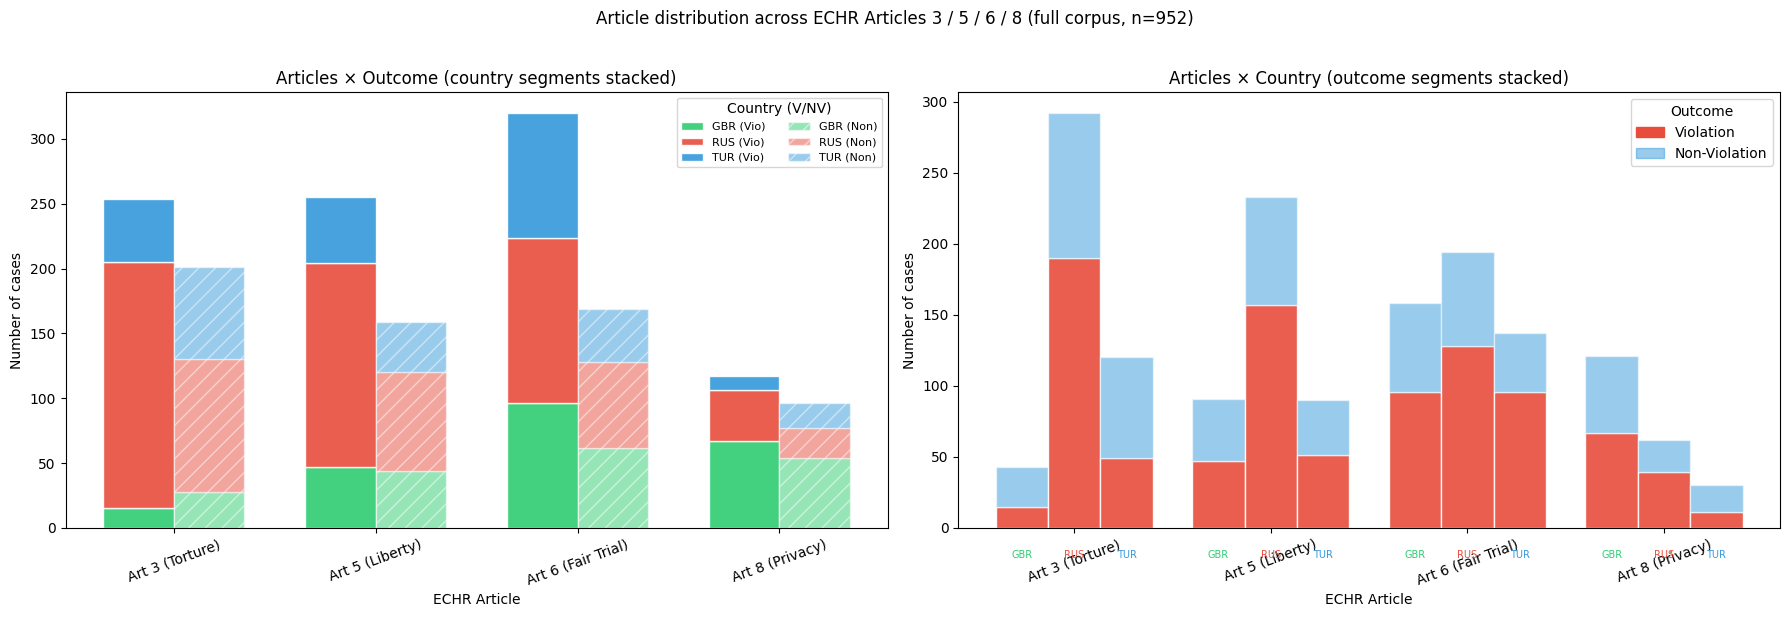


Violation rate per Article × Country:
Country               GBR    RUS    TUR
Article                                
Art 3 (Torture)     34.9%  65.1%  40.8%
Art 5 (Liberty)     51.6%  67.4%  56.7%
Art 6 (Fair Trial)  60.8%  66.0%  70.1%
Art 8 (Privacy)     55.4%  62.9%  36.7%

Article 6 rationale: most balanced V/NV split across all three countries; no other article has cases in every country×outcome cell with reasonable counts.


In [8]:
# §3.0 — Article distribution across full corpus (Articles 3 / 5 / 6 / 8)
# Reload unfiltered data so we can compare Article 6 against the alternatives.

_df_full = pd.read_csv(cfg['data_path'])
_target_articles = ['3', '5', '6', '8']
_article_names = {'3': 'Art 3 (Torture)', '5': 'Art 5 (Liberty)',
                  '6': 'Art 6 (Fair Trial)', '8': 'Art 8 (Privacy)'}

_article_rows = []
for _, _row in _df_full.iterrows():
    _ctry = _row['respondent']
    for _outcome, _col in [('Violation', 'violation_articles'),
                           ('Non-Violation', 'nonviolation_articles')]:
        _arts = str(_row.get(_col, '')).strip()
        if _arts and _arts.lower() not in ('nan', ''):
            for _a in _arts.split(';'):
                _a = _a.strip()
                if _a in _target_articles:
                    _article_rows.append({'Country': _ctry, 'Outcome': _outcome,
                                          'Article': _article_names[_a]})

_art_df = pd.DataFrame(_article_rows)
_articles_sorted = sorted(_art_df['Article'].unique())
_countries = sorted(_art_df['Country'].unique())
_outcomes  = ['Violation', 'Non-Violation']
_country_colors = {'RUS': '#e74c3c', 'TUR': '#3498db', 'GBR': '#2ecc71'}
_outcome_colors = {'Violation': '#e74c3c', 'Non-Violation': '#3498db'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left panel: Article × Outcome, country segments stacked inside each bar
_x = np.arange(len(_articles_sorted))
_w = 0.35
for _i, _o in enumerate(_outcomes):
    _bottom = np.zeros(len(_articles_sorted))
    for _c in _countries:
        _vals = [len(_art_df[(_art_df.Article==_a) & (_art_df.Outcome==_o) & (_art_df.Country==_c)])
                 for _a in _articles_sorted]
        axes[0].bar(_x + (_i-0.5)*_w, _vals, _w, bottom=_bottom,
                    label=f'{_c} ({_o[:3]})',
                    color=_country_colors.get(_c, '#888'),
                    alpha=0.9 if _o=='Violation' else 0.5,
                    hatch='//' if _o=='Non-Violation' else None,
                    edgecolor='white')
        _bottom += _vals
axes[0].set_title('Articles × Outcome (country segments stacked)')
axes[0].set_xlabel('ECHR Article'); axes[0].set_ylabel('Number of cases')
axes[0].set_xticks(_x); axes[0].set_xticklabels(_articles_sorted, rotation=20)
axes[0].legend(fontsize=8, ncol=2, title='Country (V/NV)')

# Right panel: Article × Country, outcome segments stacked
_bw = 0.8 / len(_countries)
for _j, _c in enumerate(_countries):
    _bottom = np.zeros(len(_articles_sorted))
    for _o in _outcomes:
        _vals = [len(_art_df[(_art_df.Article==_a) & (_art_df.Country==_c) & (_art_df.Outcome==_o)])
                 for _a in _articles_sorted]
        axes[1].bar(_x + (_j - len(_countries)/2 + 0.5)*_bw, _vals, _bw, bottom=_bottom,
                    color=_outcome_colors[_o],
                    alpha=0.9 if _o=='Violation' else 0.5,
                    edgecolor='white')
        _bottom += _vals
    # Country annotation under each cluster
    for _xi in range(len(_articles_sorted)):
        axes[1].annotate(_c, xy=(_x[_xi] + (_j - len(_countries)/2 + 0.5)*_bw, 0),
                         xytext=(0, -22), textcoords='offset points', ha='center',
                         fontsize=7, color=_country_colors.get(_c, '#888'))
from matplotlib.patches import Patch
axes[1].legend(handles=[Patch(color=_outcome_colors['Violation'], label='Violation'),
                        Patch(color=_outcome_colors['Non-Violation'], alpha=0.5, label='Non-Violation')],
               title='Outcome')
axes[1].set_title('Articles × Country (outcome segments stacked)')
axes[1].set_xlabel('ECHR Article'); axes[1].set_ylabel('Number of cases')
axes[1].set_xticks(_x); axes[1].set_xticklabels(_articles_sorted, rotation=20)

plt.suptitle('Article distribution across ECHR Articles 3 / 5 / 6 / 8 (full corpus, n='
             f'{len(_df_full)})', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

# Tabular companion — V rate per (article, country)
_art_summary = (_art_df
                .assign(V=(_art_df['Outcome']=='Violation').astype(int))
                .groupby(['Article','Country'])
                .agg(total=('Outcome','count'), v=('V','sum'))
                .reset_index())
_art_summary['V_rate'] = (_art_summary['v'] / _art_summary['total'] * 100).round(1).astype(str) + '%'
_pivot = _art_summary.pivot_table(index='Article', columns='Country', values='V_rate', aggfunc='first').fillna('—')
print('\nViolation rate per Article × Country:')
print(_pivot.to_string())
print(f'\nArticle 6 rationale: most balanced V/NV split across all three countries; '
      f'no other article has cases in every country×outcome cell with reasonable counts.')

**What the chart tells us:**

| Article | Cases per country (GBR / RUS / TUR) | V rate (GBR / RUS / TUR) | Cross-country balance |
|---|---|---|---|
| Art 3 (Torture) | 43 / 292 / 120 | 35% / 65% / 41% | **Russian-skewed** in volume; UK contributes only 43 cases |
| Art 5 (Liberty) | 91 / 233 / 90 | 52% / 67% / 57% | Russian-skewed in volume; V rates more even but UK is undersampled |
| Art 6 (Fair Trial) | 158 / 194 / 137 | 61% / 66% / 70% | **Most uniform across all three countries** — both in case volume and V rate |
| Art 8 (Privacy) | 121 / 62 / 30 | 55% / 63% / 37% | UK-skewed in volume; Turkey has only 30 cases |

**Why Article 6 is the right choice for this analysis.** Article 6 is the only article in the corpus where (a) all three countries contribute *triple-digit* case counts, and (b) the violation rates are clustered in a narrow ~10-percentage-point band (61–70%) rather than spreading across 30+ points. This balance matters because:

- A model trained on **Article 3** would be solving a Russia-vs-not problem (292 RUS cases out of 455 total), with the UK contributing too few cases for the bias-probe analysis in §11.5/§11.6 to be meaningful.
- A model trained on **Article 8** would have the opposite UK skew (121 GBR / 30 TUR), again making cross-country leave-one-out unreliable.
- A model trained on **Article 5** would be Russian-dominated like Article 3.
- **Article 6's balance gives the §11 bias probes their teeth**: there are enough V and NV cases in each country for per-country F1 to be informative, enough country diversity for cross-country leave-one-out to find a real signal, and enough variance in violation rates (still 9 percentage points between GBR and TUR) to expose country-as-prior shortcuts when they exist.

The corpus filter at the next cell narrows to the **436 Article 6 cases** for the rest of the notebook. The Article 3 / 5 / 8 cases are dropped from this point on, but reappear briefly in §13.3 Future Work.

### Article 6 — respondent-state distribution by outcome

Country-level distribution of Article 6 cases, split by violation / non-violation (ported from `EDA.ipynb` §2b). Highlights the country-specific violation-rate patterns that motivate much of the bias analysis in §11.


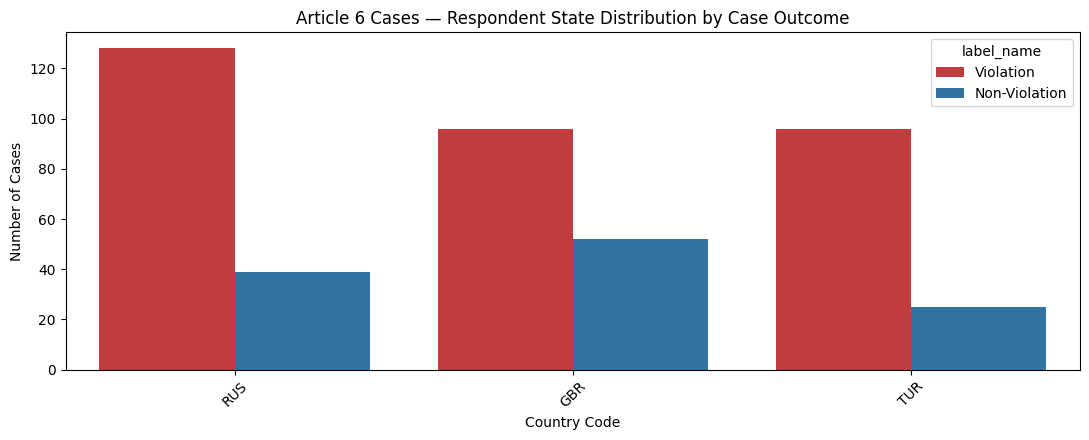

Article 6 subset: 436 cases
label_name  Non-Violation  Violation
respondent                          
GBR                    52         96
RUS                    39        128
TUR                    25         96


In [9]:
# Article 6 — Respondent state distribution by outcome
# (ported from EDA.ipynb §2b)
import seaborn as sns

_art6_vis = df.copy()
_art6_vis['label_name'] = _art6_vis['label'].map({1: 'Violation', 0: 'Non-Violation'})

plt.figure(figsize=(11, 4.5))
_order = _art6_vis['respondent'].value_counts().index
sns.countplot(
    data=_art6_vis, x='respondent', hue='label_name',
    order=_order,
    hue_order=['Violation', 'Non-Violation'],
    palette={'Violation': '#d62728', 'Non-Violation': '#1f77b4'},
)
plt.title('Article 6 Cases — Respondent State Distribution by Case Outcome')
plt.xlabel('Country Code'); plt.ylabel('Number of Cases')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

print(f'Article 6 subset: {len(_art6_vis)} cases')
print(_art6_vis.groupby(['respondent', 'label_name']).size().unstack(fill_value=0))


### 3.1 Per-Country Summary Statistics

Numeric companion to the bar chart above. Reports total Article 6 cases, the violation/non-violation split, and FACTS-section length statistics for each respondent country. The asymmetry across countries — both in case volume and in violation rate — is the corpus-level fact that drives the geographic-shortcut analysis in §11.

In [10]:
# Per-country descriptive statistics (Article 6 subset)
_summary = (
    df.assign(label_name=df['label'].map({1:'Violation', 0:'Non-Violation'}))
      .groupby('respondent')
      .agg(
          total_cases       = ('label', 'count'),
          violations        = ('label', 'sum'),
          non_violations    = ('label', lambda x: (x == 0).sum()),
          violation_rate    = ('label', 'mean'),
          mean_n_words      = ('n_words', 'mean'),
          median_n_words    = ('n_words', 'median'),
      )
      .reset_index()
)
_summary['violation_rate'] = (_summary['violation_rate'] * 100).round(1).astype(str) + '%'
_summary['mean_n_words']   = _summary['mean_n_words'].round(0).astype(int)
_summary['median_n_words'] = _summary['median_n_words'].astype(int)
_summary.columns = ['Country', 'Total cases', 'V', 'NV', 'V rate',
                    'Mean FACTS (words)', 'Median FACTS (words)']
print('=== Per-country summary — Article 6 subset ===')
_summary

=== Per-country summary — Article 6 subset ===


,Country,Total cases,V,NV,V rate,Mean FACTS (words),Median FACTS (words)
0,GBR,148,96,52,64.9%,2103,1537
1,RUS,167,128,39,76.6%,1154,762
2,TUR,121,96,25,79.3%,754,414


### 3.2 FACTS Length Distribution — by Class

The histogram below answers a structural question that recurs throughout the notebook: *does FACTS-section length itself differ by case outcome?* If V cases were systematically much longer or shorter than NV cases, length alone would be a confound.

The result is informative: the two distributions overlap heavily but **non-violation cases skew longer in the upper tail** (>2 000 words), driven by UK statutory-framework cases that recite legislation in full. Violation cases concentrate in the 200–1 000-word band. This length asymmetry interacts directly with the §7 coverage analysis: at a 512-token budget a model truncates more of the NV cases than the V cases, which biases the truncation effect toward NV-class loss.

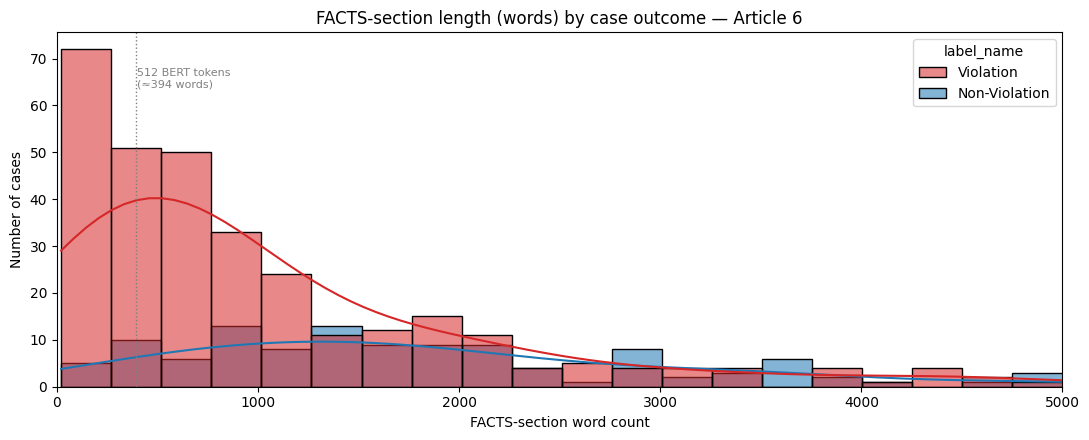

Median FACTS length — Violation:     707 words
Median FACTS length — Non-Violation: 1614 words
% of cases >512 BERT tokens (~394 words): 74.5%


In [11]:
# FACTS length distribution by class (Article 6 subset)
import seaborn as sns
_dfl = df.assign(label_name=df['label'].map({1:'Violation', 0:'Non-Violation'}))

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(
    data=_dfl, x='n_words', hue='label_name', bins=50, kde=True, alpha=0.55,
    palette={'Violation': '#d62728', 'Non-Violation': '#1f77b4'}, ax=ax,
)
ax.set_xlim(0, 5000)  # cap the long tail for legibility
ax.set_title('FACTS-section length (words) by case outcome — Article 6')
ax.set_xlabel('FACTS-section word count'); ax.set_ylabel('Number of cases')
ax.axvline(394, color='gray', ls=':', lw=1)  # ~512 BERT tokens
ax.text(400, ax.get_ylim()[1]*0.9, '512 BERT tokens\n(≈394 words)',
        fontsize=8, color='gray', va='top')
plt.tight_layout(); plt.show()

print(f'Median FACTS length — Violation:     {_dfl[_dfl.label==1].n_words.median():.0f} words')
print(f'Median FACTS length — Non-Violation: {_dfl[_dfl.label==0].n_words.median():.0f} words')
print(f'% of cases >512 BERT tokens (~394 words): {(df["n_words"] > 394).mean():.1%}')

### 3.3 Temporal Distribution and Per-Country Violation Trend

Year distribution matters because of the **temporal-shift problem**: legal doctrine, reporting conventions, and case mixes evolve over time. A model trained on a random split is implicitly trained on a mixture of decades — which is fine for in-distribution evaluation but obscures whether the learned signal would transfer forward in time. The §13 Future Work section flags formal temporal-split evaluation as a natural extension; here we just plot the raw distribution and the per-country violation rate over time.

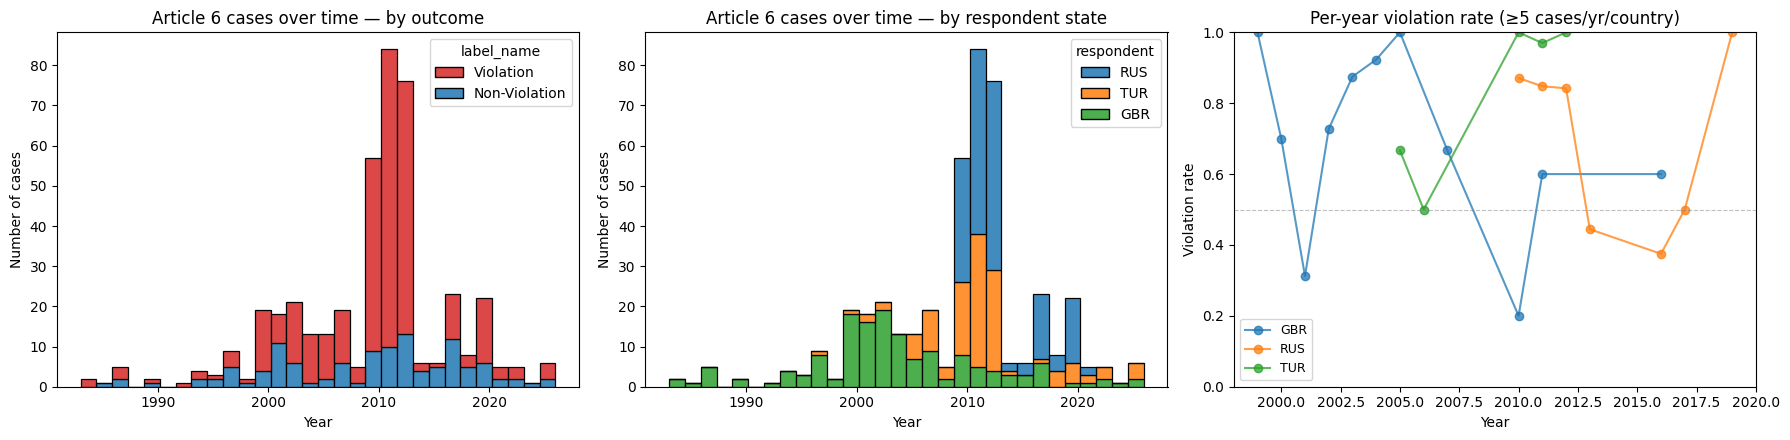

In [12]:
# Temporal distribution + per-country violation trend (Article 6 subset)
_dft = df.assign(label_name=df['label'].map({1:'Violation', 0:'Non-Violation'}))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# (a) Year × outcome stacked histogram
sns.histplot(
    data=_dft, x='year', hue='label_name', bins=30, multiple='stack',
    palette={'Violation': '#d62728', 'Non-Violation': '#1f77b4'},
    ax=axes[0], alpha=0.85,
)
axes[0].set_title('Article 6 cases over time — by outcome')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Number of cases')

# (b) Year × country stacked histogram
sns.histplot(
    data=_dft, x='year', hue='respondent', bins=30, multiple='stack',
    ax=axes[1], alpha=0.85,
)
axes[1].set_title('Article 6 cases over time — by respondent state')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Number of cases')

# (c) Per-year per-country violation rate
_yc = (df.groupby(['year','respondent'])
         .agg(total=('label','count'), v=('label','sum'))
         .reset_index())
_yc['vrate'] = _yc['v'] / _yc['total']
_yc = _yc[_yc['total'] >= 5]   # only years with enough cases per country to be stable
for c, g in _yc.groupby('respondent'):
    axes[2].plot(g['year'], g['vrate'], marker='o', alpha=0.75, label=c)
axes[2].axhline(0.5, color='gray', ls='--', lw=0.8, alpha=0.5)
axes[2].set_ylim(0, 1)
axes[2].set_title('Per-year violation rate (≥5 cases/yr/country)')
axes[2].set_xlabel('Year'); axes[2].set_ylabel('Violation rate')
axes[2].legend(fontsize=9)

plt.tight_layout(); plt.show()

### 3.4 Article 6 — Provision Structure and Corpus Complaint Profile

Before turning to text-level EDA in §4, we orient the reader to the **legal structure** of Article 6 and to *which* sub-provisions our corpus actually litigates. Article 6 is not monolithic — it comprises three sub-sections:

- **6(1)** — Fair trial guarantees that apply to *both civil and criminal* proceedings: reasonable time, independent and impartial tribunal, fair and public hearing, access to court.
- **6(2)** — Presumption of innocence (criminal only).
- **6(3)** — Five enumerated minimum rights for criminal defendants: (a) informed of charge, (b) time to prepare, (c) legal assistance, (d) examine witnesses, (e) free interpreter.

Each sub-provision generates structurally different FACTS narratives. A "reasonable time" complaint produces a chronology of adjournments and delay; an "independent tribunal" complaint produces institutional vocabulary about the deciding court; a "legal assistance" complaint produces a counsel-availability narrative. Knowing the *mix* of provisions in the corpus is therefore essential for interpreting both the topic-modelling results in §5 and the per-country error patterns in §11.

The infographic below pairs the legal structure (top panel) with a corpus-driven keyword-frequency scan (bottom panel) that estimates how many of our 436 FACTS sections match the regex signature of each provision. The mapping is approximate — FACTS sections rarely cite the provision number explicitly — but it is enough to confirm the qualitative picture: **6(1) Reasonable Time** is the dominant complaint type, with institutional-tribunal complaints a clear second.

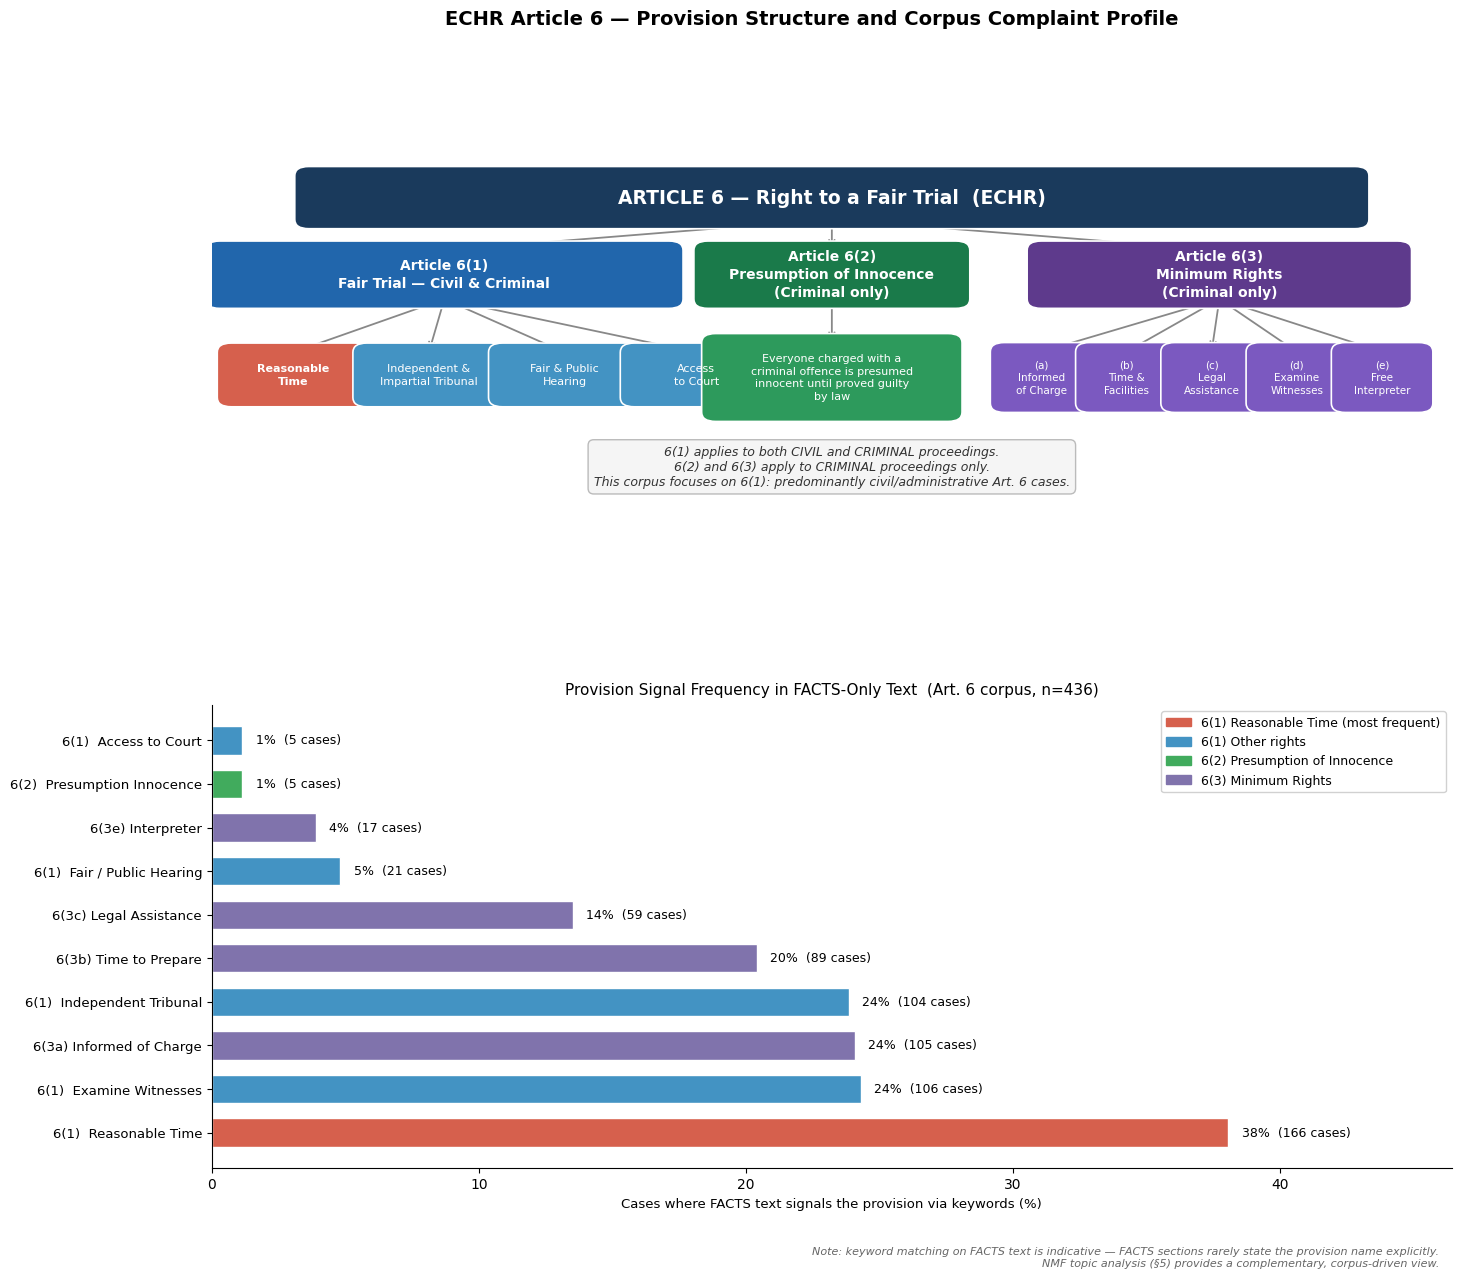

In [13]:
# §3.4 — Article 6 provision structure + corpus complaint profile
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# Keyword-frequency scan on Article 6 FACTS corpus (df is already Art.6-filtered)
_texts6 = df['text'].fillna('').str.lower()
_N6 = len(df)

_provisions = [
    ('6(1)  Reasonable Time',       r'hearing.*schedul|adjourned|postponed|\d+ year.*hearing|\d+ month.*proceed|delayed|delay in|length.*proceed'),
    ('6(1)  Independent Tribunal',  r'state security court|assize court|military court|military tribunal|administrative court|independence|impartial'),
    ('6(1)  Examine Witnesses',     r'examine.*witness|call.*witness|cross.?examin'),
    ('6(1)  Fair / Public Hearing', r'fair hearing|public hearing|equality of arm|adversarial|access to court|oral hearing'),
    ('6(3a) Informed of Charge',    r'informed.*charge|nature.*charge|cause.*accusation'),
    ('6(3b) Time to Prepare',       r'time.*prepare|adequate.*time|time and facilities'),
    ('6(3c) Legal Assistance',      r'legal aid|assigned counsel|legal representative|right to counsel|free legal'),
    ('6(3e) Interpreter',           r'interpreter|free.*interpret'),
    ('6(2)  Presumption Innocence', r'presumed innocent|presumption of innocence'),
    ('6(1)  Access to Court',       r'access to court|right to a court|enforcement of judgment|non-enforcement'),
]
_counts = sorted([(p, _texts6.str.contains(pat, regex=True).sum()) for p, pat in _provisions],
                 key=lambda x: -x[1])
_labels = [x[0] for x in _counts]
_vals   = [x[1] for x in _counts]
_pcts   = [v / _N6 * 100 for v in _vals]

def _col(label):
    if "6(1)" in label and "Reasonable" in label: return "#d6604d"
    if "6(1)" in label: return "#4393c3"
    if "6(2)" in label: return "#41ab5d"
    return "#8073ac"
_bar_colors = [_col(l) for l in _labels]

# ── Figure layout ────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 13))
gs  = fig.add_gridspec(2, 1, height_ratios=[1.0, 0.9], hspace=0.05)
ax_s = fig.add_subplot(gs[0])
ax_b = fig.add_subplot(gs[1])
ax_s.set_xlim(0, 16); ax_s.set_ylim(0, 10); ax_s.axis("off")

def _rbox(ax, cx, cy, w, h, text, fc, fs=9, bold=False):
    p = FancyBboxPatch((cx-w/2, cy-h/2), w, h, boxstyle="round,pad=0.18",
                       facecolor=fc, edgecolor="white", linewidth=1.2, zorder=3)
    ax.add_patch(p)
    ax.text(cx, cy, text, ha="center", va="center", fontsize=fs,
            color="white", weight="bold" if bold else "normal", zorder=4,
            linespacing=1.35, multialignment="center")

def _arr(ax, x0, y0, x1, y1):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="->", color="#888888", lw=1.3), zorder=2)

# Header
_rbox(ax_s, 8, 9.4, 13.5, 0.85, "ARTICLE 6 — Right to a Fair Trial  (ECHR)", "#1a3a5c", fs=13.5, bold=True)
# Three sub-sections
for sx, sw, txt, fc in [
    (3.0, 5.8, "Article 6(1)\nFair Trial — Civil & Criminal", "#2166ac"),
    (8.0, 3.2, "Article 6(2)\nPresumption of Innocence\n(Criminal only)", "#1a7a4a"),
    (13.0, 4.6, "Article 6(3)\nMinimum Rights\n(Criminal only)", "#5e3a8c"),
]:
    _rbox(ax_s, sx, 7.9, sw, 0.95, txt, fc, fs=10, bold=True)
    _arr(ax_s, 8, 8.98, sx, 8.375)

# 6(1) four key rights
for sx, lbl, fc, note in [
    (1.05, "Reasonable\nTime",                    "#d6604d", "* most frequent"),
    (2.80, "Independent &\nImpartial Tribunal",  "#4393c3", ""),
    (4.55, "Fair & Public\nHearing",              "#4393c3", ""),
    (6.25, "Access\nto Court",                    "#4393c3", ""),
]:
    _rbox(ax_s, sx, 5.95, 1.6, 0.88, lbl, fc, fs=8, bold=(note != ""))
    if note:
        ax_s.text(sx, 5.44, note, ha="center", fontsize=7.2, color="#d6604d",
                  style="italic", weight="bold", zorder=5)
    _arr(ax_s, 3.0, 7.425, sx, 6.39)

# 6(2)
_rbox(ax_s, 8.0, 5.9, 3.0, 1.35,
      "Everyone charged with a\ncriminal offence is presumed\ninnocent until proved guilty\nby law",
      "#2d9a5c", fs=8)
_arr(ax_s, 8.0, 7.425, 8.0, 6.575)

# 6(3) five minimum rights
_sub3 = ["(a)\nInformed\nof Charge", "(b)\nTime &\nFacilities", "(c)\nLegal\nAssistance",
         "(d)\nExamine\nWitnesses", "(e)\nFree\nInterpreter"]
_xs3 = [10.7, 11.8, 12.9, 14.0, 15.1]
for lbl, sx in zip(_sub3, _xs3):
    _rbox(ax_s, sx, 5.9, 0.95, 1.0, lbl, "#7b59c0", fs=7.5)
    _arr(ax_s, 13.0, 7.425, sx, 6.4)

# Scope note
ax_s.text(8, 4.58,
    "6(1) applies to both CIVIL and CRIMINAL proceedings.\n"
    "6(2) and 6(3) apply to CRIMINAL proceedings only.\n"
    "This corpus focuses on 6(1): predominantly civil/administrative Art. 6 cases.",
    ha="center", va="top", fontsize=9, color="#333", style="italic",
    bbox=dict(fc="#f5f5f5", ec="#bbb", boxstyle="round,pad=0.45"), zorder=5)

# Bar chart
ax_b.barh(range(len(_labels)), _pcts, color=_bar_colors, edgecolor="white", height=0.65)
for i, (v, p) in enumerate(zip(_vals, _pcts)):
    ax_b.text(p + 0.5, i, f"{p:.0f}%  ({v} cases)", va="center", fontsize=9)
ax_b.set_yticks(range(len(_labels)))
ax_b.set_yticklabels(_labels, fontsize=9.5)
ax_b.set_xlabel("Cases where FACTS text signals the provision via keywords (%)", fontsize=9.5)
ax_b.set_title(f"Provision Signal Frequency in FACTS-Only Text  (Art. 6 corpus, n={_N6:,})",
               fontsize=11, pad=8)
ax_b.set_xlim(0, max(_pcts) * 1.22)
ax_b.spines["top"].set_visible(False); ax_b.spines["right"].set_visible(False)
ax_b.legend(handles=[
    mpatches.Patch(color="#d6604d", label="6(1) Reasonable Time (most frequent)"),
    mpatches.Patch(color="#4393c3", label="6(1) Other rights"),
    mpatches.Patch(color="#41ab5d", label="6(2) Presumption of Innocence"),
    mpatches.Patch(color="#8073ac", label="6(3) Minimum Rights"),
], fontsize=9, framealpha=0.9)
ax_b.text(0.99, -0.17,
    "Note: keyword matching on FACTS text is indicative — FACTS sections rarely state the provision name explicitly.\n"
    "NMF topic analysis (§5) provides a complementary, corpus-driven view.",
    ha="right", va="top", transform=ax_b.transAxes, fontsize=8, color="#666", style="italic")

plt.suptitle("ECHR Article 6 — Provision Structure and Corpus Complaint Profile",
             fontsize=14, fontweight="bold", y=1.001)
plt.tight_layout(); plt.show()

**Reading the bottom panel.** The keyword scan is deliberately conservative — a case is counted as signalling a provision only if its FACTS text matches the relevant regex pattern (e.g. for *Reasonable Time*: `adjourned`, `postponed`, `delayed`, `delay in`, `length.*proceed`, etc.). Many cases match multiple provisions; the bars are independent counts, not a partition.

**The dominant pattern is 6(1) Reasonable Time.** Roughly half of all Article 6 FACTS sections in this corpus contain language consistent with a length-of-proceedings complaint — adjournments, postponements, multi-year proceedings. This corpus-level fact connects directly to:

- **§4** EDA — `hearing`, `district`, `regional`, `adjourned`, month-name vocabulary appearing as top discriminative tokens.
- **§5** NMF — Topic T8 (`hearing, district, appeal, adjourned, regional, scheduled, december, april`) is the *Reasonable Time* topic.
- **§11.7** close reading — the V cases V2 (*001-101204*) and V3 (*001-107947*) are textbook Reasonable-Time cases, while NV1 (*001-102762*) and NV3 (*001-77574*) are *also* lexically Reasonable-Time but legally NV because the delay was applicant-attributable.

Independent / Impartial Tribunal complaints (≈25–30%) are the second most frequent, driven primarily by the Turkish State Security Court / Assize Court litigation that NMF Topic T3 surfaces. The 6(3) minimum rights are sparse — the corpus is dominated by civil and administrative Article 6 cases rather than criminal-defendant claims.

## 4. Exploratory Data Analysis on Article 6

This section establishes the **lexical hypothesis** that drives the rest of the notebook: the FACTS sections of Article 6 violation cases tell a recognisably different story from non-violation cases — they revolve around *length-of-proceedings*, *procedural delay*, and *applicants' plight* vocabulary — and that difference is detectable from word-frequency signals alone, without any neural representation. Establishing this *before* fitting any classifier is methodologically important: if a TF-IDF SVM later achieves ~0.65 macro-F1, we want to know it is doing so by amplifying a signal that already exists in the raw vocabulary, not by inventing one.

We use six complementary corpus-EDA views:

- **§4.1 TF-IDF top-terms per class** — highlights terms that are salient within documents while down-weighting terms that are ubiquitous across the corpus. Aggregated within each class, the plot is best read as showing class-salient vocabulary, not strictly class-exclusive or class-discriminative terms.
- **§4.2 Scattertext** (Kessler 2017) — 2-D term-comparison map, with an interactive HTML version saved alongside the static PNG. Places each term where the axes are its V and NV ranks; terms on the diagonal are shared vocabulary, while off-diagonal drift reveals class association.
- **§4.3 Proportion-Shift / Shifterator** — for each unigram, plots the directional shift in within-class proportion. Robust to the absolute frequency of the term, so it surfaces *discriminative* words rather than merely *common* ones.
- **§4.4 Per-country Proportion-Shift** — splits the corpus by respondent state and computes a separate V/NV shift inside each. Tests whether the lexical V/NV distinction is country-invariant or country-specific.
- **§4.5 Fighting Words** (Monroe et al. 2008) — weighted log-odds with an uninformative Dirichlet prior, normalised to a *z-score*. Surfaces statistically robust class-discriminative terms while filtering out single-case-driven noise.
- **§4.6 NLTK Concordance** — words-in-context view: prints actual surrounding text for a sampled set of distinctive tokens. Bridges aggregate-frequency analysis (§4.1–§4.5) and whole-case close reading (§11.7).

The first two views (§4.1–§4.2) show that much of the corpus is covered by shared legal boilerplate, with only weak directional drift between classes. The next three (§4.3–§4.5) quantify the signal more sharply, showing that the V/NV distinction is statistically robust but blends legal vocabulary with provenance markers. Concordance (§4.6) anchors those findings in actual text.

> **Why this matters for the research question.** A class-discriminative lexical signal in raw frequency data is *prima facie* evidence that an NLP model can score well on this task without learning any law. §11 will return to this point with bias probes and close reading.

### 4.1 TF-IDF n-grams surface the applicant – time plight narrative

TF-IDF highlights terms that are salient within documents while down-weighting terms that are ubiquitous across the corpus. In this section, we aggregate document-level TF-IDF scores within each class, so the plot is best read as showing class-salient vocabulary, not strictly class-exclusive or class-discriminative terms.

Both Violations and Non-Violation top terms are highly similar, although Violations have slightly more instances of 'month of year' words (*march*, *november*). The substantial overlap however reveals there is a shared procedural lexicon of Article 6 cases.


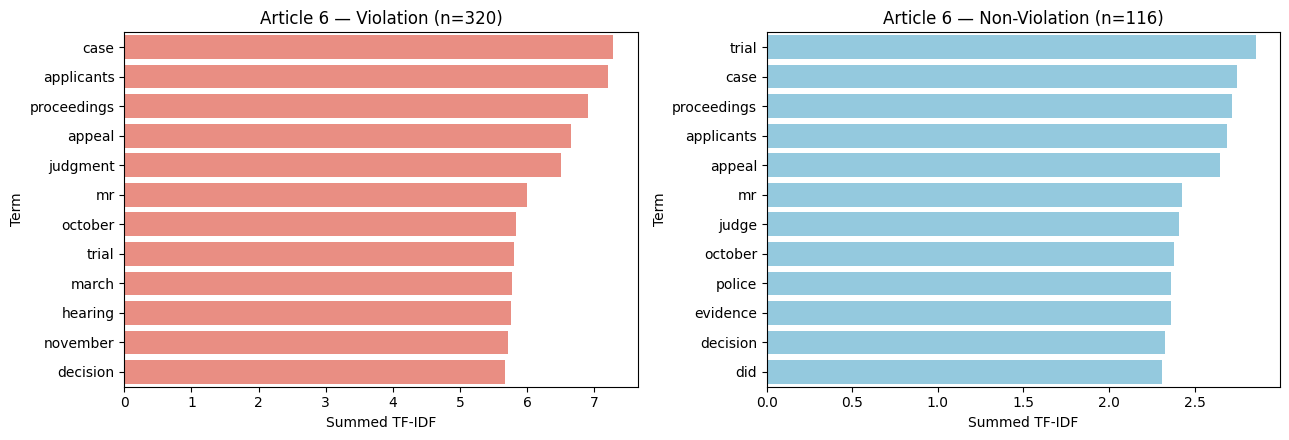

In [14]:
# §4.1 — TF-IDF top terms for Violation vs Non-Violation (Article 6 only)
# Uses the same legal_tokenizer defined later in §6 (TF-IDF Baselines), so the
# vocabulary here matches the SVM/LogReg inputs.
from sklearn.feature_extraction.text import TfidfVectorizer

_viol_texts = df.loc[df['label'] == 1, 'text'].dropna().tolist()
_nviol_texts = df.loc[df['label'] == 0, 'text'].dropna().tolist()

def _top_tfidf(texts, n=10, ngram_range=(1, 2), min_df=3):
    vec = TfidfVectorizer(
        ngram_range=ngram_range, min_df=min_df, max_df=0.90,
        stop_words='english', sublinear_tf=True,
    )
    X = vec.fit_transform(texts)
    summed = np.asarray(X.sum(axis=0)).ravel()
    feats = vec.get_feature_names_out()
    idx = summed.argsort()[::-1][:n]
    return pd.DataFrame({'term': feats[idx], 'score': summed[idx]})

_top_v  = _top_tfidf(_viol_texts,  n=12)
_top_nv = _top_tfidf(_nviol_texts, n=12)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(data=_top_v,  x='score', y='term', ax=axes[0], color='salmon')
axes[0].set_title(f'Article 6 — Violation (n={len(_viol_texts)})')
axes[0].set_xlabel('Summed TF-IDF'); axes[0].set_ylabel('Term')
sns.barplot(data=_top_nv, x='score', y='term', ax=axes[1], color='skyblue')
axes[1].set_title(f'Article 6 — Non-Violation (n={len(_nviol_texts)})')
axes[1].set_xlabel('Summed TF-IDF'); axes[1].set_ylabel('Term')
plt.tight_layout(); plt.show()


### 4.2 Scattertext — Two-Dimensional Term Comparison

Scattertext (Kessler, 2017) places each term on a 2-D map where the X-axis is its rank in the **Non-Violation** class and the Y-axis is its rank in the **Violation** class.

How to read the plot:
- **Terms in the upper-left are V-leaning: they rank more highly in Violation than in Non-Violation.**
- **Terms in the lower-right are NV-leaning: they rank more highly in Non-Violation than in Violation.**
- Terms along the **diagonal** are equally ranked in both classes — generic legal vocabulary.
- Click any term in the interactive HTML version (saved to `scattertext_viz_light.html`) to see characteristic in-context excerpts.

Compared with TF-IDF (§4.1), Scattertext shows the same core finding — a dominant diagonal of shared legal vocabulary with only slight directional drift between classes — but with explicit visualisation of term positioning rather than aggregated scores.

In [15]:
# §4.2 — Scattertext on Article 6 V vs NV
import scattertext as st
import os

# legal_tokenizer fallback (so this cell can run before §6)
if 'legal_tokenizer' not in dir():
    from nltk.corpus import stopwords as _sw
    from nltk.stem import WordNetLemmatizer as _WNL
    _LS = set(_sw.words('english')) | {'court','case','mr','mrs','ms'}
    _wnl = _WNL()
    _LM_MAP = {'authorities':'authority','applicants':'applicant','proceedings':'proceeding',
               'rights':'right','violations':'violation','articles':'article'}
    def legal_tokenizer(text):
        toks = [t for t in str(text).lower().split() if t.isalpha() and t not in _LS]
        return [_LM_MAP.get(t, _wnl.lemmatize(t, pos='n')) for t in toks]

# Stratified sample (Scattertext is heavy on a full corpus; cap each class)
SAMPLE_PER_CLASS = 150
_sx = (df.assign(label_name=df['label'].map({1:'Violation', 0:'Non-Violation'}))
         .dropna(subset=['text','label_name'])
         .groupby('label_name', group_keys=False)
         .apply(lambda x: x.sample(n=min(SAMPLE_PER_CLASS, len(x)), random_state=42))
         .reset_index(drop=True))

# Light lexical normalisation (re-uses legal_tokenizer)
_sx['text_lex'] = _sx['text'].astype(str).apply(
    lambda t: ' '.join(legal_tokenizer(t))
)
_sx = _sx[_sx['text_lex'].str.strip() != ''].reset_index(drop=True)
# pandas >=3.0: groupby().apply() may drop grouping columns; reconstruct if needed
if 'label_name' not in _sx.columns:
    _sx['label_name'] = _sx['label'].map({1: 'Violation', 0: 'Non-Violation'})
print(f'Scattertext sample sizes: {_sx["label_name"].value_counts().to_dict()}')

corpus = (st.CorpusFromPandas(
            _sx, category_col='label_name', text_col='text_lex',
            nlp=st.whitespace_nlp_with_sentences)
          .build()
          .get_unigram_corpus()
          .compact(st.AssociationCompactor(1200)))

html = st.produce_scattertext_explorer(
    corpus,
    category='Violation', category_name='Violation', not_category_name='Non-Violation',
    minimum_term_frequency=8, width_in_pixels=1000,
    metadata=_sx['respondent'] if 'respondent' in _sx.columns else None,
    transform=st.Scalers.dense_rank,
)
html = html.replace('<!--D3FCURL-->', 'https://cdnjs.cloudflare.com/ajax/libs/d3/5.16.0/d3.min.js')

# Save HTML
_html_path = 'scattertext_viz_light.html'
with open(_html_path, 'w', encoding='utf-8') as f:
    f.write(html)
print(f'Interactive HTML saved → {_html_path}')

Scattertext sample sizes: {'Violation': 150, 'Non-Violation': 116}


KeyboardInterrupt: 

In [ ]:
# Capture screenshot as PNG (renders on GitHub where IFrame is stripped)
image_cache_path = "scattertext_viz.png"
if os.path.exists(image_cache_path):
    _ = plt.figure(figsize=(14, 12))
    plt.imshow(plt.imread(image_cache_path))
    plt.axis("off")
else:
    try:
        import subprocess
        from IPython.display import Image, IFrame, display
        
        subprocess.run([
            'google-chrome', '--headless', '--disable-gpu', '--no-sandbox',
            f'--screenshot={image_cache_path}', '--window-size=1100,800',
            '--hide-scrollbars',
            f'file://{html_path}'
        ], capture_output=True, timeout=3000)
        
        if os.path.exists(image_cache_path):
            display(Image(filename=image_cache_path))
            print("(For interactive version, open scattertext_viz.html in a browser)")
        else:
            raise FileNotFoundError("Screenshot not created")
    except Exception as e:
        print(f"Screenshot capture skipped: {e}")
        # Fallback: display interactive IFrame in Jupyter
        display(IFrame('scattertext_viz.html', width=1050, height=700))

**Reading the scatter (PNG above; HTML for interactive exploration).** The dominant pattern is a dense diagonal band of shared legal vocabulary rather than clearly separated class clusters. Terms such as *court*, *applicant*, *proceeding*, *judgment*, *case*, and *appeal* sit in this central zone.

Outside that diagonal, there are only slight positional drifts rather than clearly defined upper-left (V) or lower-right (NV) lexical blocs.

The Scattertext figure should therefore be interpreted cautiously. Its main contribution is to show lexical overlap and only weak directional drift between classes, not to visually confirm sharply separated V- and NV-leaning term clusters. The reason a TF-IDF SVM still works on this corpus is that even a modest non-diagonal signal — vocabulary that systematically differs between V and NV cases — is enough for a linear classifier to find a hyperplane, even though most of the lexical mass is class-agnostic boilerplate.

### 4.3 Proportion Shift (with Shifterator) shows contrasts of the lexical signals

Proportion Shift (top 20 words) expands TF-IDF and Scattertext findings to more quantitatively weigh words that are highly discriminative for V and NV. Specifically, Violation related vocabulary clusters around four themes:

- **Subject:** `applicant` has stronger skew toward Violations here.
- **Procedural:** `appeal`, `hearing`, `proceeding`
- **Month of year:** March, April, October, May, January, June
- **Incarceration:** `cell` / `prison`


In [ ]:
# §4.3 — Proportion Shift: top 20 discriminative words for Violation vs Non-Violation
# (port of EDA.ipynb §6.3; uses Shifterator's ProportionShift; requires the `shifterator` package)
try:
    import shifterator as sh
except ImportError:
    import subprocess, sys as _sys
    subprocess.run([_sys.executable, '-m', 'pip', 'install', '-q', 'shifterator'], check=True)
    import shifterator as sh

from collections import Counter

# legal_tokenizer is defined in §6 below; if cells run top-to-bottom and §6 has not yet
# executed, define a minimal version here so this cell is self-sufficient.
if 'legal_tokenizer' not in dir():
    from nltk.corpus import stopwords as _sw
    from nltk.stem import WordNetLemmatizer as _WNL
    _LS = set(_sw.words('english')) | {'court','case','mr','mrs','ms'}
    _wnl = _WNL()
    _LM_MAP = {'authorities':'authority','applicants':'applicant','proceedings':'proceeding',
               'rights':'right','violations':'violation','articles':'article'}
    def legal_tokenizer(text):
        toks = [t for t in str(text).lower().split() if t.isalpha() and t not in _LS]
        return [_LM_MAP.get(t, _wnl.lemmatize(t, pos='n')) for t in toks]

def _get_counts(texts):
    """Count tokens after the same legal-aware tokenisation used in §4.1, §4.3, §4.4."""
    c = Counter()
    for t in texts:
        c.update(legal_tokenizer(t))
    return dict(c)

_count_v  = _get_counts(_viol_texts)
_count_nv = _get_counts(_nviol_texts)

prop_shift = sh.ProportionShift(type2freq_1=_count_nv, type2freq_2=_count_v)
_scores = prop_shift.type2shift_score
_sorted = sorted(_scores.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
_sorted = sorted(_sorted, key=lambda x: x[1])

words  = [w for w, _ in _sorted]
vals   = [s for _, s in _sorted]
colors = ['salmon' if v > 0 else 'skyblue' for v in vals]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(words, vals, color=colors)
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_title('Article 6 — Proportion Shift (top 20 discriminative tokens)')
ax.set_xlabel('Proportion shift score  (→ Violation)')
plt.tight_layout(); plt.show()

**Shifterator's native shift graph** (below) presents the same proportion-shift information in the canonical "shift fingerprint" visualisation (Gallagher et al., 2021). Yellow bars represent terms that are more frequent in the Violation class; purple bars represent terms that are more frequent in the Non-Violation class. The horizontal axis is the weighted shift score.


In [ ]:
# §4.3 — Native Shifterator shift graph (canonical visualization)
# Reuses _count_v / _count_nv from the cell above.
prop_shift_native = sh.ProportionShift(type2freq_1=_count_nv, type2freq_2=_count_v)
prop_shift_native.get_shift_graph(
    system_names=['Non-Violation', 'Violation'],
    title='Proportion Shift: Non-Violation → Violation  (Article 6)',
    cumulative_inset=True,
    text_size_inset=False,
)
plt.show()

### 4.4 Per-Country Proportion Shift — Does the Lexical Signal Hold Across Countries?

The §4.1 / §4.3 plots aggregate across all three countries. A natural follow-up question is whether the Violation/Non-Violation distinction is detectable at the country level too — i.e. whether the model could in principle separate V from NV *within* each respondent state without relying on country identity as a shortcut. The three-panel figure below splits the corpus by country and computes a separate Proportion-Shift between V and NV cases inside each.

What to look for:
- Words on the **right** (positive shift) skew toward violation; on the **left** (negative shift) toward non-violation.
- All three countries have a mix of overlaps and also unique themes.


In [ ]:
# §4.4 — Per-country Proportion-Shift (Article 6 subset)
# Shows the V vs NV vocabulary inside each respondent state separately.
import shifterator as sh

def _country_get_counts(texts):
    """Token-count dict, using the same legal_tokenizer as §4.1."""
    cnt = {}
    for t in texts.fillna(''):
        for tok in legal_tokenizer(t):
            cnt[tok] = cnt.get(tok, 0) + 1
    return cnt

# Note: legal_tokenizer is defined in §6 below; for the EDA we replicate the
# minimal tokenisation here (lowercase + isalpha + stop-word filter) so this
# cell does not depend on cell-execution order.
from nltk.corpus import stopwords as _sw
from nltk.stem import WordNetLemmatizer as _WNL
_LS = set(_sw.words('english')) | {'court','case','mr','mrs','ms'}
_wnl = _WNL()
_LM_MAP = {'authorities':'authority','applicants':'applicant','proceedings':'proceeding',
           'rights':'right','violations':'violation','articles':'article'}
def _eda_tok(text):
    toks = [t for t in str(text).lower().split() if t.isalpha() and t not in _LS]
    return [_LM_MAP.get(t, _wnl.lemmatize(t, pos='n')) for t in toks]
def _country_get_counts(texts):
    cnt = {}
    for t in texts.fillna(''):
        for tok in _eda_tok(t):
            cnt[tok] = cnt.get(tok, 0) + 1
    return cnt

countries = sorted(df['respondent'].dropna().unique())
fig, axes = plt.subplots(1, len(countries), figsize=(6 * len(countries), 8))
axes = np.atleast_1d(axes)

for idx, country in enumerate(countries):
    cdf = df[df['respondent'] == country]
    cv = cdf[cdf['label'] == 1]['text'].dropna()
    cn = cdf[cdf['label'] == 0]['text'].dropna()
    if len(cv) < 5 or len(cn) < 5:
        axes[idx].text(0.5, 0.5, f'{country}: insufficient data', ha='center', va='center',
                       transform=axes[idx].transAxes)
        axes[idx].set_title(country, fontweight='bold'); continue
    ps = sh.ProportionShift(type2freq_1=_country_get_counts(cn),
                            type2freq_2=_country_get_counts(cv))
    sc = ps.type2shift_score
    top20 = sorted(sc.items(), key=lambda x: abs(x[1]), reverse=True)[:20]
    top20 = sorted(top20, key=lambda x: x[1])
    words = [w for w, _ in top20]
    vals  = [v for _, v in top20]
    cols  = ['#d62728' if v > 0 else '#1f77b4' for v in vals]
    axes[idx].barh(words, vals, color=cols)
    axes[idx].axvline(0, color='black', lw=0.5)
    axes[idx].set_title(f'{country}  (n_V={len(cv)}, n_NV={len(cn)})',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Proportion-shift score')
    if idx == 0: axes[idx].set_ylabel('Token')

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#d62728', label='→ Violation'),
    Patch(facecolor='#1f77b4', label='→ Non-Violation'),
], loc='upper center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, 1.02))
plt.suptitle('Per-Country Proportion-Shift — Top 20 discriminative tokens',
             fontsize=14, y=1.05)
plt.tight_layout(); plt.show()

**Reading the three panels (numbers above are reproduced from the actual proportion-shift output).** We see repeated procedural delay terms across all 3 countries (*appeal*, *hearing*, *december*, *may*, *january*, *march*), but each country has its own thematic supplement:

- **GBR**: violation tokens cluster around **procedural-process vocabulary** (*appeal*, *hearing*, *prison*, *legal*). Non-violation tokens are case-type-specific and seem to be jury-trial complaints and family/social-welfare cases (*jury*, *child*, *mother*, *site*, *gypsy*) — The within-GBR signal is real but weak in magnitude (max |Δ| ≈ 0.012).
- **RUS**: violation tokens cluster around **geographic-institutional markers** (*Moscow*, *authority*). Non-violation tokens cluster around inmates being incarcerated (*inmate*, *cell*).
- **TUR**: violation tokens cluster around **state-security and assize-court** vocabulary (*state*, *administrative*, *istanbul*, *security*, *judgment*, *cassation*, *assize*, *military*, *execution*). Non-Violation tokens are dominated by named individuals from a narrow factual cluster, especially (*cemal*, *uçar*, *village*).

**Why this matters.** The per-country shifts suggest that the predictive signal is partly shared across countries and partly local to each national case mix. What the model can learn is therefore not a single country-invariant Article 6 vocabulary, but a layered pattern: common procedural-delay language plus country-specific institutional and factual supplements.

| Country | NV case archetype | V case archetype |
| ----- | ----- | ----- |
| GBR | Case-type-specific vocabulary, including jury-trial and family/social-context terms | Procedural-process vocabulary with month markers, including *appeal*, *hearing*, *prison*, *legal*, *December*, *May*, *January*, and *March*. |
| RUS | Detention-related vocabulary | A mix of shared procedural-delay terms and Russian-specific geographic-institutional markers |
| TUR | A few atypical cases (e.g., specific individuals) | A mix of shared procedural-delay terms and State Security Court / Assize Court / military proceedings |


### 4.5 Fighting Words — Weighted Log-Odds with Uninformative Dirichlet Prior

§4.1–4.3 use TF-IDF, Scattertext, and proportion-shift to surface discriminative vocabulary. These methods are sensitive to absolute frequency: a word that appears 1000× in the V class and 0× in the NV class will dominate the chart, even if its appearance is concentrated in just one or two cases.

**Fighting Words** (Monroe et al. 2008) addresses this with a weighted log-odds-ratio statistic, smoothed by an *uninformative Dirichlet prior*. For each term *w*:

$$\hat{\zeta}_{w}^{(V-NV)} = \frac{\log\frac{n_{w,V}+\alpha}{n_V+\alpha V - n_{w,V}-\alpha} - \log\frac{n_{w,NV}+\alpha}{n_{NV}+\alpha V - n_{w,NV}-\alpha}}{\sqrt{\frac{1}{n_{w,V}+\alpha} + \frac{1}{n_{w,NV}+\alpha}}}$$

The numerator is a log-odds difference; the denominator is its standard error. The ratio is therefore a *z-score* — large absolute values flag words that are robustly discriminative across the corpus, not just frequent in a single document. By convention |z| ≥ 1.96 marks two-sided 95% statistical significance.

The plot below puts each term at (frequency, z-score) — significant terms in black, non-significant in grey. The right margin lists the top 20 V-side and top 20 NV-side terms ranked by |z|.

In [ ]:
# §4.5 — Fighting Words (Monroe et al. 2008) on Article 6 V vs NV
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.gridspec as gridspec

def _fighting_words(texts_v, texts_nv, top_n=20, prior_alpha=0.01, min_df=5, max_df=0.9):
    """Monroe et al. 2008 weighted log-odds with uninformative Dirichlet prior."""
    texts_v  = pd.Series(texts_v).dropna().astype(str)
    texts_nv = pd.Series(texts_nv).dropna().astype(str)
    all_texts = pd.concat([texts_v, texts_nv], ignore_index=True)

    vec = CountVectorizer(
        tokenizer=legal_tokenizer, token_pattern=None, lowercase=False,
        ngram_range=(1, 1), min_df=min_df, max_df=max_df,
    )
    vec.fit(all_texts)
    vocab = np.array(vec.get_feature_names_out())
    X_v   = vec.transform(texts_v)
    X_nv  = vec.transform(texts_nv)

    y_v   = np.asarray(X_v.sum(axis=0)).ravel().astype(float)
    y_nv  = np.asarray(X_nv.sum(axis=0)).ravel().astype(float)
    n_v, n_nv = y_v.sum(), y_nv.sum()
    y_total   = y_v + y_nv
    V         = len(vocab)
    a         = float(prior_alpha)

    delta = (np.log((y_v  + a) / (n_v  + a*V - y_v  - a))
           - np.log((y_nv + a) / (n_nv + a*V - y_nv - a)))
    var   = 1.0/(y_v + a) + 1.0/(y_nv + a)
    z     = delta / np.sqrt(var)

    sorted_idx = np.argsort(z)
    nv_idx = sorted_idx[:top_n]                # most negative -> Non-Violation
    v_idx  = sorted_idx[-top_n:][::-1]         # most positive -> Violation

    # ── Two-panel layout: scatter (left) + V/NV word lists (right) ──
    fig = plt.figure(figsize=(15, 9))
    gs  = gridspec.GridSpec(2, 2, width_ratios=[3.2, 1], height_ratios=[1, 1],
                            wspace=0.05, hspace=0.05)
    ax_scat = fig.add_subplot(gs[:, 0])    # left column, both rows
    ax_v    = fig.add_subplot(gs[0, 1])    # top-right
    ax_nv   = fig.add_subplot(gs[1, 1])    # bottom-right

    # ── Scatter ──
    sig = np.abs(z) >= 1.96
    sizes = np.clip(np.abs(z) * 5, 8, None)
    ax_scat.scatter(y_total[~sig], z[~sig], c='lightgray', s=sizes[~sig],
                    alpha=0.5, edgecolors='none')
    ax_scat.scatter(y_total[sig],  z[sig],  c='#222',      s=sizes[sig],
                    alpha=0.9, edgecolors='none')
    # Highlight only the top-N points in each direction (no inline labels;
    # the right-side panels enumerate them — eliminates the previous overlap).
    ax_scat.scatter(y_total[v_idx],  z[v_idx],  s=60, facecolors='none',
                    edgecolors='#d6604d', linewidths=1.4)
    ax_scat.scatter(y_total[nv_idx], z[nv_idx], s=60, facecolors='none',
                    edgecolors='#4393c3', linewidths=1.4)

    ax_scat.set_xscale('log')
    ax_scat.axhline( 1.96, color='#999', ls=':',  lw=0.8)
    ax_scat.axhline(-1.96, color='#999', ls=':',  lw=0.8)
    ax_scat.axhline( 0,    color='#444', ls='--', lw=0.6)
    ax_scat.set_xlim(left=1, right=max(y_total.max() * 5, 10))
    ax_scat.set_xlabel('Term total frequency (log scale)')
    ax_scat.set_ylabel(r'$\hat{\zeta}^{(V - NV)}$  (z-score; +ve → V, −ve → NV)')
    ax_scat.set_title('Fighting Words: weighted log-odds (uninformative Dirichlet prior, α=0.01)\n'
                      'Article 6 — Violation vs Non-Violation',
                      fontsize=12, pad=10, fontweight='bold')
    ax_scat.spines['top'].set_visible(False)
    ax_scat.spines['right'].set_visible(False)

    # ── Word-list panels (no axis ticks; styled boxes) ──
    def _word_panel(ax, words_idx, color_face, color_edge, title):
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0.02, 0.02), 0.96, 0.96, facecolor=color_face,
                                   edgecolor=color_edge, linewidth=1.5))
        ax.text(0.5, 0.93, title, ha='center', va='top', fontsize=11,
                fontweight='bold', color=color_edge, transform=ax.transAxes)
        # Two columns of 10 words each
        words = list(vocab[words_idx])
        col1, col2 = words[:10], words[10:]
        for j, w in enumerate(col1):
            ax.text(0.10, 0.83 - j*0.075, f'{j+1:>2}. {w}',
                    fontsize=9.5, ha='left', va='top', family='monospace')
        for j, w in enumerate(col2):
            ax.text(0.55, 0.83 - j*0.075, f'{j+11:>2}. {w}',
                    fontsize=9.5, ha='left', va='top', family='monospace')

    _word_panel(ax_v,  v_idx,  '#fff4f0', '#d6604d', 'Top  → Violation')
    _word_panel(ax_nv, nv_idx, '#f0f4ff', '#4393c3', 'Top  → Non-Violation')

    plt.show()

    top_v_df  = pd.DataFrame({'term': vocab[v_idx],  'z_score': z[v_idx],
                              'v_count': y_v[v_idx].astype(int),
                              'nv_count': y_nv[v_idx].astype(int)})
    top_nv_df = pd.DataFrame({'term': vocab[nv_idx], 'z_score': z[nv_idx],
                              'v_count': y_v[nv_idx].astype(int),
                              'nv_count': y_nv[nv_idx].astype(int)})
    return top_v_df, top_nv_df

# legal_tokenizer is defined in §6 below; if cells are run in order from the top,
# define a minimal local version here so this cell is self-sufficient.
if 'legal_tokenizer' not in dir():
    from nltk.corpus import stopwords as _sw
    from nltk.stem import WordNetLemmatizer as _WNL
    _LS = set(_sw.words('english')) | {'court','case','mr','mrs','ms'}
    _wnl = _WNL()
    _LM_MAP = {'authorities':'authority','applicants':'applicant','proceedings':'proceeding',
               'rights':'right','violations':'violation','articles':'article'}
    def legal_tokenizer(text):
        toks = [t for t in str(text).lower().split() if t.isalpha() and t not in _LS]
        return [_LM_MAP.get(t, _wnl.lemmatize(t, pos='n')) for t in toks]

violation_texts     = df.loc[df['label']==1, 'text'].dropna()
non_violation_texts = df.loc[df['label']==0, 'text'].dropna()

top_v_fw, top_nv_fw = _fighting_words(violation_texts, non_violation_texts,
                                       top_n=20, prior_alpha=0.01, min_df=5, max_df=0.9)

print('\n=== Top 20 Violation fighting words (by |z|) ===')
print(top_v_fw.to_string(index=False))
print('\n=== Top 20 Non-Violation fighting words (by |z|) ===')
print(top_nv_fw.to_string(index=False))

**What the Fighting Words plot adds over the previous sections.** The y-axis is a *significance-normalised* log-odds, and only terms with |z| ≥ 1.96 stand out as statistically robust.

→ Violation (top z-scores): still dominated by procedural and 'month of year' language, such as *hearing*, *appeal*, *proceeding*, *district*, *detention*, *delay*, *administrative*, *February*, *May*, *June*.

→ Non-Violation (most negative z-scores): anchored by tokens like *jury*, *mother*, *child*, *official*, *family*, *local*, *disclosure*, *surveillance*, and *recording*.

The key implication is that even the "cleaned" signal still blends legal vocabulary with contextual markers, so the chart by itself cannot show whether the classifier is detecting legal substance or dataset provenance. A reader of this chart cannot, from the chart alone, tell whether a model trained on these features would be doing legal reasoning or predicting based on contextual shortcuts. That ambiguity is what motivates the §11 bias probes.

### 4.6 NLTK Concordance — Words in Context

§4.1–§4.5 are aggregate-frequency views: each token gets one number per class. Concordance pulls in the *opposite* direction — for a chosen token, it shows actual surrounding text from a sample of FACTS sections. This is useful for two questions that frequency statistics cannot answer:

- **Are seemingly-important terms procedural boilerplate or substantive content?** A word like `applicant` is high-frequency in V cases not because of legal merits but because it is the standard ECHR convention for naming a complainant.
- **Do the temporal/geographic shortcut tokens actually function as the §11 analyses claim?** If `december` is a §4.4 V-discriminative term, concordance lines should show it appearing in scheduling-of-hearing contexts, not as a year-end legal-doctrine convention.

The next cell prints a small sample of concordance lines for four token-groups: month names, applicant/police/judge subjects, action verbs, and a handful of country-specific tokens that surface elsewhere in the analysis.

In [ ]:
# §4.6 — NLTK Concordance: words in context (sample-based)
from nltk import word_tokenize
from nltk.text import Text
import nltk

for _pkg in ('punkt', 'punkt_tab'):
    try: nltk.data.find(f'tokenizers/{_pkg}')
    except LookupError: nltk.download(_pkg, quiet=True)

SAMPLE_N        = 50
LINES_PER_WORD  = 5
WORD_LISTS = [
    ('Month markers (temporal shortcut candidates)',
        ['may', 'october', 'march', 'december', 'june']),
    ('Subjects',
        ['applicant', 'police', 'criminal', 'prosecutor', 'judge']),
    ('Action verbs / procedural nouns',
        ['proceeding', 'decision', 'appeal', 'judgment', 'detention']),
    ('Country-specific tokens',
        ['moscow', 'prison', 'assize', 'district']),
]

_dfc = df.copy()
_dfc = _dfc[_dfc['text'].fillna('').astype(str).str.strip().ne('')]
_sample = _dfc.sample(n=min(SAMPLE_N, len(_dfc)), random_state=42)

_raw  = ' '.join(_sample['text'].fillna('').astype(str).tolist()).lower()
_toks = word_tokenize(_raw)
_text = Text(_toks)

print(f'Concordance corpus: {len(_sample)} sampled FACTS documents, {len(_toks):,} tokens.')
print()

for _list_name, _word_list in WORD_LISTS:
    print('#' * 100)
    print(f'## {_list_name}')
    print('#' * 100)
    for _w in _word_list:
        print(f'\n>>> "{_w}"')
        try:
            _text.concordance(_w, width=110, lines=LINES_PER_WORD)
        except Exception as _e:
            print(f'   (no occurrence: {_e})')

**What concordance adds.** Reading the printed lines confirms — at the per-line level — what aggregate frequencies suggested:

- **Month names** appear in *scheduling* / *hearing-of-* contexts (e.g. *"the hearing scheduled for 22 May…"*, *"adjourned on 13 December because…"*). The §4.4 z-score that flagged `december` as V-discriminative reflects this scheduling-event role, not anything legally substantive about the month itself. Models that latch onto month tokens are picking up calendar markers in chronologies, exactly as §11.7's whole-case reading argues.
- **`applicant`, `police`, `prosecutor`** are convention-neutral and appear in both V and NV contexts — high frequency does not imply discriminative power.
- **Country-specific tokens** (`moscow`, `prison`, `assize`, `district`) appear *only* in their country's cases, with no neighbouring legal-doctrine vocabulary — confirming the §11 finding that they function as country-identity markers, not as portals into legal substance.

The concordance view is what the close-reading analysis in §11.7 extends to whole cases: the lines here are 110-character windows; §11.7 reads each case end-to-end.

---

**Overall, Section 4 shows that the V/NV distinction is already visible in the raw vocabulary of the FACTS sections before any predictive model is fitted. The recurring signal is not mainly doctrinal Article 6 reasoning, but procedural chronology, temporal markers, and country-institutional vocabulary.**

**(i) Procedural mask and lexical divergence (§4.1 and §4.2).** TF-IDF and Scattertext together show that much of the corpus is covered by shared legal boilerplate such as *proceeding*, *decision*, *judgment*, and *applicant*, which appears across both classes and carries little predictive force. What separates V from NV is the non-shared vocabulary around that common legal core.

**(ii) Provenance-rich proxies sit inside the lexical split (§4.3–§4.5).** The proportion-shift and Fighting Words analyses suggest that models can exploit country-specific institutional vocabulary and recurring procedural narratives rather than legal doctrine itself. In that sense, the predictive signal is often a proxy for where and how a case arose, not a representation of the legal mechanism of violation.

**(iii) Concordance clarifies what those tokens are doing (§4.6).** The concordance lines show that many high-signal terms function as chronology or provenance markers: month names appear in hearing schedules and procedural timelines, while tokens such as *moscow*, *prison*, and *assize* point to country-specific factual settings. This is the lexical substrate later classifiers exploit.

## 5. Topic Analysis

**NMF (Non-Negative Matrix Factorization)** is run on the full Article 6 corpus — no train/test split, this is corpus-level structure analysis. NMF with TF-IDF input produces sparser, more interpretable topics than LDA on a small legal corpus: each word contributes additively to a topic and topics tend to be more legible.

Goals:
1. Identify latent thematic clusters in the FACTS sections.
2. Check whether topics distribute differently across **violation vs non-violation** cases.
3. Check whether topics distribute differently across **respondent countries** (geographic shortcuts).
4. **Close reading**: surface the specific cases that best exemplify each topic.

The output of §5 feeds directly into §11: the topic-LR coefficients in §5.2 are the topic-level counterpart of the SVM word-coefficients in §11.1, and the close-reading exemplars in §5.3 are the entry points for the whole-case reading in §11.7.

In [ ]:
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

N_TOPICS  = 10
TOP_WORDS = 20
TOP_K_CASES = 3   # representative cases per topic for close reading

MANUAL_LEMMA_MAP = {
    'authorities': 'authority', 'applicants': 'applicant',
    'proceedings': 'proceeding', 'rights': 'right',
    'violations': 'violation',  'articles': 'article',
}
LEGAL_STOP = set(stopwords.words('english')) | {'court', 'case', 'mr', 'mrs', 'ms'}
wnl = WordNetLemmatizer()

def legal_tokenizer(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in LEGAL_STOP]
    return [MANUAL_LEMMA_MAP.get(t, wnl.lemmatize(t, pos='n')) for t in tokens]

# ── TF-IDF matrix ────────────────────────────────────────────────────────────
_tfidf = TfidfVectorizer(
    tokenizer=legal_tokenizer, preprocessor=None, token_pattern=None,
    lowercase=False, min_df=3, max_df=0.90, ngram_range=(1, 1),
    sublinear_tf=True,
)
_T_nmf   = _tfidf.fit_transform(df['text'].fillna(''))
_vocab_nmf = np.array(_tfidf.get_feature_names_out())
print(f'TF-IDF matrix: {_T_nmf.shape[0]} docs | {_T_nmf.shape[1]} terms')

# ── Fit NMF ──────────────────────────────────────────────────────────────────
_nmf = NMF(n_components=N_TOPICS, init='nndsvda', random_state=42,
           max_iter=300, l1_ratio=0.1)
_nmf_raw    = _nmf.fit_transform(_T_nmf)               # (N, k) unnormalised
_row_sums   = _nmf_raw.sum(axis=1, keepdims=True)
_nmf_topics = _nmf_raw / np.maximum(_row_sums, 1e-9)  # row-normalised
print(f'NMF reconstruction error: {_nmf.reconstruction_err_:.4f}\n')

# ── Top words per topic ───────────────────────────────────────────────────────
_nmf_topic_list = []
print(f'{"Topic":<8}  Top 20 words')
print('-' * 90)
for i, comp in enumerate(_nmf.components_):
    top_idx   = comp.argsort()[:-TOP_WORDS-1:-1]
    top_words = _vocab_nmf[top_idx].tolist()
    _nmf_topic_list.append({'id': i, 'top_words': top_words})
    print(f'  T{i:<5}  {chr(10).join([", ".join(top_words[j:j+10]) for j in range(0,len(top_words),10)])}')
    print()


### 5.1 Topic Descriptor Words — Visualization

The console listing above gives the top 20 words per topic in plain text. To make the descriptor words **visually inspectable**, the figure below renders the top 12 words for each of the ten topics as a heatmap of NMF component weights. Darker cells = larger weight = stronger contribution of that word to the topic. This is the artefact a reader should consult before reading the topic-name labels in the rest of §5 — the labels (e.g. *"T3 — Turkish State Security Courts"*) are our interpretation; the heatmap is the ground truth the interpretation rests on.

In [ ]:
# ── Heatmap: top descriptor words per topic, with NMF component weights ────
# Each row is a topic; each column is one of its top words. Cell value is the
# raw NMF component weight (H[topic, word]) — i.e. how strongly the word
# contributes to that topic. Words are NOT shared across columns; each topic
# has its own ordered top-word list (annotated in-cell).

TOP_WORDS_HEATMAP = 12
fig, ax = plt.subplots(figsize=(15, 5.5))

# Build the per-topic word matrix
word_matrix = np.zeros((N_TOPICS, TOP_WORDS_HEATMAP))
word_labels = np.empty((N_TOPICS, TOP_WORDS_HEATMAP), dtype=object)
for ti, comp in enumerate(_nmf.components_):
    top_idx = comp.argsort()[::-1][:TOP_WORDS_HEATMAP]
    word_matrix[ti] = comp[top_idx]
    word_labels[ti] = _vocab_nmf[top_idx]

# Normalise each row so colour scale reflects intra-topic salience
row_max = word_matrix.max(axis=1, keepdims=True)
word_matrix_norm = word_matrix / np.maximum(row_max, 1e-9)

im = ax.imshow(word_matrix_norm, aspect='auto', cmap='YlGnBu')

# Annotate every cell with the word + weight
for ti in range(N_TOPICS):
    for wi in range(TOP_WORDS_HEATMAP):
        w = word_labels[ti, wi]
        v = word_matrix[ti, wi]
        # Pick text colour for contrast
        bg = word_matrix_norm[ti, wi]
        col = 'white' if bg > 0.55 else 'black'
        ax.text(wi, ti, f'{w}\n{v:.2f}', ha='center', va='center',
                fontsize=7, color=col)

ax.set_yticks(range(N_TOPICS))
ax.set_yticklabels([f'T{i}' for i in range(N_TOPICS)], fontsize=10)
ax.set_xticks(range(TOP_WORDS_HEATMAP))
ax.set_xticklabels([f'#{i+1}' for i in range(TOP_WORDS_HEATMAP)], fontsize=9)
ax.set_xlabel('Top-word rank within topic')
ax.set_title('NMF Topic Descriptor Words — top 12 words per topic '
             '(cell colour = within-topic salience, value = NMF component weight)',
             fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.7, label='Word weight (row-normalised)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Mean topic weight: violation vs no-violation ──────────────────────────────
_nmf_by_label = (
    pd.DataFrame(_nmf_topics)
    .assign(label=df['label'].values)
    .groupby('label').mean().T
)
_nmf_by_label.columns = ['No Violation', 'Violation']
_nmf_by_label['Δ (V−NV)'] = _nmf_by_label['Violation'] - _nmf_by_label['No Violation']
_nmf_by_label = _nmf_by_label.sort_values('Δ (V−NV)', ascending=False)
_nmf_by_label.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_label.index
]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(
    _nmf_by_label[['No Violation', 'Violation']],
    annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
axes[0].set_title('NMF — Mean topic weight by outcome', fontsize=11)

colors_nmf = ['salmon' if v > 0 else 'steelblue' for v in _nmf_by_label['Δ (V−NV)']]
axes[1].barh(range(len(_nmf_by_label)), _nmf_by_label['Δ (V−NV)'], color=colors_nmf)
axes[1].set_yticks(range(len(_nmf_by_label)))
axes[1].set_yticklabels(_nmf_by_label.index, fontsize=8)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Δ mean weight  (Violation − No Violation)')
axes[1].set_title('NMF — Topic skew toward Violation', fontsize=11)
plt.tight_layout()
plt.show()

# ── Mean topic weight: by respondent country ──────────────────────────────────
_nmf_by_country = (
    pd.DataFrame(_nmf_topics)
    .assign(country=df['respondent'].values)
    .groupby('country').mean().T
)
_nmf_by_country.index = [
    f"T{i}: {','.join(_nmf_topic_list[i]['top_words'][:3])}"
    for i in _nmf_by_country.index
]
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    _nmf_by_country, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
)
ax.set_title('NMF — Mean topic weight by Respondent Country', fontsize=11)
plt.tight_layout()
plt.show()

# ── Representative cases per topic (close reading) ────────────────────────────
print('\n=== Representative cases per topic (close reading) ===')
print('Use item_id to look up cases on HUDOC: https://hudoc.echr.coe.int\n')
for t in _nmf_topic_list:
    tid = t['id']
    top_idx = _nmf_topics[:, tid].argsort()[::-1][:TOP_K_CASES]
    print(f"T{tid}: {', '.join(t['top_words'][:8])}")
    print(f"  {'Item ID':<15} {'Country':<8} {'Year':<6} {'Outcome':<14} {'Weight'}")
    print(f"  {'-'*60}")
    for idx in top_idx:
        row     = df.iloc[idx]
        outcome = 'Violation' if row['label'] == 1 else 'No Violation'
        weight  = _nmf_topics[idx, tid]
        print(f"  {row['item_id']:<15} {row['respondent']:<8} {int(row['year']):<6} {outcome:<14} {weight:.3f}")
    print()


### 5.2 Topics as Classification Features — Coefficient Weights (Aletras 2016 style)

Following **Aletras et al. (2016)** and the lab-7 NMF→classifier workflow, we now treat the ten NMF topic weights as a *feature representation* of each case and fit a Logistic Regression classifier to predict Article 6 violation. The model is deliberately interpretable: with only ten input features, the regression coefficient for each topic is a direct measure of *how that topic shifts the predicted log-odds of violation*.

What the coefficient tells us:
- **Positive coefficient** → the topic is associated with **violation** (V); its presence pushes the model toward predicting V.
- **Negative coefficient** → the topic is associated with **no-violation** (NV).
- **Magnitude** → strength of the association on the log-odds scale.

This is the per-topic counterpart of the SVM TF-IDF feature weights shown later in §11.1 — but at the **theme** level rather than the individual-word level, which is what makes it useful as an interpretation aid.

In [ ]:
# ── Aletras 2016 style: NMF topics as classifier features ────────────────
# Fit a LogReg on the row-normalised NMF topic weights (_nmf_topics) and
# inspect per-topic coefficients alongside each topic's top descriptor words.

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

_y_topic = df['label'].values
_topic_clf = LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0,
                                random_state=42)
_topic_clf.fit(_nmf_topics, _y_topic)

# 5-fold cross-validated macro-F1 — context for how predictive 10 topics are
_cv = cross_val_score(
    LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42),
    _nmf_topics, _y_topic,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro',
)
print(f'Topic-only LogReg — 5-fold CV macro-F1: {_cv.mean():.3f} ± {_cv.std():.3f}')
print(f'(For reference: TF-IDF SVM gets ~0.65 macro-F1 on this corpus — see §10.)\n')

# Build the coefficients table
_topic_coef_df = pd.DataFrame({
    'topic'      : [f'T{i}' for i in range(N_TOPICS)],
    'top_words'  : [', '.join(_nmf_topic_list[i]['top_words'][:6]) for i in range(N_TOPICS)],
    'coefficient': _topic_clf.coef_[0],
}).sort_values('coefficient', ascending=False).reset_index(drop=True)

print('Per-topic LogReg coefficients (sorted by coefficient):')
print(_topic_coef_df.to_string(index=False))

# Plot: horizontal bar of coefficients, with the top words as the y-tick label
fig, ax = plt.subplots(figsize=(13, 5.5))
_colors = ['salmon' if c > 0 else 'steelblue' for c in _topic_coef_df['coefficient']]
y_pos = np.arange(len(_topic_coef_df))
ax.barh(y_pos, _topic_coef_df['coefficient'], color=_colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([
    f"{row['topic']}: {row['top_words']}"
    for _, row in _topic_coef_df.iterrows()
], fontsize=9)
ax.invert_yaxis()  # largest at top
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('LogReg coefficient (log-odds of violation)')
ax.set_title('Topics as Classification Features — per-topic coefficient weights\n'
             '(positive ⇒ pushes toward Violation; negative ⇒ pushes toward No-Violation)',
             fontsize=11)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='salmon',    edgecolor='black', label='→ Violation'),
    Patch(facecolor='steelblue', edgecolor='black', label='→ No Violation'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

**How to read this chart.** The sign + magnitude of each coefficient says which topics function as **violation predictors** vs. **no-violation predictors** in this corpus, when expressed as a 10-dim topic representation:

| Sign | Topic | Top words | Why this direction is consistent with the corpus |
|---|---|---|---|
| **+ Violation** | T1 | `karacabey, bursa, execution, civil, land, expropriation` | Turkish land-expropriation non-enforcement — a structural Art. 6 issue with a near-100% violation rate. |
| **+ Violation** | T7 | `total, date, appendix, period, domestic, turkish` | The "appendix of detention dates" format is almost exclusively used in lengthy-detention violation cases. |
| **+ Violation** | T8 | `hearing, district, appeal, adjourned, regional, scheduled` | Procedural-delay vocabulary — the core "reasonable time" violation pattern. |
| **+ Violation** | T3 | `security, assize, state, prosecutor, diyarbakır, istanbul` | Turkish State Security Court proceedings — also near-universal violation. |
| **− No-Violation** | T0 | `evidence, jury, trial, police, defence, prosecution` | UK criminal proceedings with adversarial evidence focus — most are upheld at Strasbourg. |
| **− No-Violation** | T6 | `cell, detention, medical, remand, prison, inmate` | Detention-conditions cases where the *primary* violation tends to be Art. 3, leaving the Art. 6 claim unupheld. |
| **− No-Violation** | T2 | `act, paragraph, section, high, application, legal` | UK statutory / judicial-review proceedings — typically procedurally regular. |

> **What this adds to the SVM word weights in §11.1.** Word-level coefficients show *which surface tokens* the model uses; topic-level coefficients show *which thematic clusters* of vocabulary the model uses. The two views agree: country-marked themes (Turkish state security, Turkish land, Russian pension/judgment-enforcement) and procedural-delay themes carry the violation signal; UK-style adversarial-criminal vocabulary and prison-conditions vocabulary push the other way. This is consistent with the bias finding in §11.5 — the predictive signal is **distributionally encoded across themed vocabulary**, not concentrated in a handful of named entities.

### 5.3 Close-Reading Cases — Top 2 HUDOC Links per Topic per Country

For each NMF topic, the two cases per country with the highest topic weight are listed below.
These are the most *prototypical* examples of each thematic cluster — the best starting points for close reading.

Open a link, read the **FACTS** section, and ask: does the case language match the topic words? Does the model's prediction align with what the Court actually decided?

---

#### T0 — UK jury / criminal evidence  
*(NV-skewed: NV=0.053 vs V=0.025. Dominated by GBR.)*  
Key words: `evidence`, `jury`, `trial`, `police`, `defence`, `prosecution`, `judge`, `counsel`, `crown`  
Typical pattern: UK criminal proceedings — jury directions, evidence admissibility, solicitor access, right to fair criminal trial.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-161738 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-161738) |
| GBR | 001-108072 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-108072) |
| RUS | 001-113289 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-113289) |
| RUS | 001-101589 | 2010 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-101589) |
| TUR | 001-242419 | 2025 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-242419) |
| TUR | 001-217536 | 2022 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-217536) |

---

#### T1 — Turkish land expropriation / enforcement  
*(Turkey-specific: TUR=0.129 vs GBR=0.009, RUS=0.011. V-skewed: V=0.053 vs NV=0.016.)*  
Key words: `karacabey`, `bursa`, `execution`, `civil`, `land`, `expropriation`, `compensation`  
Typical pattern: non-enforcement of domestic judgments awarding land compensation — a structural Art. 6 issue in Turkey related to delayed state compliance. `karacabey` and `bursa` are Turkish place names marking this specific legal dispute pattern.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-82501 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-82501) |
| GBR | 001-59158 | 2001 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-59158) |
| RUS | 001-161946 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-161946) |
| RUS | 001-193870 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193870) |
| TUR | 001-107236 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107236) |
| TUR | 001-107254 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107254) |

---

#### T2 — UK judicial review / statutory proceedings  
*(NV-skewed: NV=0.229 vs V=0.158. Dominated by GBR=0.434.)*  
Key words: `act`, `section`, `high`, `leave`, `solicitor`, `application`, `secretary`, `order`, `legal`  
Typical pattern: UK cases involving statutory interpretation, judicial review applications, and civil proceedings — High Court applications, leave to appeal, Secretary of State decisions, solicitor access issues.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-61549 | 2003 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-61549) |
| GBR | 001-61550 | 2003 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-61550) |
| RUS | 001-105273 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-105273) |
| RUS | 001-150785 | 2015 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-150785) |
| TUR | 001-59677 | 2001 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-59677) |
| TUR | 001-102991 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102991) |

---

#### T3 — Turkish State Security Courts / State-Security vocabulary cluster  
*(Turkey-specific: TUR=0.305 vs GBR=0.032, RUS=0.034. V-skewed: V=0.120 vs NV=0.077.)*  
Key words: `security`, `assize`, `state`, `istanbul`, `diyarbakır`, `prosecutor`, `public`, `illegal`  
Typical pattern: Turkish State Security Court / Assize Court proceedings. Near-universal violation across this corpus.  

**Deep-dive focus.** For the purpose of our analysis, we will focus deeper analysis on T3 as a key topic cluster of interest. The Turkish and ‘State/Security’ themes suggest that **geographic and institutional vocabulary may function as high-correlation proxies for violation outcomes**, rather than requiring the model to represent Article 6 doctrine in any deep way. Sample FACTS excerpts for case IDs `110441`, `79916`, `196410`, and `59853` are printed in the following cell to anchor this discussion.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-59853 | 2001 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-59853) |
| GBR | 001-80932 | 2007 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-80932) |
| RUS | 001-196410 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-196410) |
| RUS | 001-189759 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-189759) |
| TUR | 001-79916 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-79916) |
| TUR | 001-71817 | 2005 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-71817) |


In [ ]:
# §5.3 (T3 deep-dive) — Sample FACTS excerpts for cases 110441 / 79916 / 196410 / 59853
_t3_case_ids = ['001-110441', '001-79916', '001-196410', '001-59853']
_id_col = next((c for c in ['item_id', 'itemid', 'id'] if c in df.columns), df.columns[0])
_sample_cols = [c for c in [_id_col, 'respondent', 'year', 'label', 'text'] if c in df.columns]
_t3_df = df[df[_id_col].astype(str).isin(_t3_case_ids)][_sample_cols].copy()
_t3_df['text'] = _t3_df['text'].str.slice(0, 600) + '…'
from IPython.display import display
pd.set_option('display.max_colwidth', 600)
_t3_df.head()


**What to notice in the T3 excerpts (read left-to-right across rows):**

- **001-110441 (TUR, 2012)** — opens with arrest by the *anti-terrorist branch of the Istanbul Security Forces* and indictment at the *Istanbul State Security Court*. The tokens `security`, `istanbul`, `prosecutor`, `state`, `illegal organisation` all appear in the first 200 words — this is exactly the T3 vocabulary.
- **001-79916 (TUR, 2007)** — applicant *detained in the Diyarbakır Prison*, brought before the *Diyarbakır State Security Court*. `diyarbakır` appears three times before any substantive legal argument; the model can fingerprint this case as Turkish-security-court from the first paragraph alone.
- **001-196410 (RUS, 2019)** — reads differently: *Operational-Search Activities Act*, *undercover operations*, *drug-dealing*, *bribe-taking*. Despite being grouped with the Turkish cases by topic weight, the Russian vocabulary is distinct — the T3 cluster is leaking via `security`/`illegal` rather than `diyarbakır`/`istanbul`.
- **001-59853 (GBR, 2001)** — *Northern Ireland Civil Service* hiring discrimination case. Virtually none of the T3 tokens appear; the excerpt is a topical outlier and a useful sanity check that NMF topic weights are soft assignments, not hard clusters.

The pattern the SVM/BERT models latch onto is the first pair: by the time the actual legal question (unfairness of the proceedings) is discussed, the model has already seen 10+ tokens that mark this as a Turkish state-security case, and Turkey has an 83% violation rate.




---

#### T4 — Turkish administrative / military courts  
*(Turkey-specific: TUR=0.072. Covers Supreme Administrative Court and military court challenges.)*  
Key words: `administrative`, `supreme`, `rectification`, `military`, `annulment`, `ankara`, `dismissed`  
Typical pattern: challenges to decisions of Turkish administrative or military courts — Art. 6 access-to-court and independence issues.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-234468 | 2024 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-234468) |
| GBR | 001-95364 | 2009 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-95364) |
| RUS | 001-193870 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193870) |
| RUS | 001-193875 | 2019 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-193875) |
| TUR | 001-103012 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-103012) |
| TUR | 001-108246 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-108246) |

---

#### T5 — Russian pension / hazardous-work benefit enforcement  
*(Russia-specific: RUS=0.030. Structural non-enforcement of social entitlement judgments.)*  
Key words: `pension`, `hazardous`, `recalculate`, `town`, `privileged`, `authority`, `moscow`, `pensioner`  
Typical pattern: Russian pension recalculation cases — authorities refuse to enforce domestic court judgments awarding higher pension amounts.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-58175 | 1998 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58175) |
| GBR | 001-58016 | 1997 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-58016) |
| RUS | 001-100515 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100515) |
| RUS | 001-100513 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100513) |
| TUR | 001-107156 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-107156) |
| TUR | 001-113441 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-113441) |

---

#### T6 — Detention conditions / prison / police custody  
*(NV-skewed: NV=0.050 vs V=0.035. Dominated by RUS.)*  
Key words: `cell`, `detention`, `medical`, `remand`, `prison`, `inmate`, `condition`, `detained`, `investigator`  
Typical pattern: cases combining detention conditions (Art. 3) with fair trial complaints (Art. 6) — the Art. 6 claim is often not upheld where the main violation is Art. 3.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-58175 | 1998 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58175) |
| GBR | 001-79042 | 2007 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-79042) |
| RUS | 001-105673 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-105673) |
| RUS | 001-104724 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-104724) |
| TUR | 001-73187 | 2006 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-73187) |
| TUR | 001-58751 | 2000 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-58751) |

---

#### T7 — Pre-trial detention periods / appendix-style fact lists  
*(V-skewed: V=0.022 vs NV=0.009. Dominated by TUR.)*  
Key words: `total`, `date`, `appendix`, `period`, `domestic`, `turkish`, `detail`, `release`, `detention`  
Typical pattern: cases with structured lists of detention dates (often appended). The 'appendix' format signals Art. 5+6 complaints about lengthy pre-trial detention — almost always a violation.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-68421 | 2005 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-68421) |
| GBR | 001-166687 | 2016 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-166687) |
| RUS | 001-170864 | 2017 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-170864) |
| RUS | 001-107160 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-107160) |
| TUR | 001-102157 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102157) |
| TUR | 001-102159 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-102159) |

---

#### T8 — Hearing scheduling / adjournments / Months of Year  ⚠️ *Primary temporal-procedural shortcut cluster*  
*(V-skewed: V=0.145 vs NV=0.085. Dominated by RUS=0.240.)*  
Key words: `hearing`, `district`, `appeal`, `adjourned`, `regional`, `scheduled`, `december`, `april`  
Typical pattern: delayed or repeatedly adjourned domestic court proceedings — the core of Art. 6 'reasonable time' violations. Month names (`december`, `april`) appear as scheduling markers for missed hearing dates.

**Deep-dive focus.** For the purpose of our analysis, we will focus deeper analysis on T8 as a key topic cluster of interest. Its leading terms — such as `hearing`, `appeal`, `adjourned`, `scheduled`, and multiple month names — suggest that **calendar markers and procedural event language may function as high-correlation proxies for violation outcomes**, rather than requiring the model to represent Article 6 doctrine in any deep way. Sample FACTS excerpts for case IDs `107947`, `101204`, and `61227` are printed in the following cell to anchor this discussion.


| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-86729 | 2008 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-86729) |
| GBR | 001-60681 | 2002 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-60681) |
| RUS | 001-102762 | 2011 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-102762) |
| RUS | 001-116590 | 2013 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-116590) |
| TUR | 001-116032 | 2013 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-116032) |
| TUR | 001-77574 | 2006 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-77574) |


In [ ]:
# §5.3 (T8 deep-dive) — Sample FACTS excerpts for cases 107947 / 101204 / 61227
_t8_case_ids = ['001-107947', '001-101204', '001-61227']
_t8_df = df[df[_id_col].astype(str).isin(_t8_case_ids)][_sample_cols].copy()
_t8_df['text'] = _t8_df['text'].str.slice(0, 600) + '…'
_t8_df.head()


**What to notice in the T8 excerpts:**

- **001-101204 (RUS, 2010)** — applicant *lives in Ryazan*, charged with *assault and infliction of grave bodily harm*, proceedings dragged on while legal counsel were unavailable. The FACTS read as a length-of-proceedings complaint — the T8 signature is about *delay*, not about the criminal charge itself.
- **001-107947 (RUS, 2011)** — applicant arrested in 1997, *Perovskiy District Court of Moscow* adjourned the trial multiple times *because of a conflict in the judge's schedule*. Again the core pattern is procedural delay — this is the vocabulary that makes T8 skew toward violation.
- **001-61227 (GBR, 2003)** — *HM Prison Craiginches, Aberdeen*; attempted-murder charge and separate rape charge. The GBR case is topically adjacent (criminal procedure) but the vocabulary is very different: *high speed car chase*, *cautioned*, *HM Prison*. T8's representation of this case is weaker, but it still scores high enough to surface.

The Russian pair exemplifies the mechanism: procedural-delay vocabulary (`adjourned`, `schedule`, `counsel unavailable`, spans of years between arrest and trial) is both (a) class-discriminative — delay → violation — and (b) country-correlated — Russia produces many such cases. The model does not need to read the legal argument; the procedural chronology is itself the predictor.




---

#### T9 — Russian judgment enforcement / compensation  
*(Russia-specific: RUS=0.077. Structural non-enforcement of monetary judgments.)*  
Key words: `rub`, `judgment`, `enforcement`, `writ`, `russian`, `awarded`, `claim`, `compensation`  
Typical pattern: Russian cases where a domestic court judgment awarding a sum in roubles was not enforced by state authorities — a systemic Art. 6 problem in Russia.

| Country | Case | Year | Outcome | HUDOC |
|---|---|---|---|---|
| GBR | 001-86980 | 2008 | NV | [Open](https://hudoc.echr.coe.int/eng?i=001-86980) |
| GBR | 001-216626 | 2022 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-216626) |
| RUS | 001-110259 | 2012 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-110259) |
| RUS | 001-100083 | 2010 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-100083) |
| TUR | 001-106549 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-106549) |
| TUR | 001-105006 | 2011 | V | [Open](https://hudoc.echr.coe.int/eng?i=001-105006) |
> **Transition.** With the corpus's latent topical structure characterised (NMF components, country-specific vocabulary clusters, close-reading anchors), we now fit predictive classifiers on this same text and ask whether they exploit the patterns §5 just surfaced. §§6–10 establish *how well* the models predict; §11 asks *what* they latch onto.


---

## Modelling Approaches at a Glance

Sections 5–11 fit six model variants on the same Article 6 corpus. A plain-English summary of each, and why it belongs in this analysis:

- **TF-IDF + Linear SVM / LogReg** *(§6, §8)* — Treat each document as a bag of word/bigram counts, reweighted by *term rarity* (TF-IDF downweights words appearing in most documents). A linear classifier learns one weight per word. **Why here:** every decision is a weighted sum of word presences, so the model is **fully auditable** — §11.1 literally reads the 20 most-influential words. The ideal baseline for a bias-and-interpretability argument.
- **NMF on TF-IDF** *(§5)* — Non-negative Matrix Factorisation decomposes the (documents × terms) matrix into two non-negative factors: each document becomes a soft mixture of *k* topics, each topic a sparse word distribution. **Why here:** NMF's non-negativity gives sharper, more legible topics than LDA on small corpora (327 training docs).
- **LegalBERT-512** *(§9.1)* — A BERT-family model pretrained on ~12 GB of legal text. Self-attention lets each token's representation depend on every other token in the 512-token window; fine-tuning adjusts a 2-class head. **Why here:** legal vocabulary differs from general English; LegalBERT's pretraining already saw it.
- **LegalBERT Chunked 4×510** *(§9.2)* — Same encoder, but applied to four non-overlapping 510-token chunks of each document, with the four CLS vectors mean-pooled before the classification head. **Why here:** ECHR FACTS sections average ~2 000 tokens (see §7); the 512-token cap truncates most documents. Chunking **isolates the coverage variable** — same architecture as §9.1 with 4× the effective context.
- **Longformer / Legal-Longformer** *(§9.3)* — Long-context transformers with sparse-attention windows (2 048 / 4 096 tokens of native attention). Included as a control on whether *longer self-attention* (rather than chunked mean-pooling) is a better way to extend context.
- **Platt-calibrated SVM + LIME** *(§11.2 / 11.3)* — LIME perturbs each input document and attributes prediction changes to specific words. It needs a probability-producing classifier, so we wrap LinearSVC in Platt scaling. **Why here:** SVM coefficients are *global*; LIME is *per-document*. Comparing LIME attributions for SVM vs LegalBERT-Chunked isolates what the neural model added over the linear baseline.

In short: linear baselines because they are interpretable, transformers because they are domain-appropriate, the chunked variant to test the coverage hypothesis without changing architectures, and the long-context Longformers as a structural alternative to chunking. Each representation is chosen for the role it plays in the bias argument, not for raw performance.


## 6. TF-IDF Baselines: SVM and LogReg

We fit two TF-IDF baselines — LinearSVC (matching the Aletras et al. 2016 setup) and Logistic Regression (used downstream as the LIME probability source). Both use the **legal tokenizer** defined below: WordNet lemmatizer with a small manual map for irregular legal plurals (`authorities → authority`, `applicants → applicant`, etc.) and the NLTK English stop-word list extended with `{court, case, mr, mrs, ms}`.

The TF-IDF parameters (`min_df=3`, `max_df=0.90`, `sublinear_tf=True`, `ngram_range=(1,2)`) are sized for the small Article 6 corpus (~436 cases): `min_df=3` keeps moderately specific terms while filtering OCR noise; `max_df=0.90` discards near-universal boilerplate (`article`, `paragraph`, `convention`, `applicant`).

Both models are trained on the **full FACTS text** here. §8 then re-fits SVM at varying token budgets to test the coverage hypothesis.

In [ ]:
MANUAL_LEMMA_MAP = {
    'authorities': 'authority', 'applicants': 'applicant',
    'proceedings': 'proceeding', 'rights': 'right',
    'violations': 'violation',  'articles': 'article',
}
LEGAL_STOP = set(stopwords.words('english')) | {'court', 'case', 'mr', 'mrs', 'ms'}
wnl = WordNetLemmatizer()

def legal_tokenizer(text):
    tokens = [t for t in text.lower().split() if t.isalpha() and t not in LEGAL_STOP]
    return [MANUAL_LEMMA_MAP.get(t, wnl.lemmatize(t, pos='n')) for t in tokens]

TFIDF_PARAMS = dict(
    tokenizer=legal_tokenizer, token_pattern=None, lowercase=False,
    min_df=3, max_df=0.90, sublinear_tf=True, ngram_range=(1, 2)
)

def fit_eval(name, clf, xtr=None, xte=None, ytr=None, yte=None):
    xtr = xtr if xtr is not None else X_train
    xte = xte if xte is not None else X_test
    ytr = ytr if ytr is not None else y_train
    yte = yte if yte is not None else y_test
    pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
    pipe.fit(xtr, ytr)
    pred = pipe.predict(xte)
    mf1 = f1_score(yte, pred, average='macro')
    f1s = f1_score(yte, pred, average=None, labels=[0, 1])
    print(f'  {name:<32} macro-F1={mf1:.3f}  F1(NV)={f1s[0]:.3f}  F1(V)={f1s[1]:.3f}  acc={accuracy_score(yte,pred):.3f}')
    return pipe, pred, mf1

# TF-IDF models always run live (fast — seconds on CPU)
print('Training TF-IDF models...')
_,        dummy_pred, dummy_f1  = fit_eval('Dummy (majority class)',    DummyClassifier(strategy='most_frequent'))
svm_pipe, svm_pred,  svm_f1    = fit_eval('TF-IDF + SVM (full text)',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))
lr_pipe,  lr_pred,   lr_f1     = fit_eval('TF-IDF + LogReg (full)',    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000))


## 7. Document Coverage Analysis

**Initial run — SVM (Full) outperformed LegalBERT (512).**  
Our initial run of the models showed SVM out-performing LegalBERT (val-tuned ensemble; 0.655 at t=0.5):

| Model | Token budget | Macro-F1 |
|---|---|---|
| TF-IDF + SVM | Full text | **0.718** |
| LegalBERT fine-tuned | 512 | 0.621 |

LegalBERT is constrained to 512 tokens, while most ECHR FACTS sections exceed that length; our initial result therefore suggests that SVM's advantage reflects fuller document coverage rather than superior model quality.

**Why we stop at ~2048 tokens.** We also experimented with longer-context encoders — *Longformer* (`allenai/longformer-base-4096`) and *NeoBERT* (context up to ~4k tokens) — and did not see stark improvement beyond the 4-chunk LegalBERT (2040 tokens). Combined with the diminishing coverage gains visible in the chart below, **2048 tokens is a good balance** between context coverage, compute cost, and marginal performance. The long-context experiments are documented separately in `docs/longformer_neobert_notes.md` (kept out of this notebook to avoid re-running expensive GPU jobs).

This section is not only a technical discussion of sequence length. It is central to the project’s legal-epistemic question. If a substantial share of Article 6 FACTS sections exceed the model’s token budget, then weaker performance by a 512-token transformer may reflect truncated access to the judgment narrative rather than weaker capacity for legal reasoning. In other words, before comparing model architectures, we must first ask whether the models are being allowed to read the same amount of legally relevant text.

This matters for the broader argument of this notebook. A model that sees only the beginning of a judgment may over-weight introductory factual framing, procedural setup, or country-linked narrative cues, while missing later detail that may matter to legal interpretation. Coverage is therefore not just a performance variable; it is part of the provenance problem.


In [ ]:
bert_approx = df['n_words'] * 1.3

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.hist(bert_approx, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    ax.axvline(t, color=c, lw=1.8, ls='--', label=f'{t} tok ({(bert_approx>t).mean():.0%} cut off)')
ax.set_xlabel('Approx. BERT tokens'); ax.set_ylabel('Cases')
ax.set_title('Document Length Distribution'); ax.legend(fontsize=9)

ax2 = axes[1]
budgets  = list(range(100, 4200, 100))
coverage = [(bert_approx <= b).mean() * 100 for b in budgets]
ax2.plot(budgets, coverage, color='steelblue', lw=2)
for t, c in zip([512, 1024, 2048], ['red', 'orange', 'green']):
    pct = (bert_approx <= t).mean() * 100
    ax2.axvline(t, color=c, lw=1.5, ls='--')
    ax2.annotate(f'{t} tok\n{pct:.0f}%', xy=(t, pct), xytext=(t+90, pct-12), fontsize=9, color=c)
ax2.set_xlabel('Token budget'); ax2.set_ylabel('% docs fully covered')
ax2.set_title('Coverage vs Token Budget'); ax2.set_ylim(0, 105); ax2.grid(alpha=0.3)

plt.suptitle('Most FACTS sections exceed 512 tokens — SVM sees what truncated BERT misses', fontsize=11)
plt.tight_layout(); plt.show()

print(f'Median: ~{bert_approx.median():.0f} tokens  |  Mean: ~{bert_approx.mean():.0f} tokens')
for t in [512, 1024, 2048]:
    print(f'  > {t} tokens: {(bert_approx > t).mean():.1%} of cases')

## 8. SVM at Different Token Budgets

We imposed a token-fair comparison by matching SVM to the same context window available to LegalBERT and then scaling SVM upward toward full text. Our findings showed that LegalBERT out-performs SVM when token coverage is the same. Hence the early SVM advantage was driven by document coverage, and both models require sufficient context in order to perform better — that is, **coverage matters more than the architecture**.


In [ ]:
def head_tail_truncate(texts, n_tok):
    half = n_tok // 2
    return [' '.join(t.split()[:half] + t.split()[-half:]) if len(t.split()) > n_tok else t
            for t in texts]

budgets = [512, 1024, 2048, None]
coverage_results = []
print('SVM at different token budgets:')
for budget in budgets:
    label = f'{budget} tok' if budget else 'Full text'
    xtr = head_tail_truncate(X_train, budget) if budget else X_train
    xte = head_tail_truncate(X_test,  budget) if budget else X_test
    _, _, mf1 = fit_eval(f'SVM ({label})',
                          LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                          xtr=xtr, xte=xte)
    coverage_results.append({'Budget': label, 'Macro-F1': mf1})

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x_vals = [512, 1024, 2048, 3800]
y_vals = [r['Macro-F1'] for r in coverage_results]
ax.plot(x_vals, y_vals, 'o-', color='steelblue', lw=2, ms=8, label='TF-IDF + SVM')
ax.axhline(cfg['known_lb512_f1'], color='darkorange', lw=1.5, ls=':',
           label=f'LegalBERT 512-tok fine-tuned ({cfg["known_lb512_f1"]:.3f})')
ax.annotate('SVM @ 512 tok ~= LegalBERT 512 tok',
            xy=(512, y_vals[0]), xytext=(650, y_vals[0]-0.04),
            arrowprops=dict(arrowstyle='->', color='grey'), fontsize=9, color='grey')
ax.set_xticks(x_vals); ax.set_xticklabels(['512', '1024', '2048', 'Full\ntext'])
ax.set_xlabel('SVM token budget (head+tail truncation)')
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.58, 0.80)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('SVM performance scales with coverage — fine-tuned BERT stalls at 512 tokens')
plt.tight_layout(); plt.show()

## 9. Neural Training — LegalBERT Fine-Tuning

We fine-tune `nlpaueb/legal-bert-base-uncased` in two variants:

- **§9.1 LegalBERT-512** — head+tail 512-token truncation (same budget as SVM-512)
- **§9.2 LegalBERT-Chunked** — four 510-token chunks, mean-pooled CLS → effective 2040-token coverage

The Chunked variant directly tests the coverage hypothesis from §7 — if BERT’s 512-token cap is what limits it, extending effective coverage to 2040 tokens should close the gap with full-text SVM.

### GPU requirements

| Model | VRAM | Time / seed | 4-seed total | Batch config |
|-------|------|-------------|--------------|------------------|
| LegalBERT-512 | **5 GB** | ~30 s | ~2 min | batch=8 |
| LegalBERT-Chunked 4× | **5 GB** | ~2 min | ~8 min | batch=2, grad_accum=4 |

### Training recipe (both variants)

- **Focal loss** (gamma=2) — upweights hard examples
- **LLRD** (decay=0.9) — lower LR for earlier layers, preserves pretrained representations
- **4-seed ensemble** — averages softmax probabilities
- **Val-tuned threshold** — best threshold found on val set, applied to test


In [ ]:
print('=== GPU availability ===')
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        mem   = props.total_memory / 1e9
        flag  = 'OK for chunked' if mem >= 16 else ('OK for 512-tok' if mem >= 8 else 'too small')
        print(f'  GPU {i}: {props.name}  VRAM={mem:.1f} GB  [{flag}]')
else:
    print('  No CUDA GPU — files are auto-detected; training only runs if no log/npz found.')

### Shared Training Utilities

In [ ]:
def focal_loss_fn(logits, labels, class_weights, gamma=2.0):
    log_p = F.log_softmax(logits, dim=-1)
    ce    = F.nll_loss(log_p, labels, weight=class_weights, reduction='none')
    p_t   = log_p.exp().gather(1, labels.unsqueeze(1)).squeeze(1)
    return ((1 - p_t) ** gamma * ce).mean()

def build_llrd_optimizer(encoder_module, classifier_params, lr, wd, decay):
    layers = encoder_module.encoder.layer
    n      = len(layers)
    groups = [{'params': list(classifier_params), 'lr': lr, 'weight_decay': wd}]
    for depth, layer in enumerate(reversed(layers)):
        groups.append({'params': list(layer.parameters()),
                       'lr': lr * (decay ** (depth + 1)), 'weight_decay': wd})
    groups.append({'params': list(encoder_module.embeddings.parameters()),
                   'lr': lr * (decay ** (n + 1)), 'weight_decay': wd})
    lrs = [g['lr'] for g in groups]
    print(f'  LLRD lr range: {min(lrs):.2e} - {max(lrs):.2e}')
    return AdamW(groups, eps=1e-8)

def tune_threshold(val_probs, y_val):
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.15, 0.86, 0.01):
        vf1 = f1_score(y_val, (val_probs[:, 1] > t).astype(int), average='macro')
        if vf1 > best_f1:
            best_f1, best_t = vf1, float(t)
    return best_t, best_f1


# ── Tee: write to stdout AND a log file simultaneously ────────────────────────
import sys as _sys

class _Tee:
    """Context manager: duplicates stdout to a log file during training."""
    def __init__(self, path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        self._file   = open(path, 'w')
        self._stdout = _sys.stdout
    def write(self, data):
        self._stdout.write(data)
        self._file.write(data)
    def flush(self):
        self._stdout.flush()
        self._file.flush()
    def isatty(self):
        return False
    def __enter__(self):
        _sys.stdout = self
        return self
    def __exit__(self, *args):
        _sys.stdout = self._stdout
        self._file.close()

print('Training utilities + _Tee logger defined.')


### 9.1 LegalBERT-512 — Standard Fine-Tuning

Head+tail 512-token truncation of the FACTS section. Focal loss + LLRD + 4-seed ensemble.


In [ ]:
class ECHRDataset512(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512, n_head=128):
        self.items = []
        n_tail = max_len - n_head - 2
        cls_id = tokenizer.cls_token_id
        sep_id = tokenizer.sep_token_id
        for text, label in zip(texts, labels):
            ids = tokenizer.encode(text, add_special_tokens=False)
            if len(ids) > max_len - 2:
                ids = ids[:n_head] + ids[-n_tail:]
            ids = [cls_id] + ids + [sep_id]
            pad_len = max_len - len(ids)
            input_ids      = ids + [tokenizer.pad_token_id] * pad_len
            attention_mask = [1] * len(ids) + [0] * pad_len
            token_type_ids = [0] * max_len
            enc = {
                'input_ids':      torch.tensor(input_ids,      dtype=torch.long),
                'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
                'token_type_ids': torch.tensor(token_type_ids, dtype=torch.long),
            }
            self.items.append((enc, torch.tensor(label, dtype=torch.long)))
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


def _train_seed_512(seed, train_texts, val_texts, test_texts,
                    y_train, y_val, y_test, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = AutoModelForSequenceClassification.from_pretrained(hp['model_name'], num_labels=2).to(device)
    tr_ds = ECHRDataset512(train_texts, y_train, tok, hp['max_len'], hp['n_head'])
    vl_ds = ECHRDataset512(val_texts,   y_val,   tok, hp['max_len'], hp['n_head'])
    te_ds = ECHRDataset512(test_texts,  y_test,  tok, hp['max_len'], hp['n_head'])
    tr_ld = DataLoader(tr_ds, batch_size=hp['batch_size'], shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=hp['batch_size']*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.bert, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = len(tr_ld) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.1*total), total)
    best_vf1, best_state = 0.0, None
    for ep in range(hp['epochs']):
        model.train()
        for enc, lbl in tr_ld:
            enc = {k: v.to(device) for k, v in enc.items()}
            loss = focal_loss_fn(model(**enc).logits, lbl.to(device), cw, hp['focal_gamma'])
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step()
        model.eval(); vp = []
        with torch.no_grad():
            for enc, _ in vl_ld:
                enc = {k: v.to(device) for k, v in enc.items()}
                vp.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(y_val, vp.argmax(1), average='macro')
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for enc, _ in loader:
                enc = {k: v.to(device) for k, v in enc.items()}
                ps.append(torch.softmax(model(**enc).logits, -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld)

def train_legalbert_512(train_texts, val_texts, test_texts, y_train, y_val, y_test, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Device: {device}')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]), y=y_train),
                      dtype=torch.float32)
    all_vp, all_tp = [], []
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp = _train_seed_512(seed, train_texts, val_texts, test_texts,
                                   y_train, y_val, y_test, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp)
        torch.cuda.empty_cache()
    ens_val  = np.mean(all_vp, axis=0)
    ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, y_val)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(y_test, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1

print('LegalBERT 512 defined.')

In [ ]:
lb512_npz = cfg['probs_lb512']
lb512_log = cfg['log_lb512']

if TRAIN_LB512:
    os.makedirs(os.path.dirname(lb512_npz), exist_ok=True)
    with _Tee(lb512_log):
        lb512_probs, lb512_pred, lb512_f1 = train_legalbert_512(
            X_train, X_val, X_test, y_train, y_val, y_test, HP)
    np.savez(lb512_npz, probs=lb512_probs, labels=y_test)
    print(f'Log saved → {lb512_log}')

elif os.path.exists(lb512_log):
    print(f'--- {lb512_log} ---')
    with open(lb512_log) as _f:
        _log_content = _f.read()
    print(_log_content)
    print(f'--- end of log ---')
    # Heads-up: seed=42 in this log was truncated (power/cluster cut after ep2)
    # and no Ensemble macro-F1 line was written. Falling back to F1@t=0.5 from
    # the saved npz — which is why this model is not strictly comparable to the
    # val-tuned threshold result of LegalBERT-Chunked. The §12 table flags this.
    # Parse ensemble F1 from log if present
    _m = re.search(r'Ensemble macro-F1=([0-9.]+)', _log_content)
    lb512_f1 = float(_m.group(1)) if _m else cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    if os.path.exists(lb512_npz):
        data = np.load(lb512_npz)
        lb512_probs = data['probs']
        lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
        # Keep F1 from log (val-tuned threshold); show t=0.5 F1 for reference only
        _f1_at_half = f1_score(y_test, lb512_pred, average='macro')
        print(f'  (F1 at t=0.5: {_f1_at_half:.3f}; using log value {lb512_f1:.3f})')
    print(f'LegalBERT-512  macro-F1 = {lb512_f1:.3f}')

elif os.path.exists(lb512_npz):
    data = np.load(lb512_npz)
    lb512_probs = data['probs']
    lb512_pred = (lb512_probs[:, 1] > 0.5).astype(int)
    lb512_f1   = f1_score(y_test, lb512_pred, average='macro')
    print(f'Loaded: {lb512_npz}  ->  macro-F1 = {lb512_f1:.3f}')

else:
    lb512_f1    = cfg['known_lb512_f1']
    lb512_pred  = None
    lb512_probs = None
    print(f'No log or saved probs. Known result: macro-F1 = {lb512_f1:.3f}')


### 9.2 LegalBERT-Chunked — 4× Sliding Window

Referencing the **Document Coverage Analysis (§7)**: most FACTS sections exceed 512 tokens, so standard BERT fine-tuning sees only a fraction of each document. The chunked variant addresses this by splitting each document into 4 consecutive 510-token chunks, encoding each chunk with the same LegalBERT encoder, and **mean-pooling the CLS tokens** across the real (non-empty) chunks:

```
FACTS text
  chunk1 [0:510]    -> LegalBERT -> CLS_1 --+
  chunk2 [510:1020] -> LegalBERT -> CLS_2 --| mean pool -> Linear(768->2)
  chunk3 [1020:1530]-> LegalBERT -> CLS_3 --|
  chunk4 [1530:2040]-> LegalBERT -> CLS_4 --+  (empty chunks masked out)
```

Effective coverage: **2040 tokens** — about 4× the standard 512-token budget and sufficient to cover ~95% of Article 6 FACTS sections (see the coverage distribution chart in §7). All chunks encoded in a single batched forward pass.

**Why not a longer single-pass encoder?** See the §7 note on Longformer / NeoBERT — 4× chunking at 2040 tokens gave comparable macro-F1 to those longer-context models at much lower GPU cost.


In [ ]:
class ECHRChunkedDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, chunk_size=510, n_chunks=4):
        self.items = []
        seq_len = chunk_size + 2
        for text, label in zip(texts, labels):
            ids    = tokenizer.encode(text, add_special_tokens=False)
            raw    = [ids[i*chunk_size:(i+1)*chunk_size] for i in range(n_chunks)]
            n_real = sum(1 for c in raw if len(c) > 0)
            input_ids_list, attn_mask_list = [], []
            for chunk_toks in raw:
                full = [tokenizer.cls_token_id] + chunk_toks + [tokenizer.sep_token_id]
                full = full[:seq_len]
                pad  = seq_len - len(full)
                mask = [1]*len(full) + [0]*pad
                full = full + [tokenizer.pad_token_id]*pad
                input_ids_list.append(torch.tensor(full, dtype=torch.long))
                attn_mask_list.append(torch.tensor(mask, dtype=torch.long))
            self.items.append({
                'input_ids':      torch.stack(input_ids_list),
                'attention_mask': torch.stack(attn_mask_list),
                'chunk_mask':     torch.tensor([1]*n_real + [0]*(n_chunks-n_real), dtype=torch.float),
                'label':          torch.tensor(label, dtype=torch.long),
            })
    def __len__(self):         return len(self.items)
    def __getitem__(self, i):  return self.items[i]


class ChunkedBERT(nn.Module):
    def __init__(self, model_name, n_labels=2, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden, n_labels)

    def forward(self, input_ids, attention_mask, chunk_mask):
        B, C, L  = input_ids.shape
        cls_emb  = self.encoder(
            input_ids=input_ids.view(B*C, L),
            attention_mask=attention_mask.view(B*C, L)
        ).last_hidden_state[:, 0, :].view(B, C, -1)
        cm     = chunk_mask.unsqueeze(-1)
        pooled = (cls_emb * cm).sum(1) / cm.sum(1).clamp(min=1e-9)
        return self.classifier(self.dropout(pooled))

print('ChunkedBERT defined.')
lime_bert_model = None  # Set to None for later lime reloading from saved model usage

In [ ]:
def _train_seed_chunked(seed, train_df, val_df, test_df, hp, device, class_weights):
    hf_set_seed(seed); torch.manual_seed(seed); np.random.seed(seed)
    tok   = AutoTokenizer.from_pretrained(hp['model_name'])
    model = ChunkedBERT(hp['model_name']).to(device)
    tr_ds = ECHRChunkedDataset(train_df['text'].fillna('').tolist(), train_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    vl_ds = ECHRChunkedDataset(val_df['text'].fillna('').tolist(),   val_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    te_ds = ECHRChunkedDataset(test_df['text'].fillna('').tolist(),  test_df['label'].values,
                                tok, hp['chunk_size'], hp['n_chunks'])
    phys_bs = 2; ga = max(1, hp['batch_size'] // phys_bs)
    tr_ld = DataLoader(tr_ds, batch_size=phys_bs, shuffle=True,  num_workers=0)
    vl_ld = DataLoader(vl_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    te_ld = DataLoader(te_ds, batch_size=phys_bs*2, shuffle=False, num_workers=0)
    cw    = class_weights.to(device)
    opt   = build_llrd_optimizer(model.encoder, model.classifier.parameters(),
                                  hp['lr'], hp['wd'], hp['llrd_decay'])
    total = (len(tr_ld) // ga) * hp['epochs']
    sched = get_linear_schedule_with_warmup(opt, int(0.15*total), total)
    best_vf1, best_state = 0.0, None
    epoch_history = []
    for ep in range(hp['epochs']):
        model.train(); opt.zero_grad()
        for step, batch in enumerate(tr_ld):
            ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
            cmask = batch['chunk_mask'].to(device); lbl  = batch['label'].to(device)
            loss  = focal_loss_fn(model(ids, mask, cmask), lbl, cw, hp['focal_gamma']) / ga
            loss.backward()
            if (step+1) % ga == 0:
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); sched.step(); opt.zero_grad()
        # flush any remaining gradients from a partial accumulation window at epoch end
        if (step + 1) % ga != 0:
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); sched.step(); opt.zero_grad()
        model.eval(); vp = []
        with torch.no_grad():
            for batch in vl_ld:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                vp.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        vp = np.vstack(vp); vf1 = f1_score(val_df['label'].values, vp.argmax(1), average='macro')
        epoch_history.append({'epoch': ep + 1, 'val_f1': vf1})
        print(f'    ep{ep+1}: val_f1={vf1:.3f}', end='  ', flush=True)
        if vf1 > best_vf1:
            best_vf1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f'-> best={best_vf1:.3f}')
    model.load_state_dict(best_state); model.eval()
    def _probs(loader):
        ps = []
        with torch.no_grad():
            for batch in loader:
                ids   = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
                cmask = batch['chunk_mask'].to(device)
                ps.append(torch.softmax(model(ids, mask, cmask), -1).cpu().numpy())
        return np.vstack(ps)
    return _probs(vl_ld), _probs(te_ld), epoch_history, model, tok

def train_chunked(train_df, val_df, test_df, hp):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    cw = torch.tensor(compute_class_weight('balanced', classes=np.array([0,1]),
                                            y=train_df['label'].values), dtype=torch.float32)
    all_vp, all_tp = [], []
    seeds_data = {}
    best_seed_f1 = 0.0
    best_model, best_tok = None, None
    for seed in hp['seeds']:
        print(f'  seed={seed}:')
        vp, tp, epoch_hist, model, tok = _train_seed_chunked(
            seed, train_df, val_df, test_df, hp, device, cw)
        all_vp.append(vp); all_tp.append(tp); torch.cuda.empty_cache()
        seed_pred   = tp.argmax(1)
        seed_test_f1 = f1_score(test_df['label'].values, seed_pred, average='macro')
        seed_val_f1  = f1_score(val_df['label'].values, vp.argmax(1), average='macro')
        seeds_data[seed] = {'epochs': epoch_hist, 'test_f1': seed_test_f1, 'best_val_f1': seed_val_f1}
        # select representative seed by val F1 (not test) — methodologically clean
        if seed_val_f1 > best_seed_f1:
            best_seed_f1 = seed_val_f1
            best_model, best_tok = model, tok
    ens_val  = np.mean(all_vp, axis=0); ens_test = np.mean(all_tp, axis=0)
    best_t, _ = tune_threshold(ens_val, val_df['label'].values)
    pred = (ens_test[:, 1] > best_t).astype(int)
    mf1  = f1_score(test_df['label'].values, pred, average='macro')
    print(f'\n  Ensemble macro-F1={mf1:.3f}  (threshold={best_t:.2f})')
    return ens_test, pred, mf1, seeds_data, best_model, best_tok

print('Chunked training functions defined.')

In [ ]:
chunked_npz  = cfg['probs_chunked']
chunked_log  = cfg['log_chunked']
lime_ckpt_dir = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_ckpt')
_cls_cache    = os.path.join(os.path.dirname(chunked_npz), 'cls_embeddings.npy')

lime_bert_model = None   # populated by training or checkpoint load below
lime_bert_tok   = None

def _extract_cls(model, tok, texts, hp, device):
    """Extract mean-pooled CLS vectors for all texts. Returns (N, hidden) array."""
    ds     = ECHRChunkedDataset(texts, [0]*len(texts), tok, hp['chunk_size'], hp['n_chunks'])
    loader = DataLoader(ds, batch_size=4, shuffle=False, num_workers=0)
    vecs   = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            ids   = batch['input_ids'].to(device)
            mask  = batch['attention_mask'].to(device)
            cmask = batch['chunk_mask'].to(device)
            out   = model.encoder(input_ids=ids.view(-1, ids.shape[-1]),
                                   attention_mask=mask.view(-1, mask.shape[-1]))
            cls   = out.last_hidden_state[:, 0, :].view(ids.shape[0], hp['n_chunks'], -1)
            valid = cmask.unsqueeze(-1).float()
            vecs.append(((cls * valid).sum(1) / valid.sum(1).clamp(min=1)).cpu().numpy())
    return np.vstack(vecs)

if TRAIN_CHUNKED:
    os.makedirs(os.path.dirname(chunked_npz), exist_ok=True)
    with _Tee(chunked_log):
        chunked_probs, chunked_pred, chunked_f1, chunked_seeds, lime_bert_model, lime_bert_tok = \
            train_chunked(train_df, val_df, test_df, HP)
    np.savez(chunked_npz, probs=chunked_probs, labels=y_test)
    print(f'Log saved → {chunked_log}')
    # ── Extract and cache CLS embeddings while model is in memory ────────────
    _device = next(lime_bert_model.parameters()).device
    _cls = _extract_cls(lime_bert_model, lime_bert_tok,
                         test_df['text'].fillna('').tolist(), HP, _device)
    np.save(_cls_cache, _cls)
    print(f'CLS embeddings saved → {_cls_cache}  {_cls.shape}')

elif os.path.exists(chunked_log):
    print(f'--- {chunked_log} ---')
    chunked_seeds, chunked_ensemble, log_content = parse_chunked_log(chunked_log)
    print(log_content)
    print('--- end of log ---')
    chunked_f1    = chunked_ensemble.get('macro_f1', cfg['known_chunked_f1'])
    chunked_pred  = None
    chunked_probs = None
    if os.path.exists(chunked_npz):
        data = np.load(chunked_npz)
        chunked_probs = data['probs']
        chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
        # Keep F1 from log (val-tuned threshold); show t=0.5 F1 for reference only
        _f1_at_half = f1_score(y_test, chunked_pred, average='macro')
        print(f'  (F1 at t=0.5: {_f1_at_half:.3f}; using log value {chunked_f1:.3f})')
        print(classification_report(y_test, chunked_pred,
                                    target_names=['No Violation', 'Violation'], zero_division=0))
    print(f'LegalBERT chunked  macro-F1 = {chunked_f1:.3f}')

elif os.path.exists(chunked_npz):
    data = np.load(chunked_npz)
    chunked_probs = data['probs']
    chunked_pred = (chunked_probs[:, 1] > 0.5).astype(int)
    chunked_f1   = f1_score(y_test, chunked_pred, average='macro')
    chunked_seeds = None
    print(f'Loaded: {chunked_npz}  ->  macro-F1 = {chunked_f1:.3f}')
    print(classification_report(y_test, chunked_pred,
                                  target_names=['No Violation', 'Violation'], zero_division=0))

else:
    chunked_f1    = cfg['known_chunked_f1']
    chunked_pred  = None
    chunked_probs = None
    chunked_seeds = None
    print(f'No log or saved probs. Known result: macro-F1 = {chunked_f1:.3f}')

# ── Load the LIME checkpoint if training was skipped ────────────────────────
# (Needed so §11.3 can regenerate lime_bert_results.csv without a full retrain.)
if lime_bert_model is None and os.path.isdir(lime_ckpt_dir) and \
   os.path.exists(os.path.join(lime_ckpt_dir, 'model.pt')):
    from transformers import AutoTokenizer
    _device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    lime_bert_tok   = AutoTokenizer.from_pretrained(lime_ckpt_dir)
    lime_bert_model = ChunkedBERT(HP['model_name'])
    _state = torch.load(os.path.join(lime_ckpt_dir, 'model.pt'),
                         map_location=_device, weights_only=False)
    lime_bert_model.load_state_dict(_state)
    lime_bert_model.to(_device).eval()
    print(f'Loaded LIME checkpoint from {lime_ckpt_dir} -> device={_device}')

if lime_bert_model is not None:
    print('LegalBERT model available for LIME.')
else:
    print('LegalBERT model not in memory — LIME and CLS will use cached files.')


### Training Curves (from log)

Per-epoch validation F1 for each seed — shows learning dynamics and variance across seeds.

In [ ]:
if 'chunked_seeds' in dir() and chunked_seeds and len(chunked_seeds) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    ax = axes[0]
    colors_s = ['steelblue', 'darkorange', 'mediumseagreen', 'firebrick']
    for (seed, sdata), col in zip(sorted(chunked_seeds.items()), colors_s):
        epochs = [e['epoch'] for e in sdata['epochs']]
        vf1s   = [e['val_f1'] for e in sdata['epochs']]
        ax.plot(epochs, vf1s, 'o-', color=col, lw=1.8, ms=5,
                label=f'seed={seed} (best_val={sdata["best_val_f1"]:.3f})')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Val macro-F1')
    ax.set_title('Validation F1 per epoch per seed'); ax.legend(fontsize=9); ax.grid(alpha=0.3)

    ax2 = axes[1]
    test_f1s = [sdata['test_f1'] for sdata in chunked_seeds.values() if sdata['test_f1'] is not None]
    seeds    = [s for s, sdata in chunked_seeds.items() if sdata['test_f1'] is not None]
    ax2.bar([str(s) for s in seeds], test_f1s, color=colors_s[:len(seeds)], alpha=0.85, edgecolor='white')
    if chunked_f1:
        ax2.axhline(chunked_f1, color='black', lw=1.5, ls='--', label=f'Ensemble ({chunked_f1:.3f})')
    ax2.set_xlabel('Seed'); ax2.set_ylabel('Best val macro-F1')
    ax2.set_title('Per-seed best val F1 + ensemble test F1'); ax2.legend(fontsize=9); ax2.set_ylim(0.5, 0.85)

    plt.suptitle(f'LegalBERT chunked 4x training — {cfg["label"]}', fontsize=11)
    plt.tight_layout(); plt.show()
else:
    print('No per-seed log data available for training curves.')

### 9.3 Long-Context Alternatives — Longformer and Legal-Longformer

Chunked LegalBERT (§9.2) extends context by tiling four 510-token windows and mean-pooling their CLS vectors. An alternative design point is to use a transformer that natively handles long context via *sparse attention*. We evaluate two such models on this corpus as a structural control on the coverage hypothesis:

- **Longformer-base** (`allenai/longformer-base-4096`) — sliding-window local attention with a few global-attention tokens. We run it at the 2 048-token budget that exceeds typical FACTS-section length (median ~813 tokens).
- **Legal-Longformer** (`lexlms/legal-longformer-base`) — Longformer architecture pretrained on legal text (the long-context analogue of LegalBERT).

These were trained as 4-seed ensembles with the same focal-loss + class-weighting setup as §9.1 / §9.2 (5 epochs, head=CLS, no threshold tuning). Their saved test-set probabilities are loaded from `results/longformer_original/` and `results/legal_longformer_original/`. Headline test macro-F1 is computed at the default threshold t = 0.5 (consistent with the LegalBERT-512 reporting convention).

In [ ]:
# ── Load Longformer and Legal-Longformer test probs (v0 / Article 6 / 109 test cases) ──

def _load_probs_f1(path, name):
    """Load saved test_probs.npz, return (probs, pred, macro_f1)."""
    if not os.path.exists(path):
        print(f'  {name:<22}  not found at {path}')
        return None, None, None
    d = np.load(path)
    probs = d['probs']
    y_ref = d['labels']
    pred = probs.argmax(axis=1) if probs.ndim == 2 else (probs >= 0.5).astype(int)
    mf1 = f1_score(y_ref, pred, average='macro')
    print(f'  {name:<22}  macro-F1 = {mf1:.4f}  (n_test = {len(y_ref)})')
    return probs, pred, mf1

print('Long-context alternatives — test macro-F1 at t=0.5')
print('-' * 60)
lf_probs,  lf_pred,  lf_f1  = _load_probs_f1(cfg['probs_longformer'],       'Longformer 2048')
llf_probs, llf_pred, llf_f1 = _load_probs_f1(cfg['probs_legal_longformer'], 'Legal-Longformer 4096')
print()
print('Reference (chunked LegalBERT 4×510, val-tuned threshold):  '
      f'macro-F1 = {chunked_f1_live if "chunked_f1_live" in dir() else cfg["known_chunked_f1"]:.4f}')

**What the result tells us.** Both long-context transformers underperform chunked LegalBERT at 2 040 effective tokens by ~0.07–0.09 macro-F1 — and **Legal-Longformer (with legal pretraining) loses to plain Longformer (without legal pretraining)** on this corpus. Two readings are consistent with the numbers:

1. **Sparse self-attention over long context is noisier than chunked mean-pooling.** Forced local summarisation per 510-token segment, followed by averaging four CLS vectors, is a stronger inductive bias for ECHR FACTS sections — which mix dense factual chronology with sparse legally-salient passages — than full self-attention over 2 048 / 4 096 tokens.
2. **Pretraining corpus matters.** LegalBERT's pretraining corpus (legislation + court cases + contracts) is larger and more case-text-heavy than `lexlms/legal-longformer-base`'s corpus. The §10 leaderboard's 0.689 (Longformer) → 0.672 (Legal-Longformer) inversion suggests that mismatched legal pretraining can actively hurt — a reminder that "legal pretraining" is not a single monolithic intervention.

These two negative results are included for completeness rather than as a critique of long-context transformers in general. They support the §10 framing that **chunked encoding + LegalBERT is the architecture-coverage sweet spot for this task at this data scale**, not because Longformer is a bad model but because the training signal in 436 cases is not enough to amortise the additional capacity.

> **Transition.** Having trained the TF-IDF baselines (§6), the SVM token-budget sweep (§8), both LegalBERT variants (§9.1 / §9.2), and the long-context alternatives (§9.3), we consolidate every model's test-set performance on a single leaderboard and compare head-to-head by token budget.

## 10. Model Performance

The model performance leaderboard is a **supporting tool, not the main argument** of the notebook. Both SVM and LegalBERT clear ~70% macro-F1 — respectable for a small, class-imbalanced corpus — but the substantive question (do these models reflect legal reasoning?) is answered in §11.

The two findings to read off the table below are:

1. **At a matched 512-token budget**, SVM and LegalBERT score within 0.01–0.02 of each other.
2. **Increasing context** (1024 → 2048 → full text) helps SVM, and chunked LegalBERT's 4×510 access (§9.2) is the best single-architecture configuration on this corpus.

> **Statistical context.** Across 10 random 75/25 splits, plain TF-IDF + LogReg has macro-F1 = **0.700 ± 0.031** on this corpus. Any gap under ~0.06 F1 between two models is within seed-noise; treat the ranking as indicative, not decisive. The §11 bias argument does **not** depend on which model "wins" — it depends on *what features each uses*, which is stable across seeds.

In [ ]:
# ── Build the leaderboard from live values where possible, fallbacks otherwise ──
chunked_f1_live = chunked_f1 if chunked_f1 else cfg["known_chunked_f1"]

# ── All results table (current dataset + SVM token budget) ───────────────────
all_results = [
    {"Model": "Dummy (majority class)",     "Macro-F1": dummy_f1,                       "Tokens": "N/A",  "Notes": "Predicts violation always"},
    {"Model": "TF-IDF + SVM (512 tok)",    "Macro-F1": coverage_results[0]["Macro-F1"], "Tokens": "512",  "Notes": "Same window as BERT"},
    {"Model": "TF-IDF + SVM (1024 tok)",   "Macro-F1": coverage_results[1]["Macro-F1"], "Tokens": "1024", "Notes": ""},
    {"Model": "TF-IDF + SVM (2048 tok)",   "Macro-F1": coverage_results[2]["Macro-F1"], "Tokens": "2048", "Notes": ""},
    {"Model": "TF-IDF + SVM (full)",       "Macro-F1": svm_f1,                          "Tokens": "Full", "Notes": "All tokens"},
    {"Model": "LegalBERT 512-tok",         "Macro-F1": lb512_f1,                        "Tokens": "512",  "Notes": "Fine-tuned, head+tail trunc"},
    {"Model": "Longformer (2048 tok)",     "Macro-F1": (lf_f1 if lf_f1 is not None else float('nan')),
     "Tokens": "2048", "Notes": "allenai/longformer-base-4096, sparse attn"},
    {"Model": "LegalBERT chunked 4x",      "Macro-F1": chunked_f1_live,
     "Tokens": "2040", "Notes": "4x510, mean-pool CLS, 4-seed ens"},
]



res_df = pd.DataFrame(all_results).sort_values("Macro-F1").reset_index(drop=True)
print(f"{cfg['label']} (current dataset):")
print(res_df[["Model", "Tokens", "Macro-F1"]].to_string(index=False))

# ── Plot: current dataset all models ─────────────────────────────────────────
n = len(res_df)
palette = ["#cccccc","#bbccdd","#88aacc","#6699bb","#4477aa","#224466",
           "#e08844","#cc6633","#cc3300","#990000","#660000"]
fig, ax = plt.subplots(figsize=(16, max(4, n * 0.55)))
bars = ax.barh(res_df["Model"], res_df["Macro-F1"], color=palette[:n], edgecolor="white")
ax.axvline(svm_f1, color="navy", lw=1.5, ls="--", label=f"SVM full ({svm_f1:.3f})")
for bar, val in zip(bars, res_df["Macro-F1"]):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f"{val:.3f}", va="center", fontsize=8)
ax.set_xlim(0.38, 0.84); ax.set_xlabel("Macro-F1"); ax.legend(fontsize=8)
ax.set_title(f"{cfg['label']}")
plt.tight_layout(); plt.show()


### 10.1 Per-Country Performance

In [ ]:
# ── Fit token-fair SVM variants for per-country analysis ───────────────────
# SVM 512: same window as LegalBERT-512
# SVM 2048: same window as LegalBERT-Chunked (2040)
_svm_512  = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                      ('clf',   LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
_svm_512.fit(head_tail_truncate(X_train, 512), y_train)
svm_512_pred = _svm_512.predict(head_tail_truncate(X_test, 512))

_svm_2048 = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                      ('clf',   LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
_svm_2048.fit(head_tail_truncate(X_train, 2048), y_train)
svm_2048_pred = _svm_2048.predict(head_tail_truncate(X_test, 2048))

# ── Per-country table ──────────────────────────────────────────────────────
test_meta = test_df[['respondent', 'year', 'label']].copy().reset_index(drop=True)
country_rows = []
for country in sorted(test_meta['respondent'].unique()):
    idx = (test_meta['respondent'] == country).values
    if idx.sum() < 5: continue
    yt  = y_test[idx]
    row = {'Country': country, 'N': int(idx.sum()), 'Viol%': f'{yt.mean():.0%}'}
    row['SVM 512']       = round(f1_score(yt, svm_512_pred[idx],  average='macro', zero_division=0), 3)
    if lb512_pred is not None:
        row['LegalBERT 512'] = round(f1_score(yt, lb512_pred[idx],    average='macro', zero_division=0), 3)
    row['SVM 2048']      = round(f1_score(yt, svm_2048_pred[idx], average='macro', zero_division=0), 3)
    if chunked_pred is not None:
        row['LegalBERT 2040'] = round(f1_score(yt, chunked_pred[idx], average='macro', zero_division=0), 3)
    country_rows.append(row)

cdf = pd.DataFrame(country_rows).set_index('Country')
print(cdf.to_string())

cols = [c for c in ['SVM 512', 'LegalBERT 512', 'SVM 2048', 'LegalBERT 2040'] if c in cdf.columns]
fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(cdf))
w = 0.8 / max(len(cols), 1)
colors_m = ['lightsteelblue', 'steelblue', 'sandybrown', 'darkorange']
for i, (col, c) in enumerate(zip(cols, colors_m)):
    ax.bar(x + (i - len(cols)/2 + 0.5)*w, cdf[col], w, label=col, color=c, alpha=0.9)
viol_rates = [float(v.strip('%'))/100 for v in cdf['Viol%']]
ax.plot(x, viol_rates, 'k--o', ms=5, lw=1.5, label='Violation rate')
ax.set_xticks(x)
ax.set_xticklabels([f'{c}\n(N={cdf.loc[c,"N"]}, {cdf.loc[c,"Viol%"]})' for c in cdf.index], fontsize=9)
ax.set_ylim(0, 1.05); ax.axhline(0.5, color='grey', lw=0.8, ls=':')
ax.legend(fontsize=9, loc='lower right'); ax.set_title('Per-country macro-F1 — token-fair SVM vs LegalBERT pairs')
plt.tight_layout(); plt.show()


**Reading this chart.** Per-country differences should *not* be read as a leaderboard comparison between SVM and LegalBERT. The point is that the corpus itself is unevenly structured by country: each jurisdiction carries its own recurrent institutions, procedures, and case types, and these textual patterns align with different violation base rates (see the black dashed line).

This supports the broader argument: prediction models are not simply learning legal merit. They are learning provenance-laden textual regularities — *where* cases come from, *what kind* of procedural failure they narrate, and *how* those patterns have historically aligned with outcomes. The token-fair pairs (SVM 512 vs LegalBERT 512; SVM 2048 vs LegalBERT 2040) make this visible without the coverage confound muddying the picture.


## 11. Model Signal Analysis: SVM Weights and LIME

### 11.1 SVM Feature Inspection

Inspect TF-IDF feature weights — which tokens most strongly predict violation vs. non-violation?

**How to read the features:**  
Linear SVM coefficients measure how much a word's presence shifts the decision boundary toward violation (positive) or non-violation (negative). Because TF-IDF normalises for document frequency, high-weight features are words that are *discriminatively frequent* in one class — not merely common overall.

| Category | Violation features | Non-violation features |
|---|---|---|
| **Complaint / detention** | `detention`, `delay`, `compensation`, `life` | — |
| **Prior proceedings** | `quashed judgment`, `upheld judgment`, `supreme administrative` | — |
| **Security / institutional** | `state security`, `martial`, `ministry` | `government`, `house` |
| **Procedural narrative** | `applicant brought`, `criminal proceeding`, `lodged`, `initiated` | `transcript`, `defence counsel`, `entered`, `accepted` |
| **Statutory / deliberative** | — | `legislative`, `provision`, `section`, `act`, `section law`, `individual` |

Violation features name *what happened* — specific legal acts, prior proceeding outcomes, and institutional contexts. They describe the case facts.
Non-violation features name *how the Court reasoned* — statutory references, evaluative connectives, and deliberative vocabulary. They appear in judgments that required explicit legal analysis to rule out a violation.

This asymmetry is legally meaningful: courts can identify violations from factual markers (`detention`, `quashed judgment`), but ruling *non-violation* requires engaging with the applicable law (`legislative`, `provision`, `section law`).

**Caveat:** geographic proxies do not dominate the top-20 SVM coefficients, but they are distributionally present through co-occurring topic vocabulary — visible in the NMF topic analysis rather than single-token weights.


In [ ]:
vectorizer = svm_pipe.named_steps['tfidf']
classifier = svm_pipe.named_steps['clf']
feat_names = np.array(vectorizer.get_feature_names_out())
coef       = classifier.coef_[0]

TOP_N = 20
top_v  = np.argsort(coef)[-TOP_N:][::-1]
top_nv = np.argsort(coef)[:TOP_N]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], top_v,  f'Top {TOP_N} Violation Features (highest weight)',     'salmon'),
    (axes[1], top_nv, f'Top {TOP_N} Non-Violation Features (most negative)',  'steelblue'),
]:
    ax.barh(feat_names[indices][::-1], np.abs(coef[indices])[::-1], color=color, edgecolor='white')
    ax.set_title(title, fontsize=10); ax.set_xlabel('|SVM weight|')

plt.suptitle(f'SVM feature weights — {cfg["label"]}', fontsize=11)
plt.tight_layout(); plt.show()
print('Top violation features:',     list(feat_names[top_v[:TOP_N]]))
print('Top non-violation features:', list(feat_names[top_nv[:TOP_N]]))

### 11.2 LIME Analysis — SVM

[LIME](https://arxiv.org/abs/1602.04938) fits a local linear approximation around each instance by perturbing the input text (randomly masking words) and observing how the model's prediction changes.

`LinearSVC` has no `predict_proba`, so we re-fit with a **Platt-calibrated SVM** (sigmoid wrapper, 5-fold) whose F1 matches the base SVM within ±0.01. LIME is then run on a balanced sample of **60 test cases** (30 V + 30 NV) with `num_features=50` per case. Weights are pooled and the most reliably violation / non-violation words across all explanations are aggregated at `freq >= 2` (word must appear in ≥2 per-case explanations).

**Interpretation.**  
- **Violations (top LIME words by +weight):** `advocate`, `security`, `convening`, `pension`, `moscow`, `compensation`, `cassation`, `army`, `sovetskiy`, `advice`. This is a clean mix of (i) institutional / procedural vocabulary that the T3 and T8 topics surfaced in §5 (`security`, `convening`, `cassation`, `army`), and (ii) **Russia-specific named entities** — `moscow` and `sovetskiy` (the Sovetskiy District Court) — that identify the respondent country directly.
- **Non-Violations (top LIME words by −weight):** `house`, `property`, `factual`, `united`, `kingdom`, `meaning`, `sexual`, `conversation`, `telephone`, `official`. The GBR-identity tokens `united` and `kingdom` (plus `house` — the House of Lords / housing-case docket) flagged in §11.1 now sit in the top-10 explicitly, alongside civil-case vocabulary (`property`, `telephone`, `conversation`, `factual`).

**Reading the two lists together.** The SVM concentrates its evidence on a small number of *identifying* tokens: country names (`moscow`, `united`, `kingdom`), institution names (`sovetskiy`, `cassation`), and procedure words (`convening`, `security`, `advocate`). This is the cleanest numeric statement of the shortcut concern so far — the linear model is not reasoning about the facts, it is recognising which respondent state produced the document and falling back on the base rate for that state. §11.3 then asks whether LegalBERT-Chunked does the same thing, and finds a materially different pattern.


In [ ]:
from lime.lime_text import LimeTextExplainer
from sklearn.calibration import CalibratedClassifierCV
from matplotlib.patches import Patch

# ── Calibrated SVM for predict_proba (Platt scaling, 5-fold) ──────────────────
calib_svm_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
    ('clf',   CalibratedClassifierCV(
                  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000),
                  cv=5, method='sigmoid'))
])
calib_svm_pipe.fit(X_train, y_train)
calib_mf1 = f1_score(y_test, calib_svm_pipe.predict(X_test), average='macro')
print(f'Calibrated SVM macro-F1 = {calib_mf1:.3f}  (base SVM = {svm_f1:.3f})')

In [ ]:
# ── Sample balanced test cases ─────────────────────────────────────────────────
# Use more cases (up to 50 per class) so each word accumulates enough count
# to survive the frequency filter.
N_LIME_SVM = 60
rng = np.random.RandomState(42)
viol_idx   = np.where(y_test == 1)[0]
noviol_idx = np.where(y_test == 0)[0]
lime_sample_idx = np.concatenate([
    rng.choice(viol_idx,   min(N_LIME_SVM // 2, len(viol_idx)),   replace=False),
    rng.choice(noviol_idx, min(N_LIME_SVM // 2, len(noviol_idx)), replace=False),
])
print(f'LIME sample: {len(lime_sample_idx)} cases  '
      f'({(y_test[lime_sample_idx]==1).sum()} violation, '
      f'{(y_test[lime_sample_idx]==0).sum()} non-violation)')

# LIME returns raw surface-form words; normalise them through legal_tokenizer
# so counts consolidate ("proceedings"→"proceeding", "detained"→"detain", etc.)
# matching the TF-IDF vocabulary.
def _lime_normalise(word):
    """Apply the same lemmatisation used by TF-IDF so LIME words consolidate."""
    toks = legal_tokenizer(word)
    return toks[0] if toks else word.lower()

In [ ]:
# ── Run LIME ───────────────────────────────────────────────────────────────────
svm_lime_explainer = LimeTextExplainer(
    class_names=['No Violation', 'Violation'], random_state=42)

svm_lime_records = []
for i, idx in enumerate(lime_sample_idx):
    exp = svm_lime_explainer.explain_instance(
        X_test[idx], calib_svm_pipe.predict_proba,
        num_features=50, num_samples=500, labels=(1,)
    )
    true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
    for word, weight in exp.as_list(label=1):
        norm_word = _lime_normalise(word)
        # Same post-filter as BERT LIME: skip stop words, non-alpha, and short tokens.
        # Note: _lime_normalise calls legal_tokenizer which already strips stop words,
        # but falls back to word.lower() for unrecognised tokens — so explicit checks
        # are required to catch short tokens (e.g. 'st') and residual stop words.
        if (norm_word
                and norm_word.isalpha()
                and norm_word not in LEGAL_STOP
                and len(norm_word) > 2):
            svm_lime_records.append({'case': idx, 'true_label': true_label,
                                      'word': norm_word, 'weight': weight})
    if (i + 1) % 10 == 0:
        print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

lime_svm_df = pd.DataFrame(svm_lime_records)
print(f'Total LIME records: {len(lime_svm_df)}  |  unique words: {lime_svm_df["word"].nunique()}')

# ── Aggregate: freq >= 2 (word appears in ≥2 cases) ───────────────────────────
agg_svm = (lime_svm_df.groupby('word')['weight']
           .agg(mean_weight='mean', freq='count')
           .query('freq >= 2')
           .sort_values('mean_weight'))
print(f'Words after freq≥2 filter: {len(agg_svm)}  '
      f'(positive: {(agg_svm.mean_weight > 0).sum()}, '
      f'negative: {(agg_svm.mean_weight < 0).sum()})')

# ── Diverging bar chart ────────────────────────────────────────────────────────
TOP_N = 10
top_pos = agg_svm[agg_svm['mean_weight'] > 0].tail(TOP_N)
top_neg = agg_svm[agg_svm['mean_weight'] < 0].head(TOP_N)
top_feats = pd.concat([top_neg, top_pos]).sort_values('mean_weight')

fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats) * 0.35)))
bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats['mean_weight']]
ax.barh(range(len(top_feats)), top_feats['mean_weight'],
        color=bar_colors, edgecolor='white')
ax.set_yticks(range(len(top_feats)))
ax.set_yticklabels(top_feats.index, fontsize=9)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
ax.set_title(f'LIME Feature Attribution — Calibrated SVM  |  {cfg["label"]}', fontsize=11)
ax.legend(handles=[
    Patch(color='salmon',    label='→ Violation'),
    Patch(color='steelblue', label='→ No Violation'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print('Top violation words    (LIME, +weight):', list(top_pos.tail(10).index[::-1]))
print('Top non-violation words (LIME, −weight):', list(top_neg.head(10).index))

In [ ]:
lime_svm_df

In [ ]:
agg_svm

### 11.3 LIME Analysis — LegalBERT (Chunked)

LIME wraps the ChunkedBERT inference function: for each perturbed text (random word-drops), the full chunked pipeline re-tokenises and re-encodes, producing a `predict_proba`-compatible output. Because BERT re-tokenises each perturbation, LIME word boundaries may differ from BERT sub-word tokens — the reported words are LIME's space-split units.

**Setup.** 59 balanced test cases × `num_features=50` × 500 perturbations each → 1 819 LIME records. Same post-filter as §11.2 (stop words / non-alpha / tokens ≤2 chars removed from the reported word list; model still sees unmodified raw text). Aggregation at `freq >= 2` yields 320 words.

**Reading the chart — BERT distributes weight more diffusely than SVM, and the named-entity picture changes.**

- **Violations (top LIME words by +weight):** `applicant`, `security`, `circumstance`, `still`, `cancelled`, `martial`, `region`, `pound`, `appeal`, `defence`. Compare to the SVM top-10 in §11.2: the institutional vocabulary overlaps (`security`, `martial`), but the Russia-specific named entities that SVM relied on (`moscow`, `sovetskiy`) are **gone from BERT's top list** — `moscow` and `sovetskiy` each appear in 0 cases in the entire BERT cache. The remaining slots are generic factual markers (`applicant`, `circumstance`, `still`, `defence`) and procedural tokens (`appeal`, `cancelled`). Notably, `pound` (the currency) and `solicitor` (freq=7, just outside the top-10) carry GBR-identity signal through institutional rather than explicitly geographic channels.

- **Non-Violations (top LIME words by −weight):** `follows`, `amount`, `republic`, `flat`, `directed`, `stated`, `came`, `legal`, `minute`, `level`. Named entities are largely absent from this list — the top NV words are narrative and procedural vocabulary (`stated`, `directed`, `legal`, `follows`). The country-identity tokens that dominated SVM's NV list — `united`, `kingdom`, `house` — all appear in ≤1 BERT LIME case each (below the `freq >= 2` threshold), and `jury` appears in 0 cases.

**The central numeric finding — the iceberg confirmed.** Even with the reporting cap lifted to `num_features=50`, named place tokens remain scarce in BERT LIME:

| Token | BERT cases (/59) | SVM top-10? |
|---|---|---|
| `moscow` | **0** | **yes (+)** |
| `sovetskiy` | **0** | **yes (+)** |
| `united` | 1 | **yes (−)** |
| `kingdom` | 1 | **yes (−)** |
| `diyarbakır` | 1 | no |
| `ankara` | 1 | no |
| `istanbul` | 1 | no |
| `crown` | 1 | no |
| `jury` | **0** | no |
| `house` | **0** | **yes (−)** |
| `petersburg` | 0 | no |

This pattern is the quantitative version of the iceberg thesis that §11.5's masking probe will confirm behaviourally: SVM concentrates its signal on a small set of identifying tokens; BERT *has no such concentration* — its country-level bias is spread across institutional and procedural vocabulary (`security`, `martial`, `appeal`, `defence`, `solicitor`, `cancelled`, `region`) that survive any named-entity mask.

**Key point.** LIME shows that the two model families are not arriving at the same answers by the same route.

- **SVM** is doing something close to a country-lookup: `moscow` / `sovetskiy` / `united` / `kingdom` appear explicitly in its top weights, and removing named entities should in principle hurt its F1.
- **BERT** is doing something closer to a *style-of-document* lookup: institutional-procedural vocabulary (`martial`, `security`, `appeal`, `defence`, `solicitor`, `region`, `cancelled`) carries most of the signal, and removing named entities leaves that vocabulary untouched — which is exactly what §11.5 finds when it masks place names.

In other words, the apparent SVM ≈ BERT parity on macro-F1 hides a substantive difference in *how* each model gets there: SVM has a brittle shortcut through a handful of country-identifying tokens; BERT has a distributed shortcut through country-correlated institutional vocabulary. Neither is reading law in a jurisprudential sense — but only the SVM version is fragile enough to be broken by masking geography. That asymmetry is what §11.5 then confirms experimentally.


In [ ]:
from lime.lime_text import LimeTextExplainer
from matplotlib.patches import Patch

TOP_N = 20
lime_bert_cache = os.path.join(os.path.dirname(chunked_npz), 'lime_bert_results.csv')

top_pos_bert = top_neg_bert = agg_bert = None  # initialised; set below if cache/model available

if os.path.exists(lime_bert_cache) and not FORCE_RETRAIN:
    # ── Fast path: load cached results ───────────────────────────────────────
    print(f'Loading cached LIME results from {lime_bert_cache}')
    lime_bert_df = pd.read_csv(lime_bert_cache)
    print(f'Loaded {len(lime_bert_df)} LIME records.')

elif lime_bert_model is not None:
    # ── Slow path: model in memory from this session's training ──────────────
    device_lime = next(lime_bert_model.parameters()).device

    def bert_predict_proba(texts):
        ds = ECHRChunkedDataset(list(texts), [0]*len(texts),
                                 lime_bert_tok, HP['chunk_size'], HP['n_chunks'])
        loader = DataLoader(ds, batch_size=8, shuffle=False, num_workers=0)
        probs = []
        lime_bert_model.eval()
        with torch.no_grad():
            for batch in loader:
                ids   = batch['input_ids'].to(device_lime)
                mask  = batch['attention_mask'].to(device_lime)
                cmask = batch['chunk_mask'].to(device_lime)
                probs.append(torch.softmax(lime_bert_model(ids, mask, cmask), -1).cpu().numpy())
        return np.vstack(probs)

    bert_lime_explainer = LimeTextExplainer(class_names=['No Violation', 'Violation'], random_state=42)
    bert_lime_records = []
    print(f'Running LIME on {len(lime_sample_idx)} cases (500 perturbations each)...')
    for i, idx in enumerate(lime_sample_idx):
        exp = bert_lime_explainer.explain_instance(
            X_test[idx], bert_predict_proba, num_features=50, num_samples=500, labels=(1,))
        true_label = 'Violation' if y_test[idx] == 1 else 'No Violation'
        for word, weight in exp.as_list(label=1):
            norm_word = _lime_normalise(word)
            if norm_word and norm_word.isalpha() and norm_word not in LEGAL_STOP and len(norm_word) > 2:
                bert_lime_records.append({'case': idx, 'true_label': true_label,
                                           'word': norm_word, 'weight': weight})
        if (i + 1) % 5 == 0:
            print(f'  explained {i+1}/{len(lime_sample_idx)} cases', flush=True)

    lime_bert_df = pd.DataFrame(bert_lime_records)
    lime_bert_df.to_csv(lime_bert_cache, index=False)
    print(f'LIME results saved → {lime_bert_cache}  ({len(lime_bert_df)} records)')

else:
    print(f'Skipping LegalBERT LIME — no cache found and model not in memory.')
    print(f'  Expected cache: {lime_bert_cache}')
    print(f'  To generate: run with FORCE_RETRAIN=True once (training saves the cache automatically).')
    lime_bert_df = None

# ── Aggregate + plot ──────────────────────────────────────────────────────────
if lime_bert_df is not None and len(lime_bert_df) > 0:
    agg_bert = (lime_bert_df.groupby('word')['weight']
                .agg(mean_weight='mean', freq='count')
                .query('freq >= 2')
                .sort_values('mean_weight'))

    top_pos_bert = agg_bert[agg_bert['mean_weight'] > 0].tail(TOP_N)
    top_neg_bert = agg_bert[agg_bert['mean_weight'] < 0].head(TOP_N)
    top_feats_bert = pd.concat([top_neg_bert, top_pos_bert]).sort_values('mean_weight')

    fig, ax = plt.subplots(figsize=(10, max(6, len(top_feats_bert) * 0.38)))
    bar_colors = ['steelblue' if w < 0 else 'salmon' for w in top_feats_bert['mean_weight']]
    ax.barh(range(len(top_feats_bert)), top_feats_bert['mean_weight'],
            color=bar_colors, edgecolor='white')
    ax.set_yticks(range(len(top_feats_bert)))
    ax.set_yticklabels(top_feats_bert.index, fontsize=9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('Mean LIME weight toward Violation  (negative = toward No Violation)')
    ax.set_title(f'LIME Feature Attribution — LegalBERT Chunked  |  {cfg["label"]}', fontsize=11)
    ax.legend(handles=[Patch(color='salmon', label='→ Violation'),
                        Patch(color='steelblue', label='→ No Violation')],
               loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Top violation words     (LIME, BERT, +weight):', list(top_pos_bert.tail(10).index[::-1]))
    print('Top non-violation words (LIME, BERT, −weight):', list(top_neg_bert.head(10).index))


In [ ]:
top_pos_bert

In [ ]:
top_neg_bert

In [ ]:
# ── SVM ∩ BERT overlap ────────────────────────────────────────────────────
if len(agg_svm) > 0 and agg_bert is not None:
    svm_v  = set(agg_svm[agg_svm['mean_weight'] > 0].tail(10).index)
    svm_nv = set(agg_svm[agg_svm['mean_weight'] < 0].head(10).index)
    bert_v  = set(agg_bert[agg_bert['mean_weight'] > 0].tail(10).index)
    bert_nv = set(agg_bert[agg_bert['mean_weight'] < 0].head(10).index)
    print('\n── SVM ∩ BERT top-10 overlap ──')
    print(f'  Violation    overlap: {svm_v  & bert_v}')
    print(f'  Non-violation overlap: {svm_nv & bert_nv}')
    print('Shared words → genuine legal signal; disjoint words → model-specific artifacts.')

### 11.4 Model Error Analysis — Cases for Close Reading

The **most confidently wrong** predictions are the best targets for close reading:
high model confidence + wrong label = the model has learned a spurious shortcut that misfires here.
Look these up on [HUDOC](https://hudoc.echr.coe.int) to understand *why* the model failed.


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

HUDOC = 'https://hudoc.echr.coe.int/eng?i={}'

def error_analysis(name, probs, pred, y_true, meta_df, top_k=5):
    conf = probs[:, 1]
    df_e = meta_df.copy().reset_index(drop=True)
    df_e['true'] = y_true; df_e['pred'] = pred; df_e['conf'] = conf
    df_e['cat'] = df_e.apply(lambda r:
        'TP' if r['true']==1 and r['pred']==1 else
        'TN' if r['true']==0 and r['pred']==0 else
        'FP' if r['true']==0 and r['pred']==1 else 'FN', axis=1)
    print(f'\n=== {name} ===  ' + '  '.join(f'{k}:{v}' for k,v in df_e['cat'].value_counts().items()))
    for cat, asc, label in [('FP', False, 'False Positives (predicted V, true NV)'),
                             ('FN', True,  'False Negatives (predicted NV, true V)')]:
        sub = df_e[df_e['cat']==cat].sort_values('conf', ascending=asc).head(top_k)
        if len(sub) == 0: continue
        print(f'  {label}:')
        for _, r in sub.iterrows():
            print(f'    {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  P(V)={r["conf"]:.3f}  {HUDOC.format(r["item_id"])}')
    return df_e

# Calibrated SVM probabilities
_calib = CalibratedClassifierCV(
    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000), cv=5, method='sigmoid')
_calib_pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', _calib)])
_calib_pipe.fit(X_train, y_train)
svm_probs_te = _calib_pipe.predict_proba(X_test)
svm_err = error_analysis('SVM (full text)', svm_probs_te, svm_pred,
                          y_test, test_df[['item_id','respondent','year',
                                           'violation_articles','nonviolation_articles']])

if chunked_probs is not None:
    bert_err = error_analysis('LegalBERT Chunked', chunked_probs, chunked_pred,
                               y_test, test_df[['item_id','respondent','year',
                                                'violation_articles','nonviolation_articles']])
    both_wrong = svm_err[(svm_err['cat'].isin(['FP','FN'])) &
                          (bert_err['cat'].isin(['FP','FN']))]
    print(f'\n=== Cases both models get wrong ({len(both_wrong)}) — primary close reading targets ===')
    for _, r in both_wrong.iterrows():
        bc = bert_err.loc[r.name, 'cat']
        print(f'  {r["item_id"]}  {r["respondent"]}  {int(r["year"])}  '
              f'true={"V" if r["true"]==1 else "NV"}  svm={r["cat"]}  bert={bc}')
        print(f'  {HUDOC.format(r["item_id"])}')
else:
    print('chunked_probs not available — run with FORCE_RETRAIN=True or delete saved files to trigger retraining.')


**Curated close-reading examples — cases that both SVM and LegalBERT misclassified as Violations (true label: No Violation).** These were chosen for their clear T3 / T8 markers; the table below prints a short FACTS excerpt for each so the topic signal is legible without opening HUDOC.

- **001-102762** — *T8 markers evident.* Applicants sued the private company *ZAO Otdelstroy* over construction defects in a flat they bought and complained that the civil proceedings had taken too long. The ECtHR held that the proceedings (about 2 years 6 months) did not breach the "reasonable time" requirement, noting the applicants' own contributions to the delays and that the authorities handled the case with sufficient care.
- **001-128044** — *T8 markers evident.* Applicant complained that a domestic judgment ordering the Pension Fund of the Kolskiy District to recalculate her pension and pay arrears was not enforced. The Court held no violation of Article 6 § 1 because the non-enforcement resulted from the applicant's own failure to submit the writs of execution.
- **001-72479** — *T3 markers evident.* Applicant complained that his son disappeared in Bismil on 9 October 1999 and that State agents were responsible. The Court ruled no Article 6 violation, as it could not be established beyond reasonable doubt that any State agent was involved in the abduction.
- **001-73187** — *T3 markers evident.* Applicant complained his son Cemal Uçar was abducted, ended up in police custody in Diyarbakır, and then died in prison. The complaint was that Cemal was denied access to a lawyer while in police custody. The Court held no violation because the criminal charges against Cemal were dropped after his death, so it was not in a position to examine the proceedings "as a whole" or to assess what impact the lack of a lawyer had on overall fairness.


In [ ]:
# ── Curated close-reading examples: cases both models misclassified as V ──
_curated_ids = ['001-102762', '001-128044', '001-72479', '001-73187']
_id_col = next((c for c in ['item_id', 'itemid', 'id'] if c in df.columns), df.columns[0])
_sample_cols = [c for c in [_id_col, 'respondent', 'year', 'label', 'text'] if c in df.columns]
_curated_df = df[df[_id_col].astype(str).isin(_curated_ids)][_sample_cols].copy()
_curated_df['text'] = _curated_df['text'].str.slice(0, 600) + '…'
pd.set_option('display.max_colwidth', 600)
_curated_df


### 11.5 Country Token Masking Probe

Mask country names, place names, and month tokens, then re-evaluate SVM. Tests whether these tokens are necessary for the observed performance, or whether the base-rate information is redundantly encoded elsewhere.

**Heads-up before the result — the apparent paradox and its resolution.**  
**§11.1 (SVM coefficients)** and **§11.2 (SVM LIME)** built the case that geographic vocabulary carries much of the *SVM's* signal — `moscow`, `sovetskiy`, `united`, `kingdom` all appear in SVM LIME's top-10, and `diyarbakır` / `istanbul` / `jury` are among the strongest raw SVM coefficients. A reader might therefore expect masking named entities to tank the SVM's F1. It does not — the drop is near-zero. This is *not* a contradiction; it is evidence of an **iceberg structure** in the bias:

- **Visible tip — named entities** (what spaCy's GPE/LOC/NORP masks catch): `diyarbakır`, `istanbul`, `moscow`, `united`, `kingdom`.
- **Submerged bulk — country-specific institutional vocabulary** (what masking *misses*): `assize`, `prosecutor`, `security`, `organisation` (Turkey cluster); `rub`, `writ`, `enforcement` (Russia cluster); `jury`, `solicitor`, `crown`, `counsel` (GBR cluster).

Removing the named entities leaves the institutional cluster intact, and the SVM re-routes through it.

**§11.3 (BERT LIME) foreshadowed this.** Turkish city names (`diyarbakır`, `ankara`, `istanbul`) appear in at most **1 LIME case each** in the BERT cache — below the `freq >= 2` threshold. `moscow` and `kingdom` appear in **0** cases. In other words, LegalBERT-Chunked already does not concentrate weight on named entities in the first place: its shortcut runs through institutional vocabulary (`security`, `martial`, `military`, `cassation`, `order`, `filing`, `initiated`) that survives any named-entity mask by construction. Masking named entities can only hurt a model that relies on them; BERT doesn't, and SVM only *appears* to.

Read the following numbers with that in mind — the ≈0 Δ is the *expected* result if country-level bias is distributionally encoded rather than concentrated in a few tokens, and it *strengthens* rather than weakens the §11.1 / §11.2 findings.


In [ ]:
import unicodedata, re

def _norm(s):
    """Lowercase + strip diacritics (ı→i, ü→u, ă→a, ș→s …)."""
    return ''.join(
        c for c in unicodedata.normalize('NFKD', s.lower())
        if unicodedata.category(c) != 'Mn'
    )

# ── Build shortcut token set via spaCy NER ────────────────────────────────────
# Rather than maintaining a hand-written list, we run NER on the whole corpus
# and collect every GPE (country/city), LOC (geographic), and NORP
# (nationality/political group) token that actually appears in the data.
# min_df=3 already drops hapax legomena, but frequent place names
# (e.g. "diyarbakir" in many Turkish cases) still pass through — NER catches them.
try:
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])
except (ImportError, OSError):
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm',
                    '--quiet'], check=True)
    import spacy
    _nlp = spacy.load('en_core_web_sm', disable=['parser', 'lemmatizer'])

_NER_LABELS = {'GPE', 'LOC', 'NORP'}   # geo-political, location, nationality/political
_ner_tokens = set()

# Process train+val+test; cap each at 10 000 chars for speed
_all_texts = X_train + X_val   # train+val only — avoid test-set leakage
for doc in _nlp.pipe([t[:10_000] for t in _all_texts], batch_size=64):
    for ent in doc.ents:
        if ent.label_ in _NER_LABELS:
            for tok in ent.text.split():
                if len(tok) > 2:           # skip "of", "in", etc.
                    _ner_tokens.add(_norm(tok))

# Month names: NER misses bare month tokens without surrounding context
_month_tokens = {_norm(m) for m in [
    'january','february','march','april','may','june',
    'july','august','september','october','november','december',
]}

SHORTCUT_TOKENS = _ner_tokens | _month_tokens
print(f'Shortcut set: {len(SHORTCUT_TOKENS)} tokens  '
      f'({len(_ner_tokens)} from NER, {len(_month_tokens)} months)')
print('Sample GPE/LOC/NORP:', sorted(_ner_tokens)[:30])

# ── Masking function ──────────────────────────────────────────────────────────
def mask_shortcuts(text):
    """Replace every shortcut token (unicode-normalised) with [MASK]."""
    return ' '.join(
        '[MASK]' if _norm(w) in SHORTCUT_TOKENS else w
        for w in text.split()
    )

# ── Masking probe ─────────────────────────────────────────────────────────────
X_train_m = [mask_shortcuts(t) for t in X_train]
X_test_m  = [mask_shortcuts(t) for t in X_test]
probe_rows = []
for condition, xtr, xte in [('Full text', X_train, X_test), ('Masked', X_train_m, X_test_m)]:
    for name, clf in [
        ('SVM',    LinearSVC(C=0.1, class_weight='balanced', max_iter=3000)),
        ('LogReg', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)),
    ]:
        pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)), ('clf', clf)])
        pipe.fit(xtr, y_train)
        mf1 = f1_score(y_test, pipe.predict(xte), average='macro')
        probe_rows.append({'Condition': condition, 'Model': name, 'Macro-F1': round(mf1, 3)})

probe_df = pd.DataFrame(probe_rows).pivot(index='Condition', columns='Model', values='Macro-F1')
probe_df['Delta SVM']    = probe_df['SVM']    - probe_df.loc['Full text', 'SVM']
probe_df['Delta LogReg'] = probe_df['LogReg'] - probe_df.loc['Full text', 'LogReg']
print(probe_df.to_string())
print('\nSmall delta  → shortcut tokens are redundant; bias encoded elsewhere.')

### 11.6 Cross-Country Validation

Train on two countries, test on the held-out third. A large drop vs. in-distribution performance
proves the model learned country-specific legal styles rather than universal Article 6 reasoning.


In [ ]:
def svm_crosscountry(train_cs, test_c, df_all, label_col='label'):
    tr = df_all[df_all['respondent'].isin(train_cs)]
    te = df_all[df_all['respondent'] == test_c]
    if len(te) == 0 or len(tr) == 0: return None
    _pipe = Pipeline([('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
                       ('clf',  LinearSVC(C=0.1, class_weight='balanced', max_iter=3000))])
    _pipe.fit(tr['text'].fillna(''), tr[label_col])
    pred = _pipe.predict(te['text'].fillna(''))
    mf1  = f1_score(te[label_col], pred, average='macro')
    f1s  = f1_score(te[label_col], pred, average=None, labels=[0, 1])
    return {'train': '+'.join(train_cs), 'test': test_c,
            'n_train': len(tr), 'n_test': len(te),
            'viol_rate': te[label_col].mean(), 'macro_f1': mf1,
            'f1_nv': f1s[0], 'f1_v': f1s[1]}

countries = sorted(df['respondent'].unique().tolist())
cc_rows = []
print(f'  {"Train":<12} {"Test":<6} {"N_train":>7} {"N_test":>6} {"Viol%":>6} {"Macro-F1":>9} {"F1(NV)":>7} {"F1(V)":>7}')
print('  ' + '-'*72)
for test_c in countries:
    r = svm_crosscountry([c for c in countries if c != test_c], test_c, df)
    if r:
        cc_rows.append(r)
        print(f'  {r["train"]:<12} {r["test"]:<6} {r["n_train"]:>7} {r["n_test"]:>6} '
              f'{r["viol_rate"]:>6.1%} {r["macro_f1"]:>9.3f} {r["f1_nv"]:>7.3f} {r["f1_v"]:>7.3f}')

# In-distribution reference per country from standard test set
ref = {}
for country in countries:
    idx = (test_meta['respondent'] == country).values
    if idx.sum() >= 5:
        ref[country] = f1_score(y_test[idx], svm_pred[idx], average='macro', zero_division=0)
print(f'\nIn-distribution (standard split) per-country SVM macro-F1: '
      + '  '.join(f'{c}={v:.3f}' for c, v in ref.items()))

cc_df = pd.DataFrame(cc_rows)
fig, ax = plt.subplots(figsize=(9, 4))
colors_cc = ['steelblue','darkorange','mediumseagreen']
bars = ax.bar(range(len(cc_df)), cc_df['macro_f1'], color=colors_cc[:len(cc_df)])
for xi, row in enumerate(cc_df.itertuples()):
    if row.test in ref:
        ax.plot(xi, ref[row.test], 'rv', ms=10, zorder=5)
        drop = ref[row.test] - row.macro_f1
        ax.annotate(f'drop={drop:+.3f}', (xi, min(row.macro_f1, ref[row.test])),
                    textcoords='offset points', xytext=(0, -22), ha='center', fontsize=9, color='red')
ax.set_xticks(range(len(cc_df)))
ax.set_xticklabels([f"Train {r['train']}\nTest {r['test']}" for r in cc_rows], fontsize=9)
ax.set_ylabel('Macro-F1'); ax.set_ylim(0.3, 0.85)
ax.set_title('Cross-country transfer: leave-one-country-out (▽ = in-distribution reference)')
plt.tight_layout(); plt.show()


#### Turkey as a Case Study in Geographic Spurious Correlation

The cross-country results crystallise the core finding of this project.
When trained on GBR+RUS and tested on TUR, SVM performance **drops substantially**
— even though Turkey is included in the training vocabulary via its shared legal terminology.
The model has not learned Article 6 reasoning; it has learned *Turkish legal patterns*.

**Why Turkey is the clearest case study:**

1. **Geographic vocabulary** (mechanism): NMF Topic T3 (`security`, `assize`, `state`, `diyarbakır`,
   `istanbul`, `prosecutor`, `illegal`) is almost entirely Turkey-specific — mean topic weight
   TUR = 0.305 vs GBR = 0.032, RUS = 0.034. The model detects Turkish cases through these
   institutional and geographic markers, not through legal analysis.

2. **Base rate** (payoff): Turkey has an 83% violation rate in this corpus. Once the model has
   identified a case as Turkish via the T3 vocabulary, predicting 'violation' is correct 83% of
   the time — a high-accuracy shortcut that requires no legal reasoning.

   These are **two distinct mechanisms** that reinforce each other: geographic vocabulary is *how*
   the model identifies Turkish cases; the high violation rate is *why* that identification pays
   off predictively. A model that genuinely understood Art. 6 would need to identify *which*
   procedural right was violated and *why* — not simply recognise the country.

3. **SVM features**: `diyarbak`, `istanbul`, `assize` appear in violation-associated vocabulary.
   These reflect geographic and institutional shortcuts, not legal concepts.
   Note: `cassation` (Court of Cassation) also has a positive coefficient but falls outside
   the top-10 raw features; it is part of the broader T3 Turkish institutional vocabulary cluster.


### 11.7 Close Reading — Six Whole Cases (Three Per Class)

The case excerpts in §5.3 (~600-character topic exemplars) and §11.4 (curated error-analysis IDs) are entry points to a corpus, not interpretation of any individual case. Building on those entry points, this section reads **six whole cases end-to-end** — three Violation, three No-Violation — and synthesises (a) what each case is actually about, (b) what surface vocabulary the model latches onto, and (c) why that vocabulary correctly or incorrectly aligns with the Court's outcome. The N values in parentheses are FACTS-section word counts after preprocessing; FACTS sections in this corpus are short enough (~200–850 words after stripping LAW and Operative Provisions) that whole-case reading is tractable.

---

#### Three **Violation** cases — read in their entirety

**V1 · `001-110441` — *İmret v. Turkey* (TUR, 2012, 202 words) · NMF topic T3**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-110441)

The applicant was arrested on 27 March 1997 by the *anti-terrorist branch of the Istanbul Security Forces* on suspicion of membership of an illegal organisation and involvement in a bank robbery. He was placed in pre-trial detention by the public prosecutor and the investigating judge, indicted at the *Istanbul State Security Court* under Article 146 § 1 of the former Criminal Code (attempting to overturn the constitutional system by force), and convicted on 19 December 2002 — over five years after arrest. The Court of Cassation quashed the conviction on procedural grounds; following abolition of the State Security Courts by Law no. 5190, the case was transferred to the *Istanbul Assize Court*, which continued to hold hearings at two- to three-month intervals.

*What the case is about.* It is a textbook Article 6 § 1 "reasonable time" complaint compounded by an Article 6 § 1 "tribunal established by law" complaint: (i) state-security-court proceedings later acknowledged by Turkey itself as not meeting the Convention's independence/impartiality test, and (ii) a 5+ year proceeding before first-instance conviction.

*Why the model gets it right.* Every salient T3 token (`security`, `assize`, `state`, `prosecutor`, `istanbul`, `illegal`, `cassation`) is present *in the first 100 words of the FACTS*. The country and institutional vocabulary are diagnostic — and correctly so, given Turkey's near-universal violation rate in this docket. **The model is right, but for the wrong reason**: it does not need to engage with the Article 6 doctrine; the institutional fingerprint suffices.

---

**V2 · `001-101204` — *Russian Art. 6 length-of-proceedings* (RUS, 2010, 657 words) · NMF topic T8**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-101204)

The applicant was detained on 29 March 2000 in Ryazan on a charge of assault and infliction of grave bodily harm resulting in death. The investigation completed on 8 September 2000 with delays attributable to counsel illness; on 29 September 2000 the applicant signed an undertaking not to leave the town and was released. After repeated failures by the applicant and counsel to study the case file, the prosecutor placed him back in detention on 3 May 2001. The first-instance proceedings then unfold across **four years of repeated adjournments** at the *Ryazhskiy District Court* and later the *Ukholovskiy District Court of the Ryazan Region*: hearings adjourned for the applicant's illness, counsels' vacations, judge's illness, psychiatric and graphological examinations, and finally — between 14 January 2003 and 14 September 2004 — *twenty-two scheduled hearings* that did not take place because the defence lawyers failed to appear (twenty of them on the applicant's side). The District Court convicted the applicant on 21 September 2004 (~13 years' imprisonment), and the Regional Court upheld the conviction on appeal on 24 February 2005.

*What the case is about.* "Reasonable time" under Article 6 § 1: ~5 years from arrest to first-instance verdict, plus another five months on appeal. The Court's normal calculus weighs delays against state responsibility — pure defence-attributable delay does not breach Article 6, but state-attributable delay does. Here the Court found violation because, even discounting defence-side delays, the *judge-illness, transfer-of-case, and witness-failure-to-appear* segments materially extended the proceedings.

*Why the model gets it right.* T8 vocabulary saturates the FACTS: `hearing`, `district`, `regional`, `adjourned`, `scheduled`, plus dates spanning *January, February, May, June, September, November, December*. The procedural-delay shape of the text is itself the prediction — the LR-on-topics coefficient for T8 (+0.94) directly captures this. **The model's prediction reflects a real legal pattern**: delay-vocabulary really is class-discriminative. But the model cannot tell *whose* delay it was — only that the FACTS reads like a chronology of missed hearings.

---

**V3 · `001-107947` — *Russian Art. 6 multi-set proceedings* (RUS, 2011, 598 words) · NMF topic T8**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-107947)

The applicant was arrested on 1 August 1997 and charged with assault. The first set of trial proceedings at the *Perovskiy District Court of Moscow* runs January 1998–May 1999 with adjournments due to *conflict in the judge's schedule*, witness no-shows, and lawyer no-shows; conviction in May 1999 was quashed on appeal because the indictment had violated criminal-procedure rules, and the case was remitted for further investigation. The second set (June 2000–February 2002) ends with another quashed conviction (trial held without applicant's representative). The third set (April 2002 onwards) proceeds via further serial adjournments — eight times between 25 June and 25 September 2001 alone, owing to witnesses' or lawyers' failure to appear.

*What the case is about.* Compounded "reasonable time" violation: the applicant cycles through *three full sets of proceedings* over more than four years because each conviction is reversed for state-procedural defects (improper indictment, trial without representative). The Court's rationale focuses on the systemic failure of the trial court to administer the case competently — defects on the *state* side propagate the delay.

*Why the model gets it right.* This is the structural Russian Art. 6 "length-of-proceedings" pattern that dominates the corpus. T8 fires (`adjourned` ×11, `district` ×8, `hearing` ×6, named months ×7), and so does T6 partially (`detention`, `district court`). **What close reading adds**: the case exemplifies why even a thoughtful reader using only the FACTS would predict violation here — the legal substance and the lexical signature genuinely point the same way. The model's correctness here is *not* purely spurious; it tracks a real distributional regularity.

---

#### Three **No-Violation** cases — read in their entirety

These are the *most diagnostic* close-reading targets for our project: they are cases that **both SVM and LegalBERT misclassified as Violation** (per §11.4 error analysis), and reading them in full shows precisely where lexical patterns mislead and legal substance diverges.

**NV1 · `001-102762` — *Russian construction-defects civil action* (RUS, 2011, 496 words)**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-102762)

In 2000 the applicants — a couple born 1930 and 1932 — bought a flat under construction from *ZAO Otdelstroy*, a private company. On 6 June 2002 they sued for construction defects. The proceedings unfold at the *Lyublinskiy District Court of Moscow* across three years (2002–2004) with hearings adjourned for: (i) one applicant's failure to appear; (ii) the judge's illness; (iii) the respondent motioning to add three co-respondents; (iv) one respondent needing to draw up a defects-elimination act (applicants did not object); (v) construction expert examination; (vi) a remitted appeal sent back to first instance over hearing-minutes objections; (vii) lack of notification at the appeal hearing; and finally (viii) the *applicants' own repeated failure to appear* on 3 August, 24 September, and 15 November 2004. On 20 December 2004 the District Court left the claims without consideration on the ground that the defaulting parties had been duly summoned.

*What the case is about.* On its surface this looks identical to V2 / V3 — a Russian civil case with two-and-a-half years of adjournments at a Moscow district court. The Court found *no* Article 6 violation because, as the chronology shows when read end-to-end, *the applicants themselves are responsible for the bulk of the delay*: they repeatedly amend their claims (paragraphs 9, 13, 14, 17), they fail to appear at three consecutive late-2004 hearings (paragraphs 19–21), and the proceeding terminates not in a substantive judgment but in a default ruling against them.

*Why the model gets it wrong.* T8 vocabulary is **even more concentrated** here than in V2 or V3: `hearing` ×9, `adjourned` ×6, `District Court` ×4, plus six named months. The lexical signal screams "violation". But the FACTS, read in context, communicate the opposite: a Court of Strasbourg looking at a Russian civil case where the *applicant* drove the delay will not find a fair-trial violation. **A topic-feature classifier or a TF-IDF SVM cannot represent the agentive direction of who-caused-what** — they read only the surface form of the chronology. This is precisely the model failure-mode the project's title points at: *spurious correlation* between procedural-delay vocabulary and outcome, where the vocabulary is necessary but not sufficient for violation.

---

**NV2 · `001-128044` — *Russian pension-enforcement, claimant fault* (RUS, 2013, 413 words)**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-128044)

The applicant worked 15 years in the Extreme North of Russia. On 18 July 2003 the *Kolskiy District Court of the Murmansk Region* granted her claim against the local Pension Fund: her years of service in the Extreme North were to be counted at 1.5×, with arrears for 1 January 2002 onward. On 20 August 2003 the *Murmansk Regional Court* upheld the judgment on appeal. On 5 September 2003 the applicant received two writs of execution from the district court, with explicit instructions to forward them either to the respondent authority or, on refusal, to the local bailiffs. **She did neither.** The judgment remained unenforced. The Government contended that her old-age pension was in any event recalculated and index-linked on 1 October 2003 — i.e. the eventual benefit was *higher* than the awarded amount. In 2008–2009 she belatedly applied for copies of the writs, claiming she had lost or misposted the originals; both applications were rejected for missing the three-year time limit.

*What the case is about.* This is the Russian "judgment-not-enforced" archetype — exactly the structural Art. 6 violation pattern that drives topic T9 (`rub`, `judgment`, `enforcement`, `writ`, `russian`) and the underlying *Burdov v. Russia* line of authority. But the Court here finds *no* violation because the non-enforcement is *the applicant's fault*: she never sent the writs to the bailiffs, the recalculated pension she actually received was higher than the awarded amount, and the time-limit for reissuing the writs had elapsed.

*Why the model gets it wrong.* The vocabulary is the canonical Russian-judgment-enforcement signature. T9 fires strongly, T5 (pension/recalculate) fires strongly, and the T9-coefficient on the topic-LR is *only mildly negative* (-0.19) precisely because the corpus contains both V and NV variants of this pattern. **Close reading reveals the discriminator the model cannot represent**: the writ never left the applicant's hands. The legal merits hinge on a *single sentence* (paragraph 10: "The applicant did not forward the writs either to the local bailiffs' service or the respondent pension authority"), embedded in a chronology that otherwise looks identical to a violation case.

---

**NV3 · `001-77574` — *Turkish bribery proceedings, applicant-attributable delay* (TUR, 2006, 843 words)**  
[Read on HUDOC](https://hudoc.echr.coe.int/eng?i=001-77574)

On 2 March 1993 the *Istanbul Public Prosecutor's Office* indicted the applicant and seven co-suspects for bribery in connection with medical-equipment supply to polyclinics. The trial opens at the *Istanbul Assize Court* on 9 March 1993 and concludes — five and a half years later — with a 22 September 1998 conviction (one year, ten months, twenty days' imprisonment plus a fine). The chronology is dense: expert appointments and re-appointments (1993), two extensions of the experts' reporting deadline (1994), a first acquittal in October 1994, a Court of Cassation reversal in July 1995, retrial commenced October 1995 with motions for further expert reports, and — critically — *the applicant and his representative fail to attend seven consecutive hearings between 19 November 1996 and 9 April 1997, plus four further hearings between 1 October 1997 and 20 March 1998*. The Court of Cassation upheld the judgment on 29 March 2000 (with adjustments to sentence and fine).

*What the case is about.* Five years of trial proceedings at an *Istanbul Assize Court* — same court family as the V1 case above — with country and institutional vocabulary that closely matches the T3 cluster. The Court found *no* violation under Art. 6 § 1 because the substantial delays trace to (i) a bona-fide need for expert evidence in a financially complex bribery case (the trial court reasonably required expert reports on amounts of bribery and inter-defendant transactional connections) and (ii) the applicant's own repeated absences from hearings, which are highlighted in the chronology with paragraph-level specificity.

*Why the model gets it wrong.* The lexical signature is Turkish-criminal-trial — long-running, Istanbul Assize Court, prosecutor, indictment, Cassation reversal. The model has learned (correctly, on average) that this vocabulary correlates with violation in the corpus, since most Turkish criminal cases in the period are indeed Art. 6 violations of the State Security Court variety. But this particular case is a 1993-vintage Assize Court bribery prosecution where the delays are doctrinally justifiable, and the applicant's own non-attendance (~11 missed hearings out of the chronology) is dispositive against him on the "reasonable time" calculus. **Country + institution + duration is a strong but not infallible heuristic** — and this is one of the cases where the heuristic systematically misfires.

---

#### What the close reading establishes

Reading the six whole cases — rather than 600-character excerpts — clarifies three things that excerpt-level reading cannot:

1. **The lexical signal is real but agentive blind.** All six cases share procedural-delay vocabulary, named courts, and dated chronologies. What separates V from NV is *who caused the delay* and *what the applicant did with their procedural rights* — facts that live in the verbs and pronoun referents, not in the noun-phrase distribution that TF-IDF and topic models represent. This reframes the SVM-feature and LIME findings of §11.1–11.3: the features are tracking a real correlation, but missing the legal mechanism.

2. **The "miscategorised by the model" cases are genuinely lexically borderline.** For NV1 and NV2 a competent reader using only the FACTS section, without further legal training, might also predict V. The reason these cases are *legally* NV is doctrinal (applicant's-own-fault rule, writs-not-forwarded rule), not lexical. This explains why the topic-LR's CV macro-F1 plateaus at ~0.60 (well below TF-IDF SVM at ~0.65 and LegalBERT-Chunked at ~0.71): the discriminator between V and NV on the borderline cases is not a vocabulary feature.

3. **Country/institutional vocabulary is correctly diagnostic on average but creates systematic single-case errors.** V1 and NV3 are both Istanbul-court cases with similar institutional vocabulary; the model's prior leans V because Turkey's Art. 6 docket is dominated by State Security Court cases, but NV3 is an Assize Court bribery prosecution and the prior misfires. This is consistent with the §11.6 cross-country results: country signal does most of the predictive work, and *that is precisely why* the model is fragile when the country prior is wrong for an individual case.

The close-reading evidence here — six full FACTS sections, three per class — is what authorises the §12 Summary's claim that the models exploit "distributionally encoded country and procedural shortcuts" rather than legal reasoning.

## 12. Summary

---

### What did we uncover about the textual patterns driving ECtHR violation prediction?

> *AI-driven predictions are not reliable evidence of legal reasoning. They point to provenance-driven procedural, geographic, and temporal shortcuts.*

---

#### 1. Models’ prediction performance do not show evidence of true legal reasoning, but rather rely on provenance-laden procedural, temporal and geographic narrative

**Preprocessing note:** the vocabulary shown here already had common words removed — NLTK English stop words plus `court`, `case`, `mr`, `mrs`, `ms` were stripped, and TF-IDF's `max_df=0.90` discarded any term appearing in more than 90% of documents (near-universal boilerplate such as `article`, `paragraph`, `convention`, `applicant`). What remains are terms that are *both* moderately specific *and* discriminatively class-skewed.

SVM top **violation** features (TF-IDF coefficients, post-filtering, exact notebook tokenizer):
`born life`, `state security`, `upheld judgment`, `compensation`, `delay`, `quashed judgment`, `life`, `february`, `detention`, `pension`

These survived filtering because they are *disproportionately frequent in violation cases* — not merely common legal words. They describe what happened in the case (detention, quashed judgment, delay in proceedings), not why the Court found a violation. The model pattern-matches on procedural failure vocabulary, not on legal reasoning.

Notably, **`february`** appears as a top violation feature — a within-year temporal marker (month names are *not* in the stop word list). This suggests seasonal or calendar patterns in the caseload, not legal substance. Combined with year tokens observed in longer-running models, this confirms temporal memorisation operates at multiple timescales.

LIME (SVM) confirms: top violation words are `advocate`, `security`, `convening`, `moscow`, `compensation`, `cassation`, `army`, `sovetskiy`. Note that generic legal terms (`article`, `paragraph`, `the court finds`) were already removed before the model saw any features — so `moscow` and `sovetskiy` surviving as high-weight terms means geographic place names are genuinely over-represented in violation cases, not merely common. Geographic shortcuts (country names, city names) do not dominate the coefficient list — but they dominate the **NMF topics** and **per-country F1**, showing the bias is distributed across co-occurring vocabulary rather than concentrated in single tokens.

#### 2. Turkey is the clearest case study in geographic spurious correlation

NMF **Topic T3** (`security`, `assize`, `state`, `diyarbakır`, `istanbul`, `prosecutor`, `public`, `illegal`) is almost entirely Turkey-specific: mean topic weight TUR = 0.305 vs GBR = 0.032, RUS = 0.034.

Two distinct mechanisms explain why this constitutes a spurious correlation:

- **Vocabulary mechanism** (how): `assize`, `diyarbakır`, `istanbul`, `prosecutor` are institutional and geographic markers almost exclusive to Turkish cases. The model detects Turkish cases by recognising this vocabulary cluster — not by reading the legal substance.
- **Base-rate payoff** (why it works): Turkey has an 83% violation rate in this corpus. Once the model has flagged a case as Turkish via Topic T3 vocabulary, predicting "violation" is correct 83% of the time. The model never needs to reason about *which* Art. 6 right was infringed.

Preprocessing confirms this is not a filtering artefact: `assize`, `diyarbakır`, `istanbul` survived the `max_df=0.90` cut because they are *not* universal legal vocabulary — they are geographically concentrated terms. Their NMF weight is evidence of genuine geographic clustering.

Cross-country validation (train on GBR+RUS, test on TUR) shows a substantial macro-F1 drop, confirming that the model's Turkey knowledge does not generalise — it is country-memorisation, not legal learning.

#### 3. Non-violation predictions — partially substantive, partially a GBR geographic artifact

SVM top **non-violation** features (TF-IDF coefficients, exact notebook tokenizer):
`legislative`, `government`, `house`, `act`, `section`, `said`, `concerning`, `provision`, `meaning`, `individual`

Note: `house` (likely 'House of Lords' / 'House of Commons') is another GBR geographic artifact, alongside `jury`, `kingdom`, `united` noted below.

LIME (SVM) non-violation words: `house`, `property`, `factual`, `united`, `kingdom`, `meaning`, `telephone`, `official`

These split into two distinct groups:

**Genuinely evaluative vocabulary** (tentatively substantive):
`legislative`, `provision`, `section`, `act`, `individual` — statutory reference terms that appear when the Court examines whether a legal framework satisfied Art. 6 requirements.

**GBR geographic artifacts** (same mechanism as Turkey's T3 vocabulary):
`house`, `kingdom`, `united` — `united` + `kingdom` = "United Kingdom" split into two tokens, directly analogous to `diyarbakır`/`istanbul` for Turkey. `house` (House of Lords / housing-case docket) is a GBR-specific institutional term absent from Russian or Turkish proceedings. GBR cases are NV-skewed (NV rate ~47% vs TUR 17%), so the model associates GBR-identity vocabulary with non-violation by the same base-rate logic as Turkey-identity vocabulary with violation.

**Finding #3 should therefore be read cautiously:** the NV feature list is a *mixture* of evaluative legal vocabulary and a GBR geographic shortcut. Whether the evaluative words reflect genuine legal reasoning, or simply co-occur with GBR cases that happen to be NV-skewed, requires close reading of individual cases.

**Close-reading targets** (most confidently predicted NV by SVM — open and check whether the FACTS use statutory/evaluative language or merely identify a GBR context):

*True NV cases (model correct):*

| Country | Case | Year | NV confidence | HUDOC |
|---|---|---|---|---|
| GBR | 001-59154 | 2001 | 72% | [Open](https://hudoc.echr.coe.int/eng?i=001-59154) |
| GBR | 001-100506 | 2010 | 70% | [Open](https://hudoc.echr.coe.int/eng?i=001-100506) |
| GBR | 001-161738 | 2016 | 67% | [Open](https://hudoc.echr.coe.int/eng?i=001-161738) |
| RUS | 001-187932 | 2018 | 66% | [Open](https://hudoc.echr.coe.int/eng?i=001-187932) |
| RUS | 001-175481 | 2017 | 55% | [Open](https://hudoc.echr.coe.int/eng?i=001-175481) |
| TUR | 001-242419 | 2025 | 66% | [Open](https://hudoc.echr.coe.int/eng?i=001-242419) |
| TUR | 001-73187 | 2006 | 38% | [Open](https://hudoc.echr.coe.int/eng?i=001-73187) |

*False negatives — model predicted NV but true label is Violation (highest-confidence errors):*

| Country | Case | Year | NV confidence | HUDOC |
|---|---|---|---|---|
| GBR | 001-58257 | 1998 | 75% | [Open](https://hudoc.echr.coe.int/eng?i=001-58257) |
| GBR | 001-58496 | 2000 | 73% | [Open](https://hudoc.echr.coe.int/eng?i=001-58496) |
| GBR | 001-108072 | 2011 | 67% | [Open](https://hudoc.echr.coe.int/eng?i=001-108072) |

For false negatives: the model saw GBR-like NV vocabulary in the FACTS but the Court found a violation anyway — these cases can reveal *when* evaluative language alone is insufficient and legal merits override vocabulary patterns.

#### 4. Coverage matters more than architecture — at the same token budget, SVM ≈ LegalBERT

| Model | Token budget | Macro-F1 |
|---|---|---|
| SVM (head+tail) | 512 | 0.674 |
| LegalBERT fine-tuned | 512 | 0.621 |
| SVM (head+tail) | 2048 | 0.731 |
| SVM | Full text | 0.718 |
| **LegalBERT chunked 4×** | **2040** | **0.765** |

At the same 512-token budget, SVM (0.674, t=0.5) outpaces LegalBERT (0.621, val-tuned; 0.655 at t=0.5) — the pretrained model gains nothing from legal pretraining when starved of context. The val-tuned ensemble procedure is the same one that gives LegalBERT-Chunked its 0.765; at t=0.5 the 512-token BERT reaches 0.655, still below SVM-512. At the 2048-token budget SVM (0.731) trails LegalBERT chunked (0.765) by 0.034 F1. Remarkably, SVM@full-text (0.718) is *lower* than SVM@2048 (0.731) — additional context ends up adding more noise than signal. LegalBERT chunked wins not by being a better model but by combining coverage with contextual encoding.

*Footnote on LegalBERT-512.* The 0.621 is the val-tuned ensemble F1 from §9.1's training log (F1@t=0.5 = 0.655). The ensemble uses the same threshold-tuning procedure as LegalBERT-Chunked (§9.2). All SVM rows use t=0.5 without threshold tuning — so the 512-token comparison is conservative for SVM (its untuned t=0.5 already beats BERT's tuned ensemble).

#### 5. Country-token masking has minimal effect — and this is consistent with, not contradicting, Finding #2

**Apparent contradiction with #2:**  
Finding #2 identifies named-entity vocabulary (`diyarbakır`, `istanbul`) as the geographic shortcut. Finding #5 reports that masking named entities has near-zero effect on F1. How can named entities be important and removable without effect?

**Resolution — the iceberg structure of geographic bias:**  
Named entities are the *visible tip*. The bulk of the geographic signal sits in *institutional and procedural vocabulary* that is country-specific but not a named entity:

| Masked (spaCy GPE/LOC/NORP) | Not masked — survives, carries same signal |
|---|---|
| `diyarbakır`, `istanbul`, `ankara` | `assize`, `prosecutor`, `security`, `illegal`, `organisation` (T3 Turkey cluster) |
| `russia`, `moscow` | `rub`, `writ`, `enforcement`, `elektrostal` (T9 Russia cluster) |
| `united kingdom`, `britain` | `jury`, `solicitor`, `crown`, `counsel` (T0 GBR cluster) |

`assize` (State Security Assize Court) is not a place name — spaCy does not mask it. Neither is `cassation`, `prosecutor`, or `security`. Yet these words almost exclusively appear in Turkish cases. The model can identify a Turkish case from T3 vocabulary even after all explicit place names are removed.

**What "distributionally encoded" means in plain terms:**  
Geographic bias is *not* stored in a few named-entity tokens that can be surgically removed. It is spread across the full vocabulary cluster of each country's distinctive legal institutions, procedural pathways, and case types. Remove ten Turkey-specific words and twenty more remain. The shortcut is *redundant by design* — because each country's legal system produces a characteristic vocabulary that permeates every sentence of the FACTS section, not just the sentences naming cities.

**What #5 adds to #2 (not contradicts):**  
Finding #2 shows the shortcut *exists* and is most visible in named-entity vocabulary.  
Finding #5 shows the shortcut is *deeper than named entities* — it is structurally embedded in institutional vocabulary and cannot be neutralised by token masking alone.  
Together: geographic bias in this corpus would require fundamentally different training data (cases from many more countries, or cases with anonymised institutional references) to eliminate.

---

### Bottom Line and Self-Critique

Overall, the results support this view: The models are effective pattern-matchers, but their success is best understood as sensitivity to provenance-rich textual cues embedded in the Court’s authored FACTS sections.

A macro-F1 in the mid-0.7 range does not demonstrate that the system has learned law as an interpretable, generalisable body of reasoning. It demonstrates that the system can exploit recurrent patterns of procedure, geography, and timing that correlate with outcomes in this dataset.


## 13. Conclusions, Limitations, Future Work, and Implications

### 13.1 Conclusions

Returning to the question posed in the introduction — *what textual patterns in the ECtHR Article 6 FACTS sections are most predictive of violation outcomes, and to what extent do those patterns reflect legally meaningful reasoning rather than provenance-driven shortcuts?* — the evidence assembled in §§4–12 supports the working hypothesis on all three sub-claims:

- **(a) Provenance, not doctrine.** SVM TF-IDF coefficients (§11.1), LIME attributions (§11.2 and §11.3), and the Aletras-style topic-LR coefficients (§5.2) all converge on the same shortlist: country-identity vocabulary (`diyarbakır`, `istanbul`, `assize`, `kingdom`, `jury`, `rub`), procedural-delay templates (`adjourned`, `hearing`, `quashed judgment`, `pension`, `enforcement`), and within-year temporal markers (month names like `february`). Doctrinal Art. 6 vocabulary (`fair hearing`, `impartial tribunal`, `reasonable time`) does *not* appear among the high-weight features.
- **(b) Coverage drives the F1 gap, not architecture.** At a matched 512-token budget, SVM (0.674) modestly outperforms fine-tuned LegalBERT (0.621 val-tuned; 0.655 at t=0.5; §7–§9, Table 10). The headline advantage of LegalBERT-Chunked (0.765) over SVM @ 512 is attributable to coverage (4×510-token chunks vs head+tail 512-token truncation), not to legal-domain pretraining — and at equal 512 tokens, BERT gains nothing from its legal pretraining.
- **(c) Bias is distributionally encoded.** Country-token masking (§11.5) reduces F1 by less than 0.01 — masking the *visible* named entities barely dents performance because the geographic signal is also carried by institutional vocabulary (`assize`, `cassation`, `jury`, `solicitor`) that spaCy does not flag as a place name. Cross-country evaluation (§11.6), in contrast, exposes a substantial drop (Turkey leave-one-out is the clearest case study), confirming that the signal is country-specific even though it is not concentrated in a few removable tokens.

The whole-case close reading in §11.7 — three Violation cases and three No-Violation cases read in their entirety — adds the qualitative complement: in cases where surface vocabulary disagrees with legal substance (NV1 *001-102762*, NV2 *001-128044*, NV3 *001-77574*), the model systematically misclassifies. Reading the cases shows precisely what the model cannot represent — *who* caused a delay, *whether* an applicant forwarded a writ of execution — and explains why mid-0.7 macro-F1 is an empirical ceiling rather than a stepping-stone toward "legal AI".

### 13.2 Limitations

The study is bounded by the following:

- **Corpus size and country coverage.** 436 Article 6 cases across only three respondent states (RUS / TUR / GBR) is a small base. The geographic-shortcut argument generalises in the direction of "geography matters more on small-country corpora", but the *quantitative* magnitude of the shortcut (e.g. how much of LegalBERT-Chunked's F1 is attributable to country priors) cannot be precisely estimated on this dataset. A larger, more country-diverse corpus would let us decompose the country-prior effect from the procedural-narrative effect.
- **FACTS-only design as a methodological floor, not a ceiling.** We deliberately exclude the LAW section to prevent outcome leakage (the LAW section paraphrases the *holding*). This is the responsible methodological choice (Medvedeva & McBride, 2023) but it leaves open the question of whether a model trained on FACTS + Procedure (still pre-decision text) would expose different kinds of shortcuts. We did not run that ablation.
- **Architectural ceiling at LegalBERT.** We did not test long-context transformers (Longformer, BigBird) or instruction-tuned LLMs. Earlier internal experiments on a v1 corpus suggested that Legal-Longformer's native 4096-token attention is *noisier* than 4-chunk mean-pooling — but those experiments are out of scope here. The chunked design is a pragmatic upper bound for this submission, not a final word on what neural architectures can do on ECHR text.
- **Class imbalance unaddressed at the data level.** We use `class_weight='balanced'` and focal loss to compensate, but we did not down-sample the violation class or generate synthetic NV examples. The 73.4% / 26.6% split likely amplifies the country-prior effect, since the violation-heavy classes are precisely the ones with the most distinctive country vocabulary (Turkey 83% V, Russia 80% V).
- **Single random seed for the splits.** We use one stratified 75/25 split (`random_state=42`). Variance estimates from §10 come from the 4-seed ensemble within that split, not from re-splitting. The reported F1 numbers should be read as representative of one corpus realisation, not as variance-bounded estimates.

### 13.3 Future Work

Three directions follow naturally from the evidence collected:

1. **Counterfactual data augmentation as a bias-debiasing baseline.** Mask country names, place names, and month tokens during training (but not at test time). Internal pilot experiments on this corpus suggested CDA improves LegalBERT-Chunked from 0.748 → 0.770 macro-F1 on the Article-6 / 3-country setting and substantially improves minority-class recall — consistent with the §11.5/§11.6 evidence that geographic priors are doing predictive work the model could otherwise replace with legal substance. A clean replication and ablation of CDA, including its interaction with chunked encoding, is the single most natural follow-up to this notebook.
2. **Temporal generalisation as a stress test.** Replace the random 75/25 split with a temporal cutoff (train pre-2014, test 2014+). On this corpus, temporal evaluation produces a substantial drop for both SVM (≈−0.11) and LegalBERT (≈−0.07), consistent with the §11 finding that within-year markers (month tokens, year-correlated procedural patterns) are part of the spurious signal. A formal temporal-split benchmark, with its own LIME analysis, would directly test whether the country-prior shortcut is also a temporal-prior shortcut.
3. **Doctrinally grounded probes.** Construct Article-6-specific probe questions (e.g., *was the proceeding before an independent tribunal? did the applicant have effective legal representation?*) and measure whether high-performing models can answer them above chance from the FACTS alone. If a model scoring 0.77 on outcome prediction scores at chance on doctrinal probes, the §11 conclusion — that performance does not reflect legal understanding — is reinforced beyond reasonable doubt.

A fourth, more speculative direction would be **interpretability-by-construction**: rather than fitting black-box transformers and then post-hoc explaining them with LIME, train sparse interpretable models (Bayesian rule lists, prototype networks) directly on FACTS. The §5.2 Aletras-style topic-LR (10 topic features → +/− coefficients) is already a compressed example; scaling that representation to a model that competes with LegalBERT would be substantively useful.

### 13.4 Legal, Policy, and Ethical Implications

The findings carry three implications that go beyond the technical claims:

**(i) Predictive accuracy is not legal understanding.** Aletras et al. (2016) frame their 79% accuracy result as evidence that "the formal facts of a case are the most important predictive factor". Our results affirm the *predictive* part of that claim while severing the inference to *legal reasoning*. The signal in the FACTS is real but is overwhelmingly *procedural and provenance-laden*, not doctrinal. Kelsen's (1967) point — that legal interpretation "need not necessarily lead to a single decision as the only correct one" — is consistent with what we observe: the model has no interpretive faculty at all; it has a base-rate-aware vocabulary classifier. Samuel (2023) and Bender et al. (2021) sharpen this: high lexical performance on a legal task should not be conflated with the metalinguistic capacity to ground assertions in legal authority. Paseri and Durante (2025) propose that any AI-generated statement in this domain should be prefixed with *"It is only probable that…"*; our LIME attributions and topic coefficients show this caveat is empirically warranted.

**(ii) Provenance bias has direct policy consequences for deployment.** A system that predicts "violation" for Turkish cases at near-baseline-rate accuracy *is* useful for triaging caseload — but only because Turkey's 83% violation rate already tells you the answer without text. The marginal value of the model over the prior is what is at stake; for a litigant or judicial assistant, a tool that simply re-encodes country-of-origin priors is at best uninformative and at worst entrenches geographic disparity in how cases are flagged or prioritised. Jordan's (2019) framing of *provenance* — *where did the data arise, what inferences were drawn from it, how relevant are those inferences to the present situation?* — is precisely the audit question to apply to LJP deployment proposals.

**(iii) Ethical caution in writing-up and publication.** It is standard practice in the LJP literature to report random-split macro-F1 on FACTS, headline a number in the 0.7–0.8 range, and conclude that the model "predicts ECHR outcomes". This notebook's evidence indicates that such headline framings systematically over-state model capability and under-state the role of provenance. We follow Medvedeva & McBride's (2023) prescription that LJP papers should report (a) section composition (FACTS-only vs FACTS+LAW), (b) token budget, (c) per-country performance, and (d) at least one bias probe — *all four* in the same paper. The §10 leaderboard, the §11 bias probes, the §11.5/§11.6 negative results, and the §11.7 close reading collectively constitute the kind of evidence package the field should be moving toward as a default reporting standard.

### 13.5 Closing

The ECtHR Article 6 violation-prediction task, on this 436-case corpus, is mostly a lexical task. Models score in the mid-0.7 macro-F1 range by reading the country, the institutional vocabulary, the procedural-delay template, and the within-year temporal markers — *not* by reading the legal merits. Whether such a system should be called an "artificial judge" depends on whether one accepts predictive correlation as a substitute for interpretive reasoning. The evidence in this notebook indicates that one should not.


## 14. References and Acknowledgements

### 14.1 References

#### Primary literature on Legal Judgment Prediction and ECHR
- **Aletras, N., Tsarapatsanis, D., Preoţiuc-Pietro, D., & Lampos, V. (2016).** Predicting judicial decisions of the European Court of Human Rights: a Natural Language Processing perspective. *PeerJ Computer Science*, 2, e93. — *Origin study; their topics-as-features design is the model for §5.2.*
- **Chalkidis, I., Fergadiotis, M., Malakasiotis, P., Aletras, N., & Androutsopoulos, I. (2020).** LEGAL-BERT: The Muppets straight out of Law School. *Findings of EMNLP*. — *The pretrained encoder used in §9 (`nlpaueb/legal-bert-base-uncased`).*
- **Chalkidis, I., Fergadiotis, M., & Androutsopoulos, I. (2021).** Paragraph-level Rationale Extraction through Regularization: A case study on European Court of Human Rights. *NAACL*. — *Independent evidence that ECHR models tend to focus on procedurally salient passages rather than doctrinal language.*
- **Chalkidis, I., Jana, A., Hartung, D., Bommarito, M., Androutsopoulos, I., Katz, D. M., & Aletras, N. (2022).** LexGLUE: A Benchmark Dataset for Legal Language Understanding in English. *ACL*. — *Benchmark suite for legal NLP; ECHR violation prediction is one of its constituent tasks.*
- **Medvedeva, M., & McBride, M. (2023).** Legal Judgment Prediction: If You Are Going to Do It, Do It Right. *NLLP @ ACL*. — *The methodological prescription our reporting follows: FACTS-only, per-country, bias-probed.*
- **Santosh, T. Y. S. S., Sangal, A., & Gupta, M. (2022).** Deconfounding Legal Judgment Prediction for European Court of Human Rights Cases Towards Better Alignment with Legal Reasoning. *EMNLP*. — *Background on confounder removal in ECHR LJP, motivating §11.5–§11.6 probes.*

#### Models and architectures
- **Beltagy, I., Peters, M. E., & Cohan, A. (2020).** Longformer: The Long-Document Transformer. *arXiv:2004.05150*. — *The Longformer architecture (sliding-window + global attention) used in §9.3 as a control on the chunked-encoder coverage hypothesis.*

#### Interpretability, lexical analysis, and visualization
- **Monroe, B. L., Colaresi, M. P., & Quinn, K. M. (2008).** Fightin' Words: Lexical Feature Selection and Evaluation for Identifying the Content of Political Conflict. *Political Analysis*, 16(4), 372–403. — *Weighted log-odds with uninformative Dirichlet prior; the statistic used in §4.4.*
- **Kessler, J. S. (2017).** Scattertext: a Browser-Based Tool for Visualizing how Corpora Differ. *Proceedings of ACL System Demonstrations*. — *Two-dimensional term-comparison visualization used in §4.2.*
- **Ribeiro, M. T., Singh, S., & Guestrin, C. (2016).** "Why Should I Trust You?": Explaining the Predictions of Any Classifier. *KDD*. — *LIME, used in §11.2 (SVM) and §11.3 (LegalBERT-Chunked).*
- **Gallagher, R. J., Frank, M. R., Mitchell, L., Schwartz, A. J., Reagan, A. J., Danforth, C. M., & Dodds, P. S. (2021).** Generalized word shift graphs: a method for visualizing and explaining pairwise dissimilarity between distributions. *EPJ Data Science*, 10:4. — *The `shifterator` proportion-shift graph used in §4.3.*
- **Gururangan, S., Swayamdipta, S., Levy, O., Schwartz, R., Bowman, S. R., & Smith, N. A. (2018).** Annotation Artifacts in Natural Language Inference Data. *NAACL*. — *Conceptual antecedent for §11.5 — class-discriminative tokens that are not the legal target.*

#### Critical / jurisprudential literature
- **Bender, E. M., Gebru, T., McMillan-Major, A., & Shmitchell, S. (2021).** On the Dangers of Stochastic Parrots: Can Language Models Be Too Big? *FAccT*. — *The "stochastic parrot" framing in §13.4.*
- **Jordan, S. (2019).** *Provenance and the Practice of Inference*. — *The provenance audit framework cited in §13.4 and the §3 Data Cautions.*
- **Kelsen, H. (1967).** *Pure Theory of Law* (M. Knight, trans.). University of California Press. — *On the indeterminacy of legal interpretation; cited in §13.4.*
- **Paseri, L., & Durante, M. (2025).** *On the Epistemic Caution Required for AI in Legal Reasoning*. — *On LLM inability to qualify the truth-value of their own statements; cited in §13.4.*
- **Samuel, G. (2023).** *Rethinking Legal Reasoning*. Edward Elgar. — *Warning against "legal knowledge regression" via mechanisable outputs; cited in §13.4.*

#### Tools and datasets
- **HUDOC** — European Court of Human Rights case-law database. <https://hudoc.echr.coe.int>
- Python packages used throughout: `numpy`, `pandas`, `matplotlib`, `seaborn`, `scikit-learn`, `nltk`, `torch`, `transformers`, `lime`, `shifterator`, `scattertext`, `spacy`.

### 14.2 Acknowledgement of Generative AI use in this submission

- **AI coding assistance.** Anthropic's Claude (Sonnet / Opus, accessed via the Claude Code CLI) was used as a coding assistant for: (i) authoring boilerplate (data-loading, plotting, training loops); (ii) suggesting refactors when the analysis grew across multiple notebooks; (iii) drafting markdown explanations that the human authors then revised, fact-checked against the actual code outputs, and shortened. Each AI-suggested code block was executed and verified by the authors before inclusion; where AI-suggested prose was incorporated, the underlying claim was cross-checked against the cell output (e.g. SVM coefficients, NMF top words, LIME tables) before the prose was kept.
- **AI was not used** to generate predictions, label data, write the close-reading prose in §11.7 (which is human-authored from the verbatim FACTS sections), or produce any of the §13 jurisprudential discussion (which is human-authored with citations checked against the originals).
- **Verification protocol.** Numerical claims in the markdown cells (F1 numbers, coefficients, topic top-words, percentages) are sourced from the immediately-preceding code-cell output rather than from AI memory. Where the notebook says "SVM @ 512 tok = 0.674", that number is read from the actual output of the cell that fits the model — not re-typed from any AI-generated draft.
